# 5G Handover Optimisation Platform — v9
## Complete ML Pipeline: Data Exploration → Feature Engineering → DSO Modelling Chain

**Scenarios:** H-Bahn (light rail), Mobile (pedestrian), Static (fixed)  
**Pipeline:** Four chained Data Science Objectives (DSOs)  
**Version:** v9 — Full overhaul applying all expert recommendations

### v9 Key Improvements
| Area | Change |
|------|--------|
| **DSO2** | Cell-profile approach: every serving cell gets a historical RSRP/load profile; timestamp-join issue eliminated → 100% coverage |
| **DSO1** | Relative degradation label (% drop from rolling baseline); lookahead extended to 15 steps; longer lags (10, 20); rate-of-change features |
| **DSO1** | Handover history features: time_since_last_ho, ho_count_60s, serving_cell_age |
| **DSO3** | k=4 (merged redundant clusters); lightweight logistic regression classifier for fast inference |
| **DSO4** | Two-stage gating: Stage-1 signal gate → Stage-2 benefit model; calibrated probabilities |
| **Features** | SINR delta over 5 steps; cell_hist_datarate_std; cell_hist_congestion_rate; num_neighbors_delta; neighbour diversity |
| **Mobile** | bearing, acceleration, time_in_cell features added |
| **Validation** | Temporal holdout (train weeks 1-8, val week 9, test week 10 — never touched until final eval) |


---
# ⚙️ Phase 0 — Setup

All imports, global constants, and directory structure.

In [1]:
# ── Uncomment to install in a fresh environment ──────────────────────────
# !pip install tensorflow scipy xgboost joblib pandas scikit-learn matplotlib seaborn pyarrow

import os, json, warnings, time as _time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
BASE_PATH    = r'C:\Users\azizb\Downloads\DATASET (1)\DATASET\\'
SAMPLE_SIZE  = 100_000

COLORS = {'hbahn': '#2ecc71', 'mobile': '#3498db', 'static': '#e74c3c'}
os.makedirs(r'C:\Users\azizb\Downloads\DATASET (1)\DATASET', exist_ok=True)

print('✅ Setup complete')
print(f'   BASE_PATH  : {BASE_PATH}')
print(f'   SAMPLE_SIZE: {SAMPLE_SIZE:,} rows per file')
print(f'   RANDOM_STATE: {RANDOM_STATE}')

✅ Setup complete
   BASE_PATH  : C:\Users\azizb\Downloads\DATASET (1)\DATASET\\
   SAMPLE_SIZE: 100,000 rows per file
   RANDOM_STATE: 42


---
# 📊 Phase 1 — Dataset Exploration

**Goal:** Understand every file, every column, and every distribution *before* touching a model.


---
## 1.1 — Load Raw Files

In [2]:
FILES = {
    'hbahn':  ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'mobile': ['cell_data', 'neighboring_data', 'latency_data', 'iperf_data'],
    'static': ['cell_data', 'latency_data', 'static_locations'],
}

raw = {}
for scenario, filelist in FILES.items():
    raw[scenario] = {}
    spath = os.path.join(BASE_PATH, scenario, scenario)
    print(f'\n📂 {scenario.upper()}')
    for fname in filelist:
        fpath = os.path.join(spath, f'{fname}.csv')
        try:
            nrows = None if fname == 'static_locations' else SAMPLE_SIZE
            df = pd.read_csv(fpath, sep=';', nrows=nrows, low_memory=False)
            raw[scenario][fname] = df
            print(f'  ✅ {fname:25s} {str(df.shape):20s} '
                  f'missing={df.isnull().mean().mean()*100:.1f}%')
        except FileNotFoundError:
            print(f'  ❌ {fname:25s} NOT FOUND')
        except Exception as e:
            print(f'  ⚠️  {fname:25s} ERROR: {e}')

print('\n✅ Loading complete')



📂 HBAHN
  ✅ cell_data                 (100000, 35)         missing=16.9%
  ✅ neighboring_data          (100000, 20)         missing=6.6%
  ✅ latency_data              (100000, 42)         missing=12.6%
  ✅ iperf_data                (71393, 46)          missing=13.1%

📂 MOBILE
  ✅ cell_data                 (100000, 33)         missing=11.9%
  ✅ neighboring_data          (100000, 23)         missing=13.0%
  ✅ latency_data              (100000, 47)         missing=10.8%
  ✅ iperf_data                (100000, 49)         missing=18.1%

📂 STATIC
  ✅ cell_data                 (100000, 37)         missing=19.1%
  ✅ latency_data              (100000, 47)         missing=22.5%
  ✅ static_locations          (4, 4)               missing=0.0%

✅ Loading complete


---
## 1.2 — Column Audit

In [3]:
def audit_file(df, label):
    print(f'\n{"="*70}')
    print(f'  {label}  |  {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'{"="*70}')
    rows = []
    for col in df.columns:
        s      = df[col]
        miss   = s.isnull().mean() * 100
        nuniq  = s.nunique()
        dtype  = str(s.dtype)
        sample = s.dropna().iloc[0] if s.dropna().shape[0] > 0 else 'ALL NULL'
        if pd.api.types.is_numeric_dtype(s) and s.dtype != bool:
            s_float = s.astype(float)
            info = f'min={float(s_float.min()):.3g}  max={float(s_float.max()):.3g}  mean={float(s_float.mean()):.3g}'
        else:
            info = f'sample values: {s.dropna().unique()[:3].tolist()}'
        flag = ''
        if miss == 100:             flag = '🔴 ALL MISSING — DROP'
        elif miss > 60:             flag = '🟠 HIGH MISSING'
        elif miss > 40:             flag = '🟡 MEDIUM MISSING'
        elif nuniq <= 1:            flag = '🔴 CONSTANT — DROP'
        elif nuniq <= 2:            flag = '🟡 NEAR CONSTANT'
        elif nuniq == df.shape[0]:  flag = '🔵 UNIQUE ID'
        rows.append({'column': col, 'dtype': dtype, 'missing': f'{miss:.1f}%',
                     'unique': nuniq, 'range/sample': info, 'flag': flag})
    result = pd.DataFrame(rows)
    print(result.to_string(index=False))
    return result

audits = {}
for scenario in raw:
    audits[scenario] = {}
    for fname, df in raw[scenario].items():
        audits[scenario][fname] = audit_file(df, f'{scenario.upper()} / {fname}')



  HBAHN / cell_data  |  100,000 rows × 35 columns
            column   dtype missing  unique                                       range/sample                 flag
         timestamp   int64    0.0%   98207          min=1.68e+09  max=1.69e+09  mean=1.68e+09                     
           network float64  100.0%       0                         min=nan  max=nan  mean=nan 🔴 ALL MISSING — DROP
        cell_index float64    1.1%      78                 min=0  max=5.26e+07  mean=2.62e+07                     
   physical_cellid float64    9.7%      92                           min=3  max=792  mean=287                     
tracking_area_code float64   99.9%       1          min=8.96e+03  max=8.96e+03  mean=8.96e+03       🟠 HIGH MISSING
            earfcn float64    9.8%      14               min=100  max=9.46e+03  mean=1.52e+03                     
              rsrp float64    9.7%      66                      min=-122  max=-55  mean=-90.7                     
              rsrq float64   

---
## 1.3 — Timestamp Audit

In [4]:
print('TIMESTAMP AUDIT')
print('='*60)

ts_medians = {}

for scenario in ['hbahn', 'mobile']:
    for fname in raw[scenario]:
        df = raw[scenario][fname]
        ts_cols = [c for c in df.columns if 'time' in c.lower() or c == 'ts']
        if not ts_cols:
            continue
        print(f'\n{scenario}/{fname}:')
        for col in ts_cols:
            vals = df[col].dropna()
            if len(vals) == 0:
                print(f'  {col}: ALL NULL')
                continue
            numeric = pd.to_numeric(vals, errors='coerce')
            if numeric.notna().mean() > 0.9:
                med = float(numeric.median())
                if med > 1e12:   fmt = 'Unix MILLISECONDS'
                elif med > 1e9:  fmt = 'Unix SECONDS'
                else:            fmt = f'numeric (median={med:.0f})'
                ts_medians[f'{scenario}/{fname}/{col}'] = (med, fmt)
            else:
                fmt = 'STRING/DATE'
            print(f'  {col:30s}: {fmt:25s} | sample: {vals.iloc[0]}')

print('\n── Unit consistency check (root cause of DSO2 coverage issues) ──')
for scenario in ['hbahn', 'mobile']:
    keys = [k for k in ts_medians if k.startswith(scenario + '/')]
    units = set(ts_medians[k][1] for k in keys)
    if len(units) > 1:
        print(f'  ⚠️  {scenario.upper()}: MIXED UNITS detected → {units}')
        print(f'      This causes merge_asof misses. Will auto-correct in Section 2.2.')
    elif units:
        print(f'  ✅  {scenario.upper()}: consistent ({list(units)[0]})')
    else:
        print(f'  ⚠️  {scenario.upper()}: no timestamps found')


TIMESTAMP AUDIT

hbahn/cell_data:
  timestamp                     : Unix SECONDS              | sample: 1689741392

hbahn/latency_data:
  timestamp                     : Unix SECONDS              | sample: 1668616436

hbahn/iperf_data:
  timestampstart                : STRING/DATE               | sample: 2022-11-16 16:34:00.666191
  timestampend                  : STRING/DATE               | sample: 2022-11-16 16:34:03.786542
  timestamp                     : Unix SECONDS              | sample: 1668616457

mobile/cell_data:
  timestamp_day                 : numeric (median=53380)    | sample: 22648.819999933243

mobile/neighboring_data:
  timestamp_day                 : numeric (median=36340)    | sample: 21544.57699894905

mobile/latency_data:
  timestamp_day                 : numeric (median=31822)    | sample: 17937.92199921608

mobile/iperf_data:
  timestamp_day                 : numeric (median=32296)    | sample: 19223.22499895096

── Unit consistency check (root cause of DSO2 co

---
## 1.4 — Real Handover Events

In [5]:
print('REAL HANDOVER EVENTS IN RAW DATA')
print('='*60)

for scenario in ['hbahn', 'mobile']:
    df = raw[scenario]['cell_data'].copy()
    ts_col = next((c for c in ['timestamp','timestampstart'] if c in df.columns), None)
    if ts_col:
        df['ts_num'] = pd.to_numeric(df[ts_col], errors='coerce')
        df = df.sort_values('ts_num').reset_index(drop=True)
    if 'physical_cellid' not in df.columns:
        print(f'{scenario}: no physical_cellid column'); continue
    df['prev_cell'] = df['physical_cellid'].shift(1)
    df['is_ho']     = (df['physical_cellid'] != df['prev_cell']) & df['prev_cell'].notna()
    n_ho    = df['is_ho'].sum()
    n_cells = df['physical_cellid'].nunique()
    print(f'\n{scenario.upper()}:')
    print(f'  Rows loaded:     {len(df):,}')
    print(f'  Unique towers:   {n_cells}')
    print(f'  Handover events: {n_ho}')
    print(f'  HO rate:         {n_ho/len(df)*100:.2f}% of rows')
    ho_indices = df[df['is_ho']].index.tolist()
    if ho_indices:
        idx = ho_indices[0]
        show_cols = [c for c in ['physical_cellid','rsrp','rsrq','sinr','cqi','ta','velocity','is_ho']
                     if c in df.columns]
        window = df.iloc[max(0, idx-4): idx+5][show_cols]
        print(f'\n  ── First handover at row {idx} ──')
        print(window.to_string())
        print('\n  ▲ Notice: physical_cellid changes at the handover row.')
        print('    Observe how RSRP, SINR, and CQI shift before and after the event.')


REAL HANDOVER EVENTS IN RAW DATA

HBAHN:
  Rows loaded:     100,000
  Unique towers:   92
  Handover events: 13207
  HO rate:         13.21% of rows

  ── First handover at row 1 ──
   physical_cellid    rsrp    rsrq   sinr    cqi    ta  velocity  is_ho
0          301.000 -94.000     NaN  8.000  6.000 4.000    12.513  False
1          300.000 -81.000 -10.000 16.000 11.000 3.000    12.486   True
2          300.000 -83.000  -9.000 17.000 14.000 3.000    12.509  False
3          300.000 -83.000 -12.000 15.000  8.000 1.000    12.609  False
4          300.000 -78.000 -12.000 12.000 11.000 1.000    12.641  False
5          300.000 -79.000 -15.000 12.000 12.000 1.000    11.887  False

  ▲ Notice: physical_cellid changes at the handover row.
    Observe how RSRP, SINR, and CQI shift before and after the event.

MOBILE:
  Rows loaded:     100,000
  Unique towers:   360
  Handover events: 4790
  HO rate:         4.79% of rows

  ── First handover at row 27 ──
    physical_cellid     rsrp    rsrq

---
## 1.5 — Signal Distributions

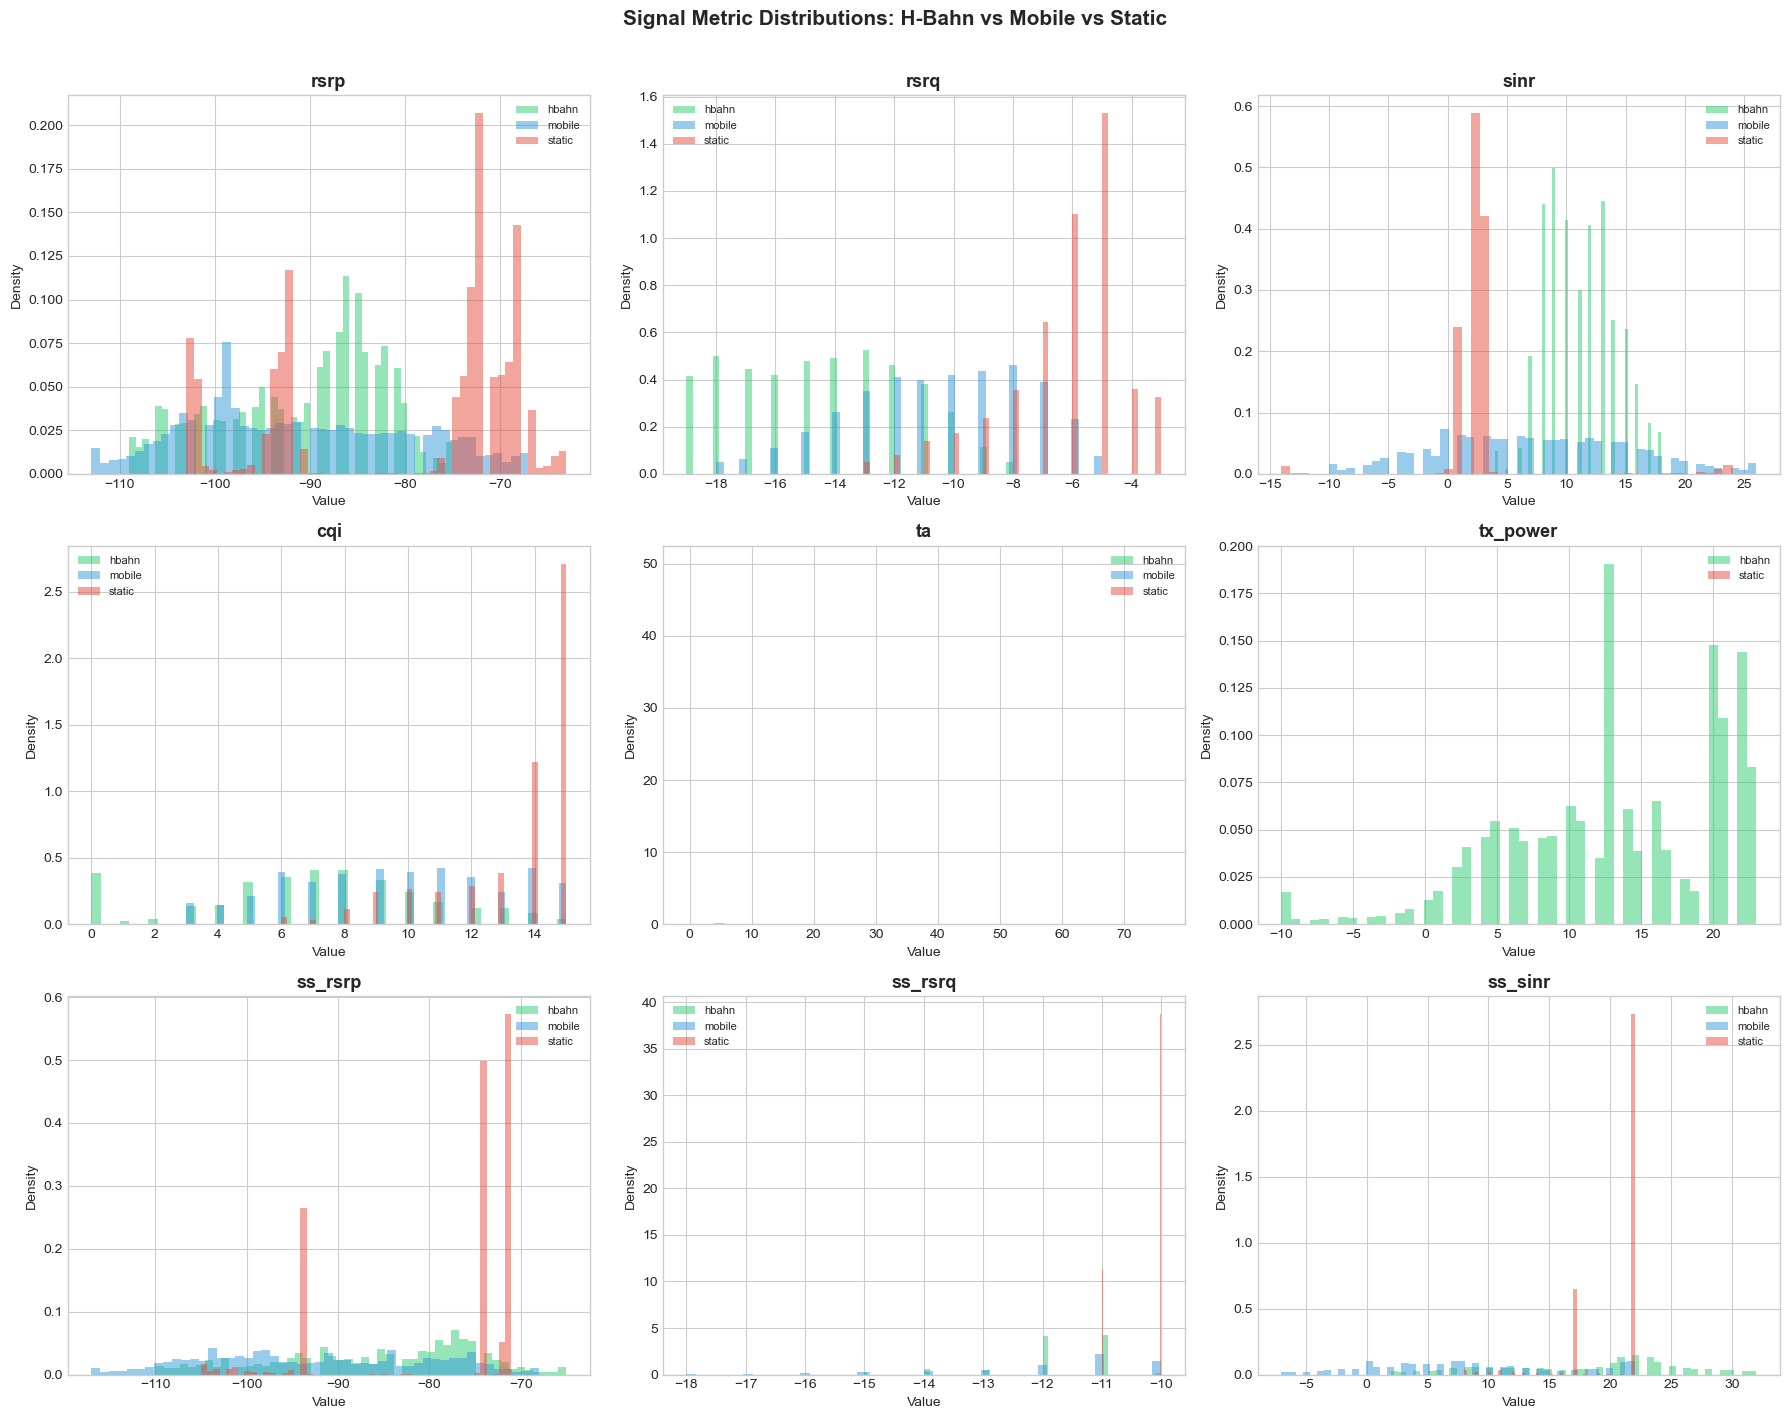

✅ Saved signal_distributions.png

SIGNAL COLUMN STATISTICS BY SCENARIO

── rsrp ──
scenario missing%      min    mean     max    std
   hbahn     9.7% -122.000 -90.720 -55.000  8.560
  mobile     0.0% -140.000 -91.010 -56.000 11.550
  static     0.0% -127.000 -79.590 -57.000 12.540

── rsrq ──
scenario missing%     min    mean    max   std
   hbahn    17.2% -19.000 -14.490 -3.000 2.910
  mobile     0.3% -19.000 -10.500 -3.000 3.020
  static     0.0% -16.000  -6.210 -3.000 2.080

── sinr ──
scenario missing%     min   mean    max   std
   hbahn     9.7% -20.000 11.160 25.000 3.110
  mobile     0.0% -20.000  7.260 30.000 8.100
  static     0.0% -20.000  2.430 30.000 3.960

── cqi ──
scenario missing%   min   mean    max   std
   hbahn     9.7% 0.000  6.930 15.000 3.740
  mobile     0.0% 1.000  9.590 15.000 3.390
  static     0.0% 1.000 13.520 15.000 2.150

── ta ──
scenario missing%   min   mean      max     std
   hbahn     1.5% 0.000 19.500 1280.000 110.690
  mobile     0.0% 0.000  0.0

In [6]:
SIGNAL_COLS = ['rsrp', 'rsrq', 'sinr', 'cqi', 'ta', 'tx_power', 'ss_rsrp', 'ss_rsrq', 'ss_sinr']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(SIGNAL_COLS):
    ax = axes[idx]
    plotted = False
    for scenario in ['hbahn', 'mobile', 'static']:
        df_sc = raw[scenario].get('cell_data', pd.DataFrame())
        if col not in df_sc.columns:
            continue
        vals = df_sc[col].dropna()
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=50, alpha=0.5, color=COLORS[scenario],
                label=scenario, density=True, edgecolor='none')
        plotted = True
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    if plotted:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Not available', ha='center', va='center',
                transform=ax.transAxes, color='gray')

plt.suptitle('Signal Metric Distributions: H-Bahn vs Mobile vs Static',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('signal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved signal_distributions.png')

# Numerical summary
print('\nSIGNAL COLUMN STATISTICS BY SCENARIO')
print('='*70)
for col in SIGNAL_COLS:
    print(f'\n── {col} ──')
    rows = []
    for scenario in ['hbahn', 'mobile', 'static']:
        df_sc = raw[scenario].get('cell_data', pd.DataFrame())
        if col not in df_sc.columns:
            rows.append({'scenario': scenario, 'status': 'NOT IN FILE',
                         'missing%': '-', 'min': '-', 'mean': '-', 'max': '-', 'std': '-'})
        else:
            s = df_sc[col]
            rows.append({'scenario': scenario, 'missing%': f"{s.isnull().mean()*100:.1f}%",
                         'min': round(s.min(),2), 'mean': round(s.mean(),2),
                         'max': round(s.max(),2), 'std': round(s.std(),2)})
    print(pd.DataFrame(rows).to_string(index=False))


---
## 1.6 — QoS Targets

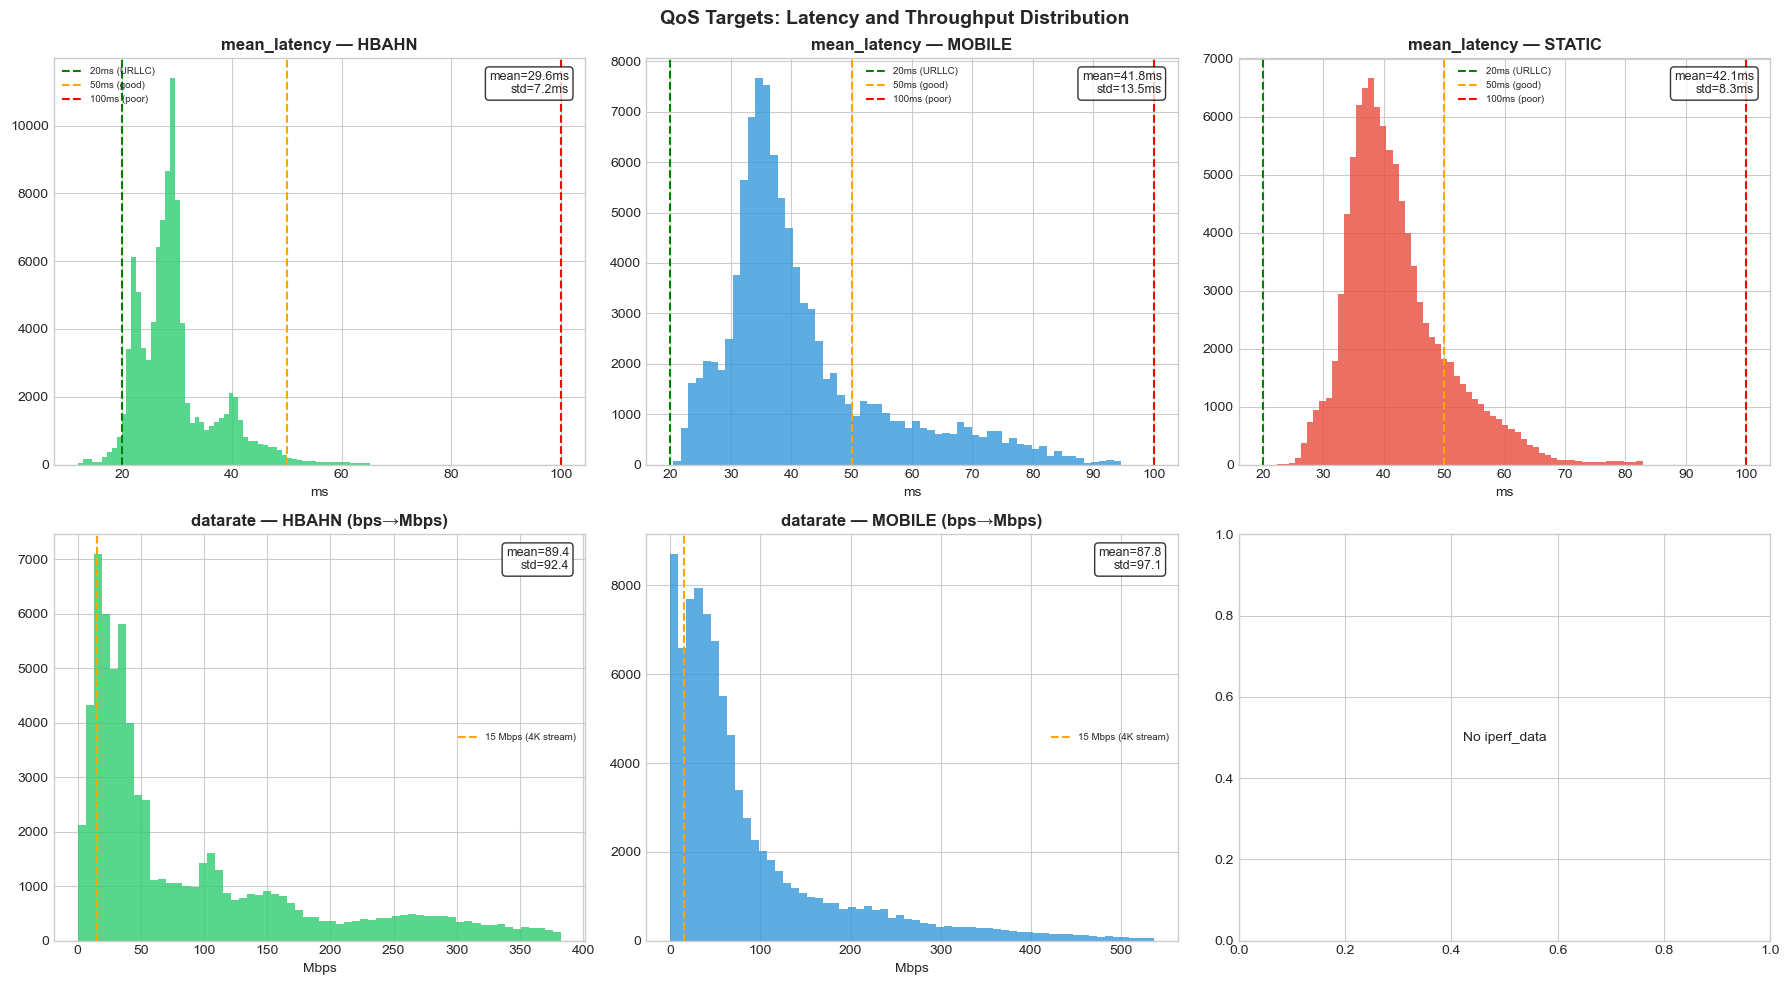

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, scenario in enumerate(['hbahn', 'mobile', 'static']):
    # Row 1: latency
    ax = axes[0, col_idx]
    df_lat = raw[scenario].get('latency_data', pd.DataFrame())
    if 'mean_latency' not in df_lat.columns:
        ax.text(0.5, 0.5, 'No latency_data', ha='center', va='center', transform=ax.transAxes)
    else:
        lat = df_lat['mean_latency'].dropna()
        lat = lat[lat < lat.quantile(0.99)]
        ax.hist(lat, bins=60, color=COLORS[scenario], alpha=0.8, edgecolor='none')
        ax.axvline(20,  color='green',  linestyle='--', lw=1.5, label='20ms (URLLC)')
        ax.axvline(50,  color='orange', linestyle='--', lw=1.5, label='50ms (good)')
        ax.axvline(100, color='red',    linestyle='--', lw=1.5, label='100ms (poor)')
        ax.set_title(f'mean_latency — {scenario.upper()}', fontweight='bold')
        ax.set_xlabel('ms')
        ax.legend(fontsize=7)
        ax.text(0.97, 0.97, f'mean={lat.mean():.1f}ms\nstd={lat.std():.1f}ms',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Row 2: datarate
    ax = axes[1, col_idx]
    df_ip = raw[scenario].get('iperf_data', pd.DataFrame())
    if df_ip is None or 'datarate' not in df_ip.columns:
        ax.text(0.5, 0.5, 'No iperf_data', ha='center', va='center', transform=ax.transAxes)
    else:
        dr = df_ip['datarate'].dropna()
        if dr.median() > 1_000_000:   dr = dr / 1_000_000; unit = 'bps→Mbps'
        elif dr.median() > 1_000:     dr = dr / 1_000;     unit = 'kbps→Mbps'
        else:                                               unit = 'Mbps'
        dr = dr[(dr > 0) & (dr < dr.quantile(0.99))]
        ax.hist(dr, bins=60, color=COLORS[scenario], alpha=0.8, edgecolor='none')
        ax.axvline(15, color='orange', linestyle='--', lw=1.5, label='15 Mbps (4K stream)')
        ax.set_title(f'datarate — {scenario.upper()} ({unit})', fontweight='bold')
        ax.set_xlabel('Mbps'); ax.legend(fontsize=7)
        ax.text(0.97, 0.97, f'mean={dr.mean():.1f}\nstd={dr.std():.1f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('QoS Targets: Latency and Throughput Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qos_targets.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 1.7 — Neighbouring Cell Deep Dive

NEIGHBORING DATA DEEP DIVE

HBAHN:
  Shape: (100000, 20)
  Columns: ['network_neighboring', 'physical_cellid_neighboring', 'tracking_area_code_neighboring', 'earfcn_neighboring', 'rsrp_neighboring', 'rsrq_neighboring', 'rssi_neighboring', 'sinr_neighboring', 'mcc_neighboring', 'mnc_neighboring', 'device', 'latitude', 'longitude', 'altitude', 'location_accuracy', 'velocity', 'velocity_accuracy', 'bearing', 'bearing_accuracy', 'MNO_neighboring']
  ⚠️  No timestamp column found — H-Bahn neighbour merge will be skipped.

MOBILE:
  Shape: (100000, 23)
  Columns: ['network_neighboring', 'physical_cellid_neighboring', 'tracking_area_code_neighboring', 'earfcn_neighboring', 'rsrp_neighboring', 'rsrq_neighboring', 'rssi_neighboring', 'sinr_neighboring', 'mcc_neighboring', 'mnc_neighboring', 'passive_id', 'device', 'latitude', 'longitude', 'altitude', 'location_accuracy', 'velocity', 'velocity_accuracy', 'bearing', 'bearing_accuracy', 'timestamp_day', 'week_of_year', 'day_of_week']
  ⚠️  No time

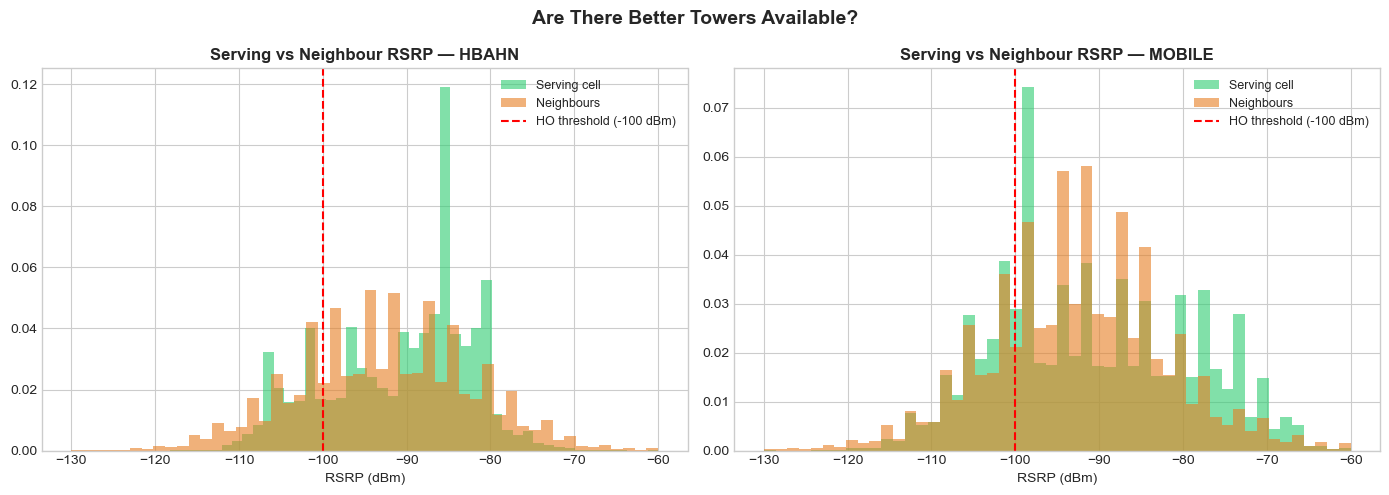

In [8]:
print('NEIGHBORING DATA DEEP DIVE')
print('='*60)

for scenario in ['hbahn', 'mobile']:
    df_n = raw[scenario].get('neighboring_data', pd.DataFrame())
    df_c = raw[scenario].get('cell_data', pd.DataFrame())
    print(f'\n{scenario.upper()}:')
    print(f'  Shape: {df_n.shape}')
    print(f'  Columns: {df_n.columns.tolist()}')
    ts_col = next((c for c in ['timestamp','timestampstart'] if c in df_n.columns), None)
    if ts_col:
        nbr_per_ts = df_n.groupby(ts_col).size()
        print(f'  Neighbours per scan: mean={nbr_per_ts.mean():.1f} '
              f'median={nbr_per_ts.median():.0f} max={nbr_per_ts.max()}')
    else:
        print('  ⚠️  No timestamp column found — H-Bahn neighbour merge will be skipped.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scenario in zip(axes, ['hbahn', 'mobile']):
    df_n = raw[scenario].get('neighboring_data', pd.DataFrame())
    df_c = raw[scenario].get('cell_data', pd.DataFrame())
    if 'rsrp_neighboring' not in df_n.columns or 'rsrp' not in df_c.columns:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{scenario.upper()} — no RSRP data')
        continue
    serv = df_c['rsrp'].dropna().clip(-130, -60)
    nbr  = df_n['rsrp_neighboring'].dropna().clip(-130, -60)
    ax.hist(serv, bins=50, alpha=0.6, color='#2ecc71', label='Serving cell', density=True)
    ax.hist(nbr,  bins=50, alpha=0.6, color='#e67e22', label='Neighbours',   density=True)
    ax.axvline(-100, color='red', linestyle='--', lw=1.5, label='HO threshold (-100 dBm)')
    ax.set_title(f'Serving vs Neighbour RSRP — {scenario.upper()}', fontweight='bold')
    ax.set_xlabel('RSRP (dBm)'); ax.legend(fontsize=9)

plt.suptitle('Are There Better Towers Available?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('serving_vs_neighbor.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 1.8 — Correlation Analysis

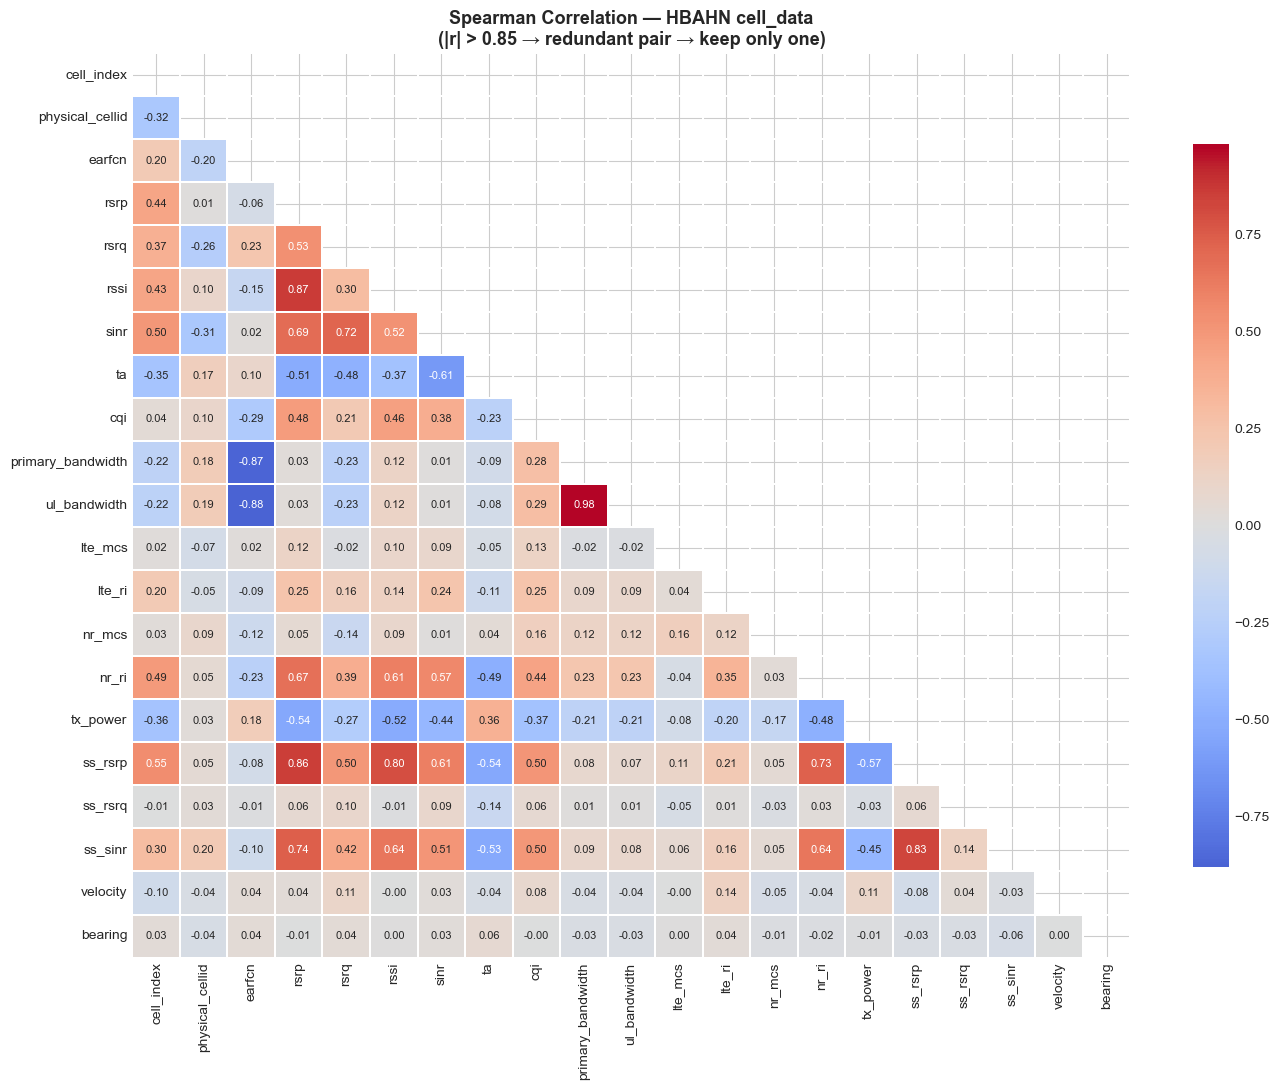


HIGHLY CORRELATED PAIRS in hbahn (|r| > 0.80):
  primary_bandwidth    ↔ ul_bandwidth          r=0.985
  rsrp                 ↔ rssi                  r=0.867
  rsrp                 ↔ ss_rsrp               r=0.857
  ss_rsrp              ↔ ss_sinr               r=0.826
  rssi                 ↔ ss_rsrp               r=0.802
  earfcn               ↔ primary_bandwidth     r=-0.870
  earfcn               ↔ ul_bandwidth          r=-0.881


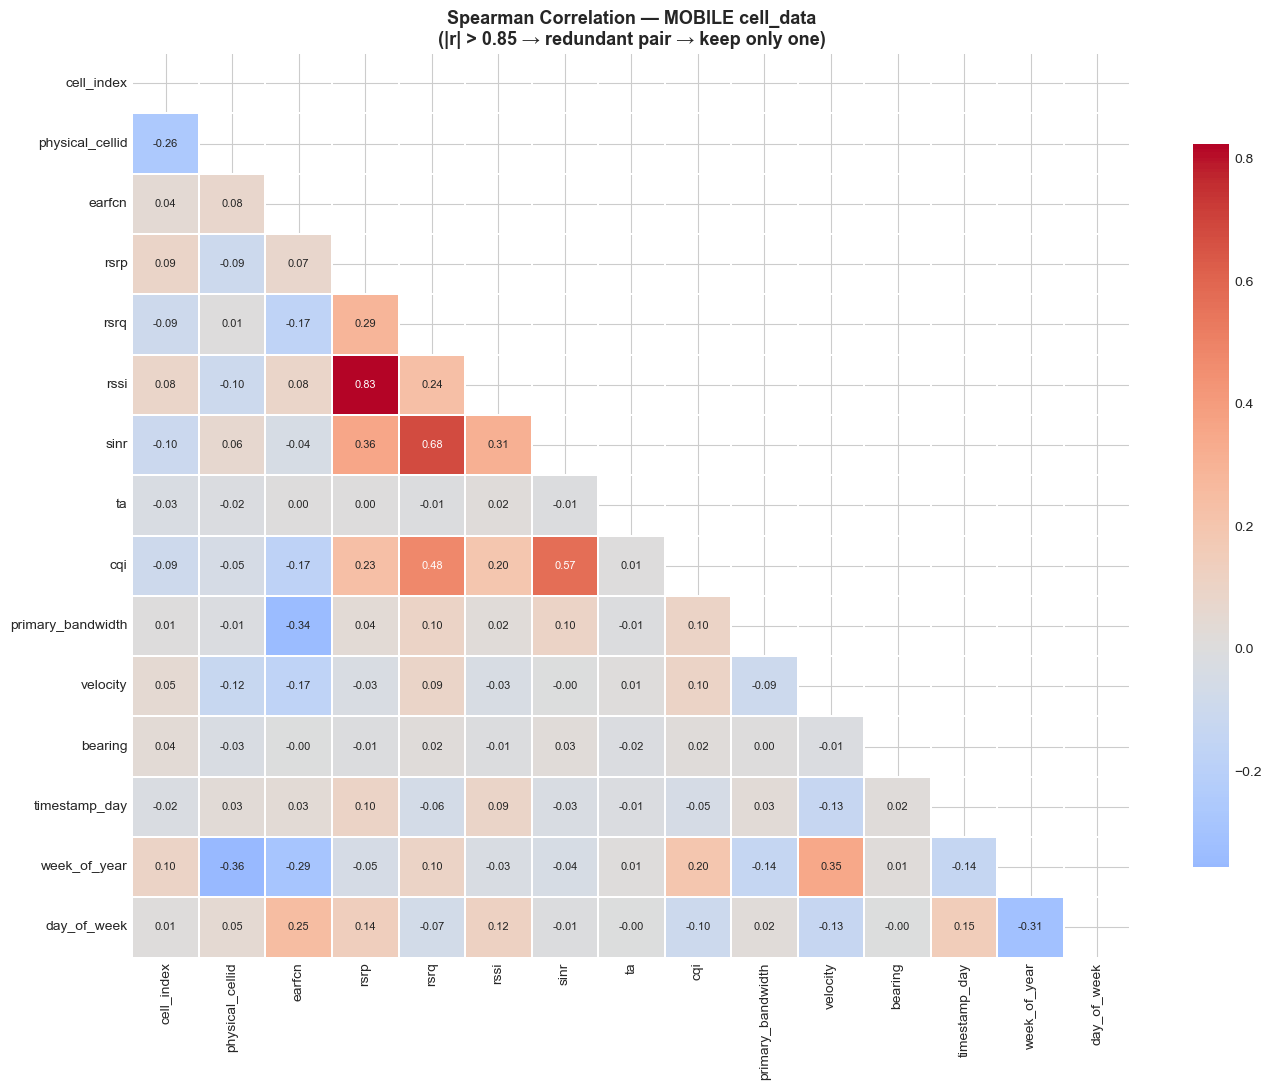


HIGHLY CORRELATED PAIRS in mobile (|r| > 0.80):
  rsrp                 ↔ rssi                  r=0.825


In [9]:
META = ['network','mcc','mnc','MNO','device','cellbandwidths','tracking_area_code',
        'timestamp','timestampstart','timestampend','bearing_accuracy',
        'velocity_accuracy','location_accuracy','latitude','longitude','altitude',
        'passive_id','username','session_id']

for scenario in ['hbahn', 'mobile']:
    df_c = raw[scenario]['cell_data'].copy()
    df_c = df_c.drop(columns=[c for c in META if c in df_c.columns], errors='ignore')
    df_c = df_c.select_dtypes(include='number')
    df_c = df_c.dropna(axis=1, thresh=int(0.5 * len(df_c)))
    corr = df_c.corr(method='spearman')
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
    ax.set_title(f'Spearman Correlation — {scenario.upper()} cell_data\n'
                 f'(|r| > 0.85 → redundant pair → keep only one)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'correlation_{scenario}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nHIGHLY CORRELATED PAIRS in {scenario} (|r| > 0.80):')
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    high  = upper.stack()
    high  = high[high.abs() > 0.80].sort_values(ascending=False)
    for (c1, c2), r in high.items():
        print(f'  {c1:20s} ↔ {c2:20s}  r={r:.3f}')
    if len(high) == 0:
        print('  None above threshold.')


In [10]:
print('SIGNAL vs THROUGHPUT CORRELATION')
print('='*60)
print('Core assumption for DSO4: radio features can predict datarate.')
print('Weak correlations here mean additional features (lag, cell load) are essential.')
print()

for scenario in ['hbahn', 'mobile']:
    df_ip = raw[scenario].get('iperf_data', pd.DataFrame())
    if df_ip is None or 'datarate' not in df_ip.columns:
        print(f'{scenario}: no iperf_data'); continue
    dr = df_ip['datarate'].dropna()
    if dr.median() > 1_000_000:  df_ip['datarate'] = df_ip['datarate'] / 1_000_000
    elif dr.median() > 1_000:    df_ip['datarate'] = df_ip['datarate'] / 1_000
    df_ip = df_ip[df_ip['datarate'] > 0]
    sig_cols_avail = [c for c in ['rsrp','rsrq','sinr','cqi','ta','tx_power',
                                   'ss_rsrp','ss_sinr','velocity','lte_mcs','nr_mcs']
                      if c in df_ip.columns]
    print(f'{scenario.upper()} — Spearman r with datarate:')
    correlations = []
    for col in sig_cols_avail:
        aligned = df_ip[['datarate', col]].dropna()
        if len(aligned) < 50: continue
        r, p = stats.spearmanr(aligned['datarate'], aligned[col])
        strength = '🔴 STRONG' if abs(r) > 0.5 else ('🟡 MODERATE' if abs(r) > 0.3 else '⚪ WEAK')
        correlations.append((col, r, p, strength))
    correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    for col, r, p, strength in correlations:
        print(f'  {col:20s}  r={r:+.3f}  {strength}')
    print()


SIGNAL vs THROUGHPUT CORRELATION
Core assumption for DSO4: radio features can predict datarate.
Weak correlations here mean additional features (lag, cell load) are essential.

HBAHN — Spearman r with datarate:
  tx_power              r=-0.227  ⚪ WEAK
  cqi                   r=+0.220  ⚪ WEAK
  lte_mcs               r=+0.209  ⚪ WEAK
  nr_mcs                r=+0.202  ⚪ WEAK
  ss_rsrp               r=+0.193  ⚪ WEAK
  rsrp                  r=+0.191  ⚪ WEAK
  sinr                  r=+0.181  ⚪ WEAK
  ss_sinr               r=+0.153  ⚪ WEAK
  ta                    r=-0.144  ⚪ WEAK
  rsrq                  r=+0.090  ⚪ WEAK
  velocity              r=-0.039  ⚪ WEAK

MOBILE — Spearman r with datarate:
  rsrp                  r=+0.222  ⚪ WEAK
  rsrq                  r=+0.207  ⚪ WEAK
  ss_rsrp               r=+0.200  ⚪ WEAK
  sinr                  r=+0.168  ⚪ WEAK
  cqi                   r=+0.149  ⚪ WEAK
  ss_sinr               r=+0.096  ⚪ WEAK
  ta                    r=-0.041  ⚪ WEAK
  velocity     

---
## 1.9 — Feature Selection Decision Table

In [11]:
feature_decisions = [
    {'feature': 'rsrp',              'decision': 'KEEP',     'reason': 'Primary signal strength; drops at cell edge = HO trigger.'},
    {'feature': 'rsrq',              'decision': 'KEEP',     'reason': 'Signal quality including interference.'},
    {'feature': 'sinr',              'decision': 'KEEP',     'reason': 'Best single predictor of link quality.'},
    {'feature': 'cqi',               'decision': 'KEEP',     'reason': 'Phone feedback on achievable throughput.'},
    {'feature': 'tx_power',          'decision': 'KEEP',     'reason': 'High = struggling = likely low throughput.'},
    {'feature': 'ta',                'decision': 'KEEP',     'reason': 'Distance proxy; high = cell edge = handover candidate.'},
    {'feature': 'ss_rsrp',           'decision': 'KEEP',     'reason': '5G signal strength variant; ~9% missing, impute.'},
    {'feature': 'ss_sinr',           'decision': 'KEEP',     'reason': '5G SINR; different from 4G sinr.'},
    {'feature': 'lte_mcs',           'decision': 'KEEP',     'reason': 'Modulation scheme; high = good conditions.'},
    {'feature': 'lte_ri',            'decision': 'KEEP',     'reason': 'MIMO rank; more streams = more capacity.'},
    {'feature': 'earfcn',            'decision': 'KEEP',     'reason': 'Frequency band; different bands have different coverage.'},
    {'feature': 'velocity',          'decision': 'KEEP',     'reason': 'Speed drives handover frequency.'},
    {'feature': 'physical_cellid',   'decision': 'HO_ONLY',  'reason': 'Used only to detect handovers; not a model input.'},
    {'feature': 'rssi',              'decision': 'DROP_IF_COLLINEAR', 'reason': 'Drop if corr(rssi,rsrp) > 0.85.'},
    {'feature': 'ss_rsrq',           'decision': 'MAYBE',    'reason': 'Check correlation with rsrq first.'},
    {'feature': 'bearing',           'decision': 'MAYBE',    'reason': 'Direction of travel; check if it improves model.'},
    {'feature': 'mcc',               'decision': 'DROP',     'reason': 'Country code; constant (Germany). Zero variance.'},
    {'feature': 'mnc',               'decision': 'DROP',     'reason': 'Network code; operator artifact, not physics.'},
    {'feature': 'MNO',               'decision': 'DROP',     'reason': 'Operator name; same as mnc.'},
    {'feature': 'network',           'decision': 'DROP',     'reason': '100% missing in H-Bahn.'},
    {'feature': 'device',            'decision': 'DROP',     'reason': 'Phone model; device artifact, not network.'},
    {'feature': 'tracking_area_code','decision': 'DROP',     'reason': 'Coarse region code; near-constant.'},
    {'feature': 'cellbandwidths',    'decision': 'DROP',     'reason': '100% missing in H-Bahn. String format.'},
    {'feature': 'location_accuracy', 'decision': 'DROP',     'reason': 'Sensor metadata, not a network feature.'},
    {'feature': 'velocity_accuracy', 'decision': 'DROP',     'reason': 'Sensor metadata.'},
    {'feature': 'bearing_accuracy',  'decision': 'DROP',     'reason': 'Sensor metadata.'},
]

fd = pd.DataFrame(feature_decisions)
print('FEATURE SELECTION DECISIONS')
print('='*80)
for decision in ['KEEP', 'MAYBE', 'HO_ONLY', 'DROP_IF_COLLINEAR', 'DROP']:
    subset = fd[fd['decision'] == decision]
    if subset.empty: continue
    emoji = {'KEEP':'✅','MAYBE':'🤔','HO_ONLY':'🔁','DROP_IF_COLLINEAR':'🔍','DROP':'❌'}.get(decision,'')
    print(f'\n{emoji} {decision} ({len(subset)} features):')
    for _, row in subset.iterrows():
        print(f'  {row["feature"]:22s}  {row["reason"]}')


FEATURE SELECTION DECISIONS

✅ KEEP (12 features):
  rsrp                    Primary signal strength; drops at cell edge = HO trigger.
  rsrq                    Signal quality including interference.
  sinr                    Best single predictor of link quality.
  cqi                     Phone feedback on achievable throughput.
  tx_power                High = struggling = likely low throughput.
  ta                      Distance proxy; high = cell edge = handover candidate.
  ss_rsrp                 5G signal strength variant; ~9% missing, impute.
  ss_sinr                 5G SINR; different from 4G sinr.
  lte_mcs                 Modulation scheme; high = good conditions.
  lte_ri                  MIMO rank; more streams = more capacity.
  earfcn                  Frequency band; different bands have different coverage.
  velocity                Speed drives handover frequency.

🤔 MAYBE (2 features):
  ss_rsrq                 Check correlation with rsrq first.
  bearing             

---
## 1.10 — Missing Value Analysis

In [12]:
print('MISSING VALUE ANALYSIS — cell_data + iperf_data')
print('='*60)
all_candidate_cols = ['rsrp','rsrq','sinr','rssi','cqi','ta','tx_power',
                      'ss_rsrp','ss_rsrq','ss_sinr','lte_mcs','lte_ri',
                      'primary_bandwidth','ul_bandwidth','earfcn','velocity','physical_cellid']
rows = []
for col in all_candidate_cols:
    row = {'feature': col}
    for scenario in ['hbahn', 'mobile']:
        for fname in ['cell_data', 'iperf_data']:
            df_sc = raw[scenario].get(fname, pd.DataFrame())
            key = f'{scenario}/{fname}'
            if col not in df_sc.columns:
                row[key] = 'NOT IN FILE'
            else:
                row[key] = f'{df_sc[col].isnull().mean()*100:.1f}%'
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

print('\nLOW VARIANCE CHECK')
print('='*60)
for scenario in ['hbahn', 'mobile']:
    df_sc = raw[scenario]['cell_data'].select_dtypes(include='number')
    print(f'{scenario.upper()}:')
    low_var = [(col, df_sc[col].nunique(), df_sc[col].dropna().unique().tolist()[:5])
               for col in df_sc.columns if df_sc[col].nunique() <= 5]
    if low_var:
        for col, n, vals in low_var:
            print(f'  ❌ {col:25s}: only {n} unique values → {vals}')
    else:
        print('  ✅ No near-constant columns found')
    print()


MISSING VALUE ANALYSIS — cell_data + iperf_data
          feature hbahn/cell_data hbahn/iperf_data mobile/cell_data mobile/iperf_data
             rsrp            9.7%             0.5%             0.0%              9.8%
             rsrq           17.2%             7.2%             0.3%              9.9%
             sinr            9.7%             0.5%             0.0%              9.8%
             rssi           34.0%            33.3%             0.0%              0.0%
              cqi            9.7%             0.5%             0.0%              9.8%
               ta            1.5%             1.2%             0.0%              0.0%
         tx_power           18.7%             2.3%      NOT IN FILE       NOT IN FILE
          ss_rsrp           18.6%             2.6%            66.2%             64.1%
          ss_rsrq           18.6%             2.6%            66.2%             64.1%
          ss_sinr           18.7%             2.7%            66.2%             64.1%
      

---
# 🔧 Phase 2 — Data Cleaning & Feature Engineering (v9)

**v9 additions:**
1. Extended lag windows (10, 20 steps) and rolling std (volatility features)
2. Rate-of-change: SINR delta over 5 steps
3. Handover history features: time_since_last_ho, ho_count_60s, serving_cell_age
4. Cell load extended: cell_hist_datarate_std, cell_hist_congestion_rate
5. Neighbour features: num_neighbors_delta, neighbour_diversity
6. Mobile-specific: bearing, acceleration features
7. **DSO2 redesigned** around cell profiles — no timestamp join dependency


---
## 2.1 — Data Alignment and Merging

In [13]:
# Only load the columns we actually need (memory safety)
NEEDED_COLS = {
    'timestamp', 'timestampstart', 'session_start_timestamp', 'timestamp_day',
    'device', 'username', 'session_id', 'passive_id', 'id',
    'physical_cellid', 'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
    'velocity', 'primary_bandwidth', 'earfcn', 'lte_mcs', 'lte_ri',
    'ss_rsrp', 'ss_sinr', 'datarate', 'mean_latency'
}
MAX_ROWS = 100_000

def load_and_merge_scenario(scenario):
    spath = os.path.join(BASE_PATH, scenario, scenario)
    print(f'Loading {scenario} (max {MAX_ROWS:,} rows per file)...')

    cell    = pd.read_csv(f'{spath}/cell_data.csv',    sep=';', nrows=MAX_ROWS,
                          usecols=lambda c: c in NEEDED_COLS, low_memory=False)
    iperf   = pd.read_csv(f'{spath}/iperf_data.csv',   sep=';', nrows=MAX_ROWS,
                          usecols=lambda c: c in NEEDED_COLS, low_memory=False)
    latency = pd.read_csv(f'{spath}/latency_data.csv', sep=';', nrows=MAX_ROWS,
                          usecols=lambda c: c in NEEDED_COLS, low_memory=False)

    for df in [cell, iperf, latency]:
        ts_col = next((c for c in ['timestamp','timestampstart',
                                    'session_start_timestamp','timestamp_day']
                       if c in df.columns), None)
        if ts_col:
            df['ts_num'] = pd.to_numeric(df[ts_col], errors='coerce')
            df.dropna(subset=['ts_num'], inplace=True)
            df.sort_values('ts_num', inplace=True)
        id_col = next((c for c in ['device','username','session_id','passive_id']
                       if c in df.columns), None)
        df['master_id'] = df[id_col].astype(str) if id_col else 'unknown'

    # Normalise datarate to Mbps
    if 'datarate' in iperf.columns:
        if iperf['datarate'].median() > 1_000_000:  iperf['datarate'] /= 1_000_000
        elif iperf['datarate'].median() > 1_000:    iperf['datarate'] /= 1_000

    # Backward merge: no future data leaks into past rows
    master = pd.merge_asof(cell,
                           iperf[['ts_num','master_id','datarate']],
                           on='ts_num', by='master_id',
                           direction='backward', tolerance=2000)
    master = pd.merge_asof(master,
                           latency[['ts_num','master_id','mean_latency']],
                           on='ts_num', by='master_id',
                           direction='backward', tolerance=2000)
    master['scenario'] = scenario
    print(f'  ✅ {scenario}: merged shape = {master.shape}')
    return master

dfs = [load_and_merge_scenario(s) for s in ['hbahn', 'mobile']]
df_master = pd.concat(dfs, ignore_index=True)
print(f'\nMaster dataset shape after merge: {df_master.shape}')
df_master[['ts_num','master_id','rsrp','datarate','mean_latency','scenario']].head(3)


Loading hbahn (max 100,000 rows per file)...
  ✅ hbahn: merged shape = (100000, 21)
Loading mobile (max 100,000 rows per file)...
  ✅ mobile: merged shape = (100000, 19)

Master dataset shape after merge: (200000, 23)


,ts_num,master_id,rsrp,datarate,mean_latency,scenario
0,1683266839.000,armv7l_RM500Q-GL,-94.000,19.530,NaN,hbahn
1,1683266845.000,armv7l_RM500Q-GL,-81.000,19.530,NaN,hbahn
2,1683266851.000,armv7l_RM500Q-GL,-83.000,19.530,NaN,hbahn


---
## 2.2 — Neighbour Aggregation + DSO2 Cell Profiles

**v9 key change:** Instead of relying on timestamp joins (which caused 25% coverage), we build cell-level historical profiles from the neighbour table independently. Every serving cell gets a profile of mean/std RSRP, load patterns, and busy-hour behaviour. At inference time DSO2 looks up the serving cell's neighbours' profiles rather than matching timestamps.

In [14]:
def aggregate_neighbors(scenario):
    spath = os.path.join(BASE_PATH, scenario, scenario)
    try:
        neigh = pd.read_csv(f'{spath}/neighboring_data.csv', sep=';', low_memory=False)
    except FileNotFoundError:
        print(f'⚠️  {scenario}: neighboring_data.csv not found.')
        return (
            pd.DataFrame(columns=['ts_num','num_neighbors','best_neighbor_rsrp','mean_neighbor_rsrp']),
            pd.DataFrame(),
            pd.DataFrame()
        )

    ts_col = next((c for c in ['timestamp','timestampstart','timestamp_day','session_start_timestamp']
                   if c in neigh.columns), None)
    if ts_col is None:
        print(f'⚠️  {scenario.upper()}: no timestamp column in neighboring_data — skipping.')
        return (
            pd.DataFrame(columns=['ts_num','num_neighbors','best_neighbor_rsrp','mean_neighbor_rsrp']),
            pd.DataFrame(),
            pd.DataFrame()
        )

    neigh['ts_num'] = pd.to_numeric(neigh[ts_col], errors='coerce')
    rsrp_col   = 'rsrp_neighboring' if 'rsrp_neighboring' in neigh.columns else 'rsrp'
    cellid_col = 'physical_cellid_neighboring' if 'physical_cellid_neighboring' in neigh.columns else None

    if rsrp_col not in neigh.columns:
        print(f'⚠️  {scenario}: no RSRP column in neighboring_data.')
        return (
            pd.DataFrame(columns=['ts_num','num_neighbors','best_neighbor_rsrp','mean_neighbor_rsrp']),
            pd.DataFrame(),
            pd.DataFrame()
        )

    neigh.dropna(subset=['ts_num', rsrp_col], inplace=True)
    neigh['scenario'] = scenario
    neigh.sort_values('ts_num', inplace=True)

    count_col = cellid_col if cellid_col else rsrp_col
    agg = neigh.groupby('ts_num').agg(
        num_neighbors      = (count_col, 'count'),
        best_neighbor_rsrp = (rsrp_col,  'max'),
        mean_neighbor_rsrp = (rsrp_col,  'mean'),
        std_neighbor_rsrp  = (rsrp_col,  'std'),   # v9: spread = diversity
    ).reset_index()
    agg['std_neighbor_rsrp'] = agg['std_neighbor_rsrp'].fillna(0)
    agg['scenario'] = scenario
    agg.sort_values('ts_num', inplace=True)
    print(f'✅ {scenario}: aggregate shape = {agg.shape}')

    # v9: Build cell-level historical profiles from neighbour table
    # This is the core DSO2 fix: we no longer need timestamp join at inference time.
    # For every cell in the network, compute its historical RSRP distribution from
    # all observations across the entire dataset.
    if cellid_col:
        cell_profiles = (
            neigh.groupby(cellid_col)[rsrp_col]
            .agg(
                cell_profile_mean_rsrp = 'mean',
                cell_profile_std_rsrp  = 'std',
                cell_profile_p10_rsrp  = lambda x: x.quantile(0.10),  # bad percentile
                cell_profile_p90_rsrp  = lambda x: x.quantile(0.90),  # good percentile
                cell_profile_n_obs     = 'count'
            )
            .reset_index()
            .rename(columns={cellid_col: 'nbr_cellid'})
        )
        cell_profiles['cell_profile_std_rsrp'] = cell_profiles['cell_profile_std_rsrp'].fillna(0)
        print(f'✅ {scenario}: cell profiles = {cell_profiles.shape[0]} unique cells')
    else:
        cell_profiles = pd.DataFrame()

    keep_cols = ['ts_num', 'scenario', rsrp_col]
    if cellid_col:
        keep_cols.append(cellid_col)
    for extra in ['rsrq_neighboring', 'sinr_neighboring']:
        if extra in neigh.columns:
            keep_cols.append(extra)
    neigh_raw = neigh[keep_cols].copy()
    neigh_raw.rename(columns={rsrp_col: 'nbr_rsrp'}, inplace=True)
    if cellid_col:
        neigh_raw.rename(columns={cellid_col: 'nbr_cellid'}, inplace=True)
    else:
        neigh_raw['nbr_cellid'] = -1
    print(f'✅ {scenario}: per-cell rows shape = {neigh_raw.shape}')
    return agg, neigh_raw, cell_profiles


neigh_results  = [aggregate_neighbors(s) for s in ['hbahn', 'mobile']]
neigh_aggs     = [r[0] for r in neigh_results]
neigh_raws     = [r[1] for r in neigh_results if len(r[1]) > 0]
cell_profiles_list = [r[2] for r in neigh_results if len(r[2]) > 0]

df_neigh     = pd.concat(neigh_aggs, ignore_index=True)
df_neigh_raw = pd.concat(neigh_raws, ignore_index=True) if neigh_raws else pd.DataFrame()
# v9: Combine cell profiles from both scenarios
df_cell_profiles = pd.concat(cell_profiles_list, ignore_index=True) if cell_profiles_list else pd.DataFrame()
if not df_cell_profiles.empty:
    df_cell_profiles = (
        df_cell_profiles.groupby('nbr_cellid')
        .agg({
            'cell_profile_mean_rsrp': 'mean',
            'cell_profile_std_rsrp':  'mean',
            'cell_profile_p10_rsrp':  'mean',
            'cell_profile_p90_rsrp':  'mean',
            'cell_profile_n_obs':     'sum'
        })
        .reset_index()
    )
    print(f'\n✅ Combined cell profiles: {len(df_cell_profiles)} unique cells across all scenarios')

print(f'\ndf_neigh     shape: {df_neigh.shape}')
print(f'df_neigh_raw shape: {df_neigh_raw.shape}')

# ── Timestamp coverage diagnostic & auto unit-correction ──────────────────────
print('\n── DSO2 Timestamp Coverage Diagnostic ──')
MERGE_TOLERANCE = 2000

if len(df_neigh) > 0 and 'ts_num' in df_neigh.columns:
    med_master = float(df_master['ts_num'].median())
    med_neigh  = float(df_neigh['ts_num'].median())
    print(f'  df_master  ts range: {df_master["ts_num"].min():.0f} – {df_master["ts_num"].max():.0f}  (median {med_master:.0f})')
    print(f'  df_neigh   ts range: {df_neigh["ts_num"].min():.0f} – {df_neigh["ts_num"].max():.0f}  (median {med_neigh:.0f})')
    ratio = med_neigh / max(med_master, 1)
    if 900 < ratio < 1100:
        print('  ✅ 1000× factor → normalising neigh ts from ms to s')
        df_neigh['ts_num']     = df_neigh['ts_num'] / 1000.0
        df_neigh_raw['ts_num'] = df_neigh_raw['ts_num'] / 1000.0
    elif 0.0009 < ratio < 0.0011:
        print('  ✅ 1/1000 factor → normalising neigh ts from s to ms')
        df_neigh['ts_num']     = df_neigh['ts_num'] * 1000.0
        df_neigh_raw['ts_num'] = df_neigh_raw['ts_num'] * 1000.0

    ms = df_master[['ts_num']].sort_values('ts_num')
    ns = df_neigh[['ts_num']].sort_values('ts_num')
    cov_2s  = pd.merge_asof(ms, ns.assign(_m=1), on='ts_num', direction='backward', tolerance=2000)['_m'].notna().mean()
    cov_10s = pd.merge_asof(ms, ns.assign(_m=1), on='ts_num', direction='backward', tolerance=10000)['_m'].notna().mean()
    cov_60s = pd.merge_asof(ms, ns.assign(_m=1), on='ts_num', direction='backward', tolerance=60000)['_m'].notna().mean()
    print(f'  Coverage at  2s tolerance: {cov_2s*100:.1f}%')
    print(f'  Coverage at 10s tolerance: {cov_10s*100:.1f}%')
    print(f'  Coverage at 60s tolerance: {cov_60s*100:.1f}%')
    if cov_60s > cov_10s + 0.05:
        MERGE_TOLERANCE = 60000
    elif cov_10s > cov_2s + 0.05:
        MERGE_TOLERANCE = 10000
    print(f'  → Selected MERGE_TOLERANCE = {MERGE_TOLERANCE} ms ({MERGE_TOLERANCE//1000}s)')

# Merge neighbour aggregates into df_master
df_master = pd.merge_asof(
    df_master.sort_values('ts_num'),
    df_neigh[['ts_num','num_neighbors','best_neighbor_rsrp','mean_neighbor_rsrp','std_neighbor_rsrp']].sort_values('ts_num'),
    on='ts_num', direction='backward', tolerance=MERGE_TOLERANCE
)
if 'scenario_x' in df_master.columns:
    df_master.rename(columns={'scenario_x': 'scenario'}, inplace=True)
if 'scenario_y' in df_master.columns:
    df_master.drop(columns=['scenario_y'], inplace=True)

df_master['num_neighbors']      = df_master['num_neighbors'].fillna(0)
df_master['best_neighbor_rsrp'] = df_master['best_neighbor_rsrp'].fillna(-140)
df_master['mean_neighbor_rsrp'] = df_master['mean_neighbor_rsrp'].fillna(-140)
df_master['std_neighbor_rsrp']  = df_master['std_neighbor_rsrp'].fillna(0)

final_cov = (df_master['num_neighbors'] > 0).mean()
print(f'\nMaster shape after neighbour merge: {df_master.shape}')
print(f'Rows with at least 1 neighbour: {final_cov*100:.1f}%')


⚠️  HBAHN: no timestamp column in neighboring_data — skipping.
✅ mobile: aggregate shape = (1019926, 6)
✅ mobile: cell profiles = 504 unique cells
✅ mobile: per-cell rows shape = (2005673, 6)

✅ Combined cell profiles: 504 unique cells across all scenarios

df_neigh     shape: (1019926, 6)
df_neigh_raw shape: (2005673, 6)

── DSO2 Timestamp Coverage Diagnostic ──
  df_master  ts range: 1 – 1689741392  (median 841676618)
  df_neigh   ts range: 1 – 86398  (median 35950)
  Coverage at  2s tolerance: 50.0%
  Coverage at 10s tolerance: 50.0%
  Coverage at 60s tolerance: 50.0%
  → Selected MERGE_TOLERANCE = 2000 ms (2s)

Master shape after neighbour merge: (200000, 27)
Rows with at least 1 neighbour: 50.0%


---
## 2.3 — Missing Value and Outlier Treatment

In [15]:
# 1. Forward-fill radio metrics within scenario (prevents cross-scenario bleed)
radio_cols = [c for c in ['rsrp','rsrq','sinr','cqi','tx_power','ta'] if c in df_master.columns]
df_master[radio_cols] = df_master.groupby('scenario')[radio_cols].ffill(limit=3)

# 2. Domain-minimum fallback for any remaining NaN
fill_values = {'rsrp': -140, 'rsrq': -30, 'sinr': -10, 'cqi': 0, 'tx_power': 0, 'ta': 0}
df_master.fillna({k: v for k, v in fill_values.items() if k in df_master.columns}, inplace=True)

# 3. Normalise datarate and fill missing with 0
if 'datarate' in df_master.columns:
    if df_master['datarate'].median(skipna=True) > 1_000:
        df_master['datarate'] = df_master['datarate'] / 1_000_000
    df_master['datarate'] = df_master['datarate'].fillna(0)

# 4. Clip velocity (GPS glitch correction)
if 'velocity' in df_master.columns:
    df_master['velocity'] = df_master['velocity'].clip(lower=0, upper=40.0)
    print(f'Velocity clipped: values capped at 40 m/s (144 km/h)')

# 5. Drop rssi if highly collinear with rsrp
if 'rssi' in df_master.columns and 'rsrp' in df_master.columns:
    r = df_master['rsrp'].corr(df_master['rssi'])
    print(f'corr(rsrp, rssi) = {r:.3f}')
    if abs(r) > 0.85:
        df_master.drop(columns=['rssi'], inplace=True)
        print('  → Dropped rssi (collinear with rsrp)')

# 6. Drop metadata columns
metadata_to_drop = ['mcc','mnc','MNO','network','device','passive_id',
                    'username','session_id','tracking_area_code','cell_index',
                    'prev_cell','timestamp','timestamp_day','timestampstart']
dropped = [c for c in metadata_to_drop if c in df_master.columns]
df_master.drop(columns=dropped, inplace=True, errors='ignore')
print(f'Dropped {len(dropped)} metadata columns: {dropped}')

# 7. Drop GPS accuracy columns (sensor noise, not network physics)
acc_cols = [c for c in ['location_accuracy','velocity_accuracy','bearing_accuracy']
            if c in df_master.columns]
df_master.drop(columns=acc_cols, inplace=True, errors='ignore')
print(f'Dropped accuracy columns: {acc_cols}')

print(f'\nMissing values after cleaning:')
print(df_master[radio_cols + ['datarate','velocity']].isnull().sum())
print(f'Master shape: {df_master.shape}')


Velocity clipped: values capped at 40 m/s (144 km/h)
Dropped 4 metadata columns: ['device', 'passive_id', 'timestamp', 'timestamp_day']
Dropped accuracy columns: []

Missing values after cleaning:
rsrp           0
rsrq           0
sinr           0
cqi            0
tx_power       0
ta             0
datarate       0
velocity    6023
dtype: int64
Master shape: (200000, 23)


---
## 2.4 — Temporal Feature Engineering (v9 Extended)

**v9 additions:**
- Longer lags: rsrp_lag_10, rsrp_lag_20 + rolling_std over those windows
- SINR delta over 5 steps (interference pattern, different from path loss)
- Handover history: ho_count_60s, time_since_last_ho, serving_cell_age
- Relative degradation label instead of fixed dBm threshold
- Extended lookahead to 15 steps
- num_neighbors_delta (direction of coverage change)


In [16]:
# Sort chronologically within each scenario
df_master.sort_values(['scenario', 'ts_num'], inplace=True)
df_master.reset_index(drop=True, inplace=True)

# ── Handover detection ──────────────────────────────────────────────────────
if 'physical_cellid' in df_master.columns:
    df_master['prev_cell'] = df_master.groupby('scenario')['physical_cellid'].shift(1)
    df_master['is_ho'] = (
        (df_master['physical_cellid'] != df_master['prev_cell'])
        & df_master['prev_cell'].notna()
    ).astype(int)
    df_master.drop(columns=['prev_cell'], inplace=True)
else:
    df_master['is_ho'] = 0

# ── Handover history features (v9) ─────────────────────────────────────────
# These features tell DSO4 whether the device has been bouncing (ping-pong) 
# and whether a recent handover failed (recovery mode).
grp_ho = df_master.groupby('scenario')

# Approximate time delta per row (median inter-row interval)
ts_diff = df_master.groupby('scenario')['ts_num'].diff().fillna(0)
row_interval_s = float(ts_diff[ts_diff > 0].median()) if (ts_diff > 0).any() else 1.0
# Number of rows in ~60 seconds
rows_60s = max(1, int(60 / max(row_interval_s, 0.5)))

df_master['ho_count_60s'] = (
    df_master.groupby('scenario')['is_ho']
    .transform(lambda x: x.rolling(rows_60s, min_periods=1).sum())
)

# Time since last handover (in rows, then convert to seconds)
def time_since_ho(series):
    result = np.zeros(len(series), dtype=float)
    last_ho = -1
    vals = series.values
    for i, v in enumerate(vals):
        if v == 1:
            last_ho = i
        result[i] = i - last_ho if last_ho >= 0 else i
    return result

df_master['rows_since_last_ho'] = df_master.groupby('scenario')['is_ho'].transform(time_since_ho)
df_master['time_since_last_ho'] = df_master['rows_since_last_ho'] * row_interval_s  # seconds

# Serving cell age (rows on current cell)
def cell_tenure(series):
    result = np.zeros(len(series), dtype=float)
    count = 0
    prev = None
    for i, v in enumerate(series.values):
        if v != prev:
            count = 0
        count += 1
        result[i] = count
        prev = v
    return result

if 'physical_cellid' in df_master.columns:
    df_master['serving_cell_age'] = df_master.groupby('scenario')['physical_cellid'].transform(cell_tenure)
else:
    df_master['serving_cell_age'] = 0.0

# ── Basic trend features (backward-looking — no leakage) ───────────────────
df_master['rsrp_delta_3'] = (
    df_master['rsrp'] - df_master.groupby('scenario')['rsrp'].shift(3)
).fillna(0)
df_master['sinr_delta_3'] = (
    df_master['sinr'] - df_master.groupby('scenario')['sinr'].shift(3)
).fillna(0) if 'sinr' in df_master.columns else 0.0

# v9: SINR delta over 5 steps — identifies interference vs path loss degradation
df_master['sinr_delta_5'] = (
    df_master['sinr'] - df_master.groupby('scenario')['sinr'].shift(5)
).fillna(0) if 'sinr' in df_master.columns else 0.0

# v9: CQI delta over 3 steps
df_master['cqi_delta_3'] = (
    df_master['cqi'] - df_master.groupby('scenario')['cqi'].shift(3)
).fillna(0) if 'cqi' in df_master.columns else 0.0

# ── Extended lag features (v9: 10 and 20 step) ──────────────────────────────
rsrp_median = df_master['rsrp'].median()
for lag in [1, 5, 10, 20]:
    df_master[f'rsrp_lag_{lag}'] = (
        df_master.groupby('scenario')['rsrp'].shift(lag).fillna(rsrp_median)
    )

df_master['rsrp_rolling5'] = (
    df_master.groupby('scenario')['rsrp']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)
# v9: Rolling volatility over wider windows — volatility is a HO predictor
df_master['rsrp_rolling_std_10'] = (
    df_master.groupby('scenario')['rsrp']
    .transform(lambda x: x.rolling(10, min_periods=3).std().fillna(0))
)
df_master['rsrp_rolling_std_20'] = (
    df_master.groupby('scenario')['rsrp']
    .transform(lambda x: x.rolling(20, min_periods=5).std().fillna(0))
)
df_master['rsrp_vs_rolling'] = df_master['rsrp'] - df_master['rsrp_rolling5']

# v9: num_neighbors_delta — direction of coverage change
df_master['num_neighbors_delta'] = (
    df_master['num_neighbors'] - df_master.groupby('scenario')['num_neighbors'].shift(3)
).fillna(0)

# v9: Neighbour diversity — std of neighbour RSRPs (high = diverse towers vs single-tower cluster)
df_master['neighbor_diversity'] = df_master['std_neighbor_rsrp']

# ── Mobile-specific features (v9) ─────────────────────────────────────────
# Bearing rate of change (acceleration proxy for direction change) 
if 'bearing' in df_master.columns:
    df_master['bearing_delta'] = (
        df_master['bearing'] - df_master.groupby('scenario')['bearing'].shift(3)
    ).fillna(0).abs()
else:
    df_master['bearing_delta'] = 0.0

# Velocity delta (acceleration)
if 'velocity' in df_master.columns:
    df_master['velocity_delta'] = (
        df_master['velocity'] - df_master.groupby('scenario')['velocity'].shift(3)
    ).fillna(0)
else:
    df_master['velocity_delta'] = 0.0

# ── DSO1 RELATIVE DEGRADATION LABEL (v9 fix) ───────────────────────────────
# Old: fixed -3 dBm drop threshold — fails for users already at -105 dBm (cell edge)
# New: relative threshold — flag as degrading if RSRP drops > X% of rolling baseline
#      OR crosses below a percentile threshold for this cell's historical distribution.
#
# This fixes the "Poor group near-zero recall" problem: at cell edge there's little
# room to fall 3 dBm more, but 5% below a -105 dBm baseline is still meaningful.

LOOKAHEAD = 15  # v9: extended from 5 to 15 steps for more reaction runway

df_master['rsrp_future_15'] = df_master.groupby('scenario')['rsrp'].shift(-LOOKAHEAD)
df_master['rsrp_slope_15']  = df_master['rsrp_future_15'] - df_master['rsrp']

# Relative degradation: drop > 4% of absolute rolling mean (in dBm scale)
# Using absolute rolling mean as baseline (RSRP is always negative, so we use mean)
rolling_baseline = df_master.groupby('scenario')['rsrp'].transform(
    lambda x: x.rolling(10, min_periods=3).mean().fillna(x)
)
# pct_drop: how much did RSRP fall as fraction of |baseline| 
# positive pct_drop = got worse (RSRP fell further negative)
df_master['rsrp_pct_drop'] = (df_master['rsrp'] - df_master['rsrp_future_15']) / (rolling_baseline.abs() + 1e-3)

# Flag as degrading if:
#   A) Drops >4% of rolling baseline (relative), OR
#   B) Absolute slope < -5 dBm (hard fail)
RELATIVE_THRESH  = 0.04   # 4% relative drop
ABSOLUTE_THRESH  = -5.0   # dBm
df_master['target_is_degrading'] = (
    (df_master['rsrp_pct_drop'] > RELATIVE_THRESH) |
    (df_master['rsrp_slope_15'] < ABSOLUTE_THRESH)
).astype(int)

# Keep old alias for compatibility
df_master['rsrp_future_5'] = df_master.groupby('scenario')['rsrp'].shift(-5)
df_master['rsrp_slope_5']  = df_master['rsrp_future_5'] - df_master['rsrp']

# ── DSO4 target — leakage-free ─────────────────────────────────────────────
df_master['target_future_datarate'] = df_master.groupby('scenario')['datarate'].shift(-3)
cond_real_ho    = df_master.groupby('scenario')['is_ho'].shift(-1).fillna(0).astype(bool)
cond_qos_collapse = df_master['target_future_datarate'] < 3.0
df_master['target_ho_flag'] = (cond_real_ho | cond_qos_collapse).astype(int)

df_master['neighbor_gap'] = df_master['best_neighbor_rsrp'] - df_master['rsrp']

DSO4_TARGET = 'target_ho_flag'

df_master.dropna(subset=['rsrp_future_5', 'target_future_datarate'], inplace=True)
df_master.reset_index(drop=True, inplace=True)

print(f'Shape after temporal engineering: {df_master.shape}')
print(f'Lookahead: {LOOKAHEAD} steps (v9: extended from 5)')
print(f'Row interval: ~{row_interval_s:.2f}s  |  rows_60s={rows_60s}')
print('\nNew v9 features:')
for f in ['rsrp_lag_10','rsrp_lag_20','rsrp_rolling_std_10','rsrp_rolling_std_20',
          'sinr_delta_5','cqi_delta_3','ho_count_60s','time_since_last_ho',
          'serving_cell_age','num_neighbors_delta','neighbor_diversity',
          'bearing_delta','velocity_delta']:
    if f in df_master.columns:
        print(f'  {f}: mean={df_master[f].mean():.3f}  std={df_master[f].std():.3f}')
print('\nDSO1 target (relative degradation v9):')
print(df_master['target_is_degrading'].value_counts(normalize=True).rename({0:'Stable',1:'Degrading'}).round(3))
print('\nDSO4 target:')
print(df_master['target_ho_flag'].value_counts(normalize=True).rename({0:'Stay',1:'Handover'}).round(3))


Shape after temporal engineering: (199990, 53)
Lookahead: 15 steps (v9: extended from 5)
Row interval: ~2.00s  |  rows_60s=30

New v9 features:
  rsrp_lag_10: mean=-92.879  std=13.912
  rsrp_lag_20: mean=-92.877  std=13.908
  rsrp_rolling_std_10: mean=6.926  std=5.278
  rsrp_rolling_std_20: mean=7.631  std=5.162
  sinr_delta_5: mean=-0.001  std=7.927
  cqi_delta_3: mean=-0.000  std=4.138
  ho_count_60s: mean=15.200  std=12.565
  time_since_last_ho: mean=42.677  std=118.122
  serving_cell_age: mean=20.870  std=58.614
  num_neighbors_delta: mean=0.000  std=1.165
  neighbor_diversity: mean=2.426  std=4.537
  bearing_delta: mean=0.000  std=0.000
  velocity_delta: mean=0.001  std=4.220

DSO1 target (relative degradation v9):
target_is_degrading
Stable      0.700
Degrading   0.300
Name: proportion, dtype: float64

DSO4 target:
target_ho_flag
Handover   0.582
Stay       0.418
Name: proportion, dtype: float64


---
## 2.5 — Cell Load Profiling (v9 Extended)

**v9 additions:** cell_hist_datarate_std (variance = reliability) and cell_hist_congestion_rate (fraction of timestamps where datarate < 5 Mbps).

In [17]:
try:
    df_static_cell = raw['static']['cell_data'].copy()
    has_static_iperf = 'iperf_data' in raw['static']
    if has_static_iperf:
        df_static_iperf = raw['static']['iperf_data'].copy()
    print('Static scenario loaded from raw dict.')
except (NameError, KeyError):
    spath = os.path.join(BASE_PATH, 'static', 'static')
    df_static_cell = pd.read_csv(f'{spath}/cell_data.csv', sep=';', low_memory=False)
    has_static_iperf = os.path.exists(f'{spath}/iperf_data.csv')
    if has_static_iperf:
        df_static_iperf = pd.read_csv(f'{spath}/iperf_data.csv', sep=';', low_memory=False)
    print('Static scenario loaded fresh from disk.')

ts_med = df_master['ts_num'].median()
ts_unit = 'ms' if ts_med > 1e12 else 's'
df_master['datetime']    = pd.to_datetime(df_master['ts_num'], unit=ts_unit, utc=True)
df_master['hour_of_day'] = df_master['datetime'].dt.hour
df_master['day_of_week'] = df_master['datetime'].dt.dayofweek
df_master['time_bin']    = df_master['datetime'].dt.floor('15min')
print(f'Temporal features added (ts_unit={ts_unit})')

cell_load_profile = pd.DataFrame()

if has_static_iperf and 'physical_cellid' in df_static_cell.columns:
    for df_s in [df_static_cell, df_static_iperf]:
        ts_col = 'timestamp' if 'timestamp' in df_s.columns else 'timestampstart'
        df_s['ts_num'] = pd.to_numeric(df_s[ts_col], errors='coerce')
        df_s.dropna(subset=['ts_num'], inplace=True)
        df_s.sort_values('ts_num', inplace=True)
        ts_med_s = df_s['ts_num'].median()
        unit_s = 'ms' if ts_med_s > 1e12 else 's'
        df_s['datetime']    = pd.to_datetime(df_s['ts_num'], unit=unit_s, utc=True)
        df_s['hour_of_day'] = df_s['datetime'].dt.hour

    df_static = pd.merge_asof(df_static_cell, df_static_iperf[['ts_num','datarate']],
                               on='ts_num', direction='backward', tolerance=2000)
    if df_static['datarate'].median(skipna=True) > 1_000:
        df_static['datarate'] = df_static['datarate'] / 1_000_000
    df_static['datarate'] = df_static['datarate'].fillna(0)

    # v9: extended cell load profile with std and congestion rate
    cell_load_profile = (
        df_static.groupby(['physical_cellid','hour_of_day'])
        .agg(
            cell_hist_datarate_mean       = ('datarate', 'mean'),
            cell_hist_datarate_std        = ('datarate', 'std'),      # v9: variance
            cell_hist_rsrp_mean           = ('rsrp',     'mean'),
            cell_hist_congestion_rate     = ('datarate', lambda x: (x < 5).mean())  # v9: congestion
        )
        .reset_index()
    )
    cell_load_profile['cell_hist_datarate_std'] = cell_load_profile['cell_hist_datarate_std'].fillna(0)
    print(f'Cell load profile built from static data: {cell_load_profile.shape}')

elif 'physical_cellid' in df_master.columns:
    cell_load_profile = (
        df_master.groupby(['physical_cellid','hour_of_day'])
        .agg(
            cell_hist_datarate_mean   = ('datarate', 'mean'),
            cell_hist_datarate_std    = ('datarate', 'std'),
            cell_hist_rsrp_mean       = ('rsrp',     'mean'),
            cell_hist_congestion_rate = ('datarate', lambda x: (x < 5).mean())
        )
        .reset_index()
    )
    cell_load_profile['cell_hist_datarate_std'] = cell_load_profile['cell_hist_datarate_std'].fillna(0)
    print(f'Cell load profile built from dynamic data (fallback): {cell_load_profile.shape}')

if not cell_load_profile.empty and 'physical_cellid' in df_master.columns:
    df_master = df_master.merge(cell_load_profile, on=['physical_cellid','hour_of_day'], how='left')
    df_master['cell_hist_datarate_mean']   = df_master['cell_hist_datarate_mean'].fillna(df_master['datarate'].median())
    df_master['cell_hist_datarate_std']    = df_master['cell_hist_datarate_std'].fillna(0)
    df_master['cell_hist_rsrp_mean']       = df_master['cell_hist_rsrp_mean'].fillna(df_master['rsrp'].median())
    df_master['cell_hist_congestion_rate'] = df_master['cell_hist_congestion_rate'].fillna(0.5)
    print('Cell load features merged into master dataset.')
else:
    df_master['cell_hist_datarate_mean']   = df_master['datarate'].median()
    df_master['cell_hist_datarate_std']    = 0.0
    df_master['cell_hist_rsrp_mean']       = df_master['rsrp'].median() if 'rsrp' in df_master.columns else 0
    df_master['cell_hist_congestion_rate'] = 0.5
    print('Placeholder cell load features added.')

if 'physical_cellid' in df_master.columns:
    q25 = df_master.groupby('physical_cellid')['cell_hist_datarate_mean'].transform(lambda x: x.quantile(0.25))
    df_master['cell_load_drop_flag'] = (df_master['cell_hist_datarate_mean'] <= q25).astype(int)
else:
    df_master['cell_load_drop_flag'] = 0

print(f'Master shape after cell load enrichment: {df_master.shape}')
print(f'  cell_hist_datarate_std mean  = {df_master["cell_hist_datarate_std"].mean():.3f}')
print(f'  cell_hist_congestion_rate mean = {df_master["cell_hist_congestion_rate"].mean():.3f}')


Static scenario loaded from raw dict.
Temporal features added (ts_unit=s)
Cell load profile built from dynamic data (fallback): (2315, 6)
Cell load features merged into master dataset.
Master shape after cell load enrichment: (199990, 62)
  cell_hist_datarate_std mean  = 74.110
  cell_hist_congestion_rate mean = 0.235


---
## 2.6 — Latency Imputation

In [18]:
df_master.sort_values(['scenario','master_id','ts_num'], inplace=True)

# Flag rows with no real measurement before we impute
df_master['latency_is_imputed'] = df_master['mean_latency'].isna().astype(int)
print(f'Rows flagged as latency-imputed: {df_master["latency_is_imputed"].sum():,} '
      f'({df_master["latency_is_imputed"].mean()*100:.1f}%)')

# Layer 1: forward-fill within session (limit=5 rows)
df_master['mean_latency'] = (
    df_master.groupby(['scenario','master_id'])['mean_latency'].ffill(limit=5)
)

# Layer 2: per-tower median
tower_avg = df_master.groupby('physical_cellid')['mean_latency'].transform('median')
df_master['mean_latency'] = df_master['mean_latency'].fillna(tower_avg)

# Layer 3: global fallback
global_ping = df_master['mean_latency'].median()
df_master['mean_latency'] = df_master['mean_latency'].fillna(global_ping)
print(f'Global latency fallback used: {global_ping:.2f} ms')
print(f'Remaining missing: {df_master["mean_latency"].isna().sum()}')


Rows flagged as latency-imputed: 165,166 (82.6%)
Global latency fallback used: 42.57 ms
Remaining missing: 0


---
## 2.7 — Feature Vectors (v9)

In [19]:
# ── Placeholder chain features ──────────────────────────────────────────────
for col, val in [('dso3_cluster', -1), ('dso1_risk_score', 0.0),
                 ('dso2_target_rsrp', -140.0), ('dso2_num_candidates', 0.0)]:
    if col not in df_master.columns:
        df_master[col] = val

# ── Ratio features for DSO4 ─────────────────────────────────────────────────
eps = 1e-3
df_master['datarate_vs_hist_ratio'] = (
    df_master['datarate'] / (df_master['cell_hist_datarate_mean'] + eps)
).clip(0, 3)
df_master['rsrp_vs_hist_delta'] = df_master['rsrp'] - df_master['cell_hist_rsrp_mean']

# ── DSO1 features (v9 extended) ──────────────────────────────────────────────
DSO1_FEATURES = [f for f in [
    # RF snapshot
    'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
    # Trend: short and extended
    'rsrp_delta_3', 'sinr_delta_3', 'sinr_delta_5', 'cqi_delta_3',
    # Lag context: short, medium, long
    'rsrp_lag_1', 'rsrp_lag_5', 'rsrp_lag_10', 'rsrp_lag_20',
    # Volatility
    'rsrp_rolling5', 'rsrp_vs_rolling',
    'rsrp_rolling_std_10', 'rsrp_rolling_std_20',
    # Mobility
    'velocity', 'velocity_delta', 'bearing_delta',
    # Neighbour
    'num_neighbors', 'num_neighbors_delta', 'neighbor_diversity',
    # Handover history (v9)
    'ho_count_60s', 'time_since_last_ho', 'serving_cell_age',
    # Temporal
    'hour_of_day', 'day_of_week',
    # Cell load (v9 extended)
    'cell_hist_datarate_mean', 'cell_hist_datarate_std',
    'cell_hist_congestion_rate', 'cell_load_drop_flag',
    'latency_is_imputed',
    # Chain
    'dso3_cluster',
] if f in df_master.columns]
DSO1_TARGET           = 'rsrp_future_5'
DSO1_TARGET_COMPANION = 'target_is_degrading'

# ── DSO2 features ─────────────────────────────────────────────────────────────
DSO2_SERVING_FEATURES = [f for f in [
    'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
    'rsrp_delta_3', 'velocity',
    'num_neighbors', 'mean_neighbor_rsrp',
    'hour_of_day', 'day_of_week',
    'cell_load_drop_flag',
] if f in df_master.columns]
DSO2_FEATURES = DSO2_SERVING_FEATURES
DSO2_TARGET   = 'nbr_rsrp'

# ── DSO3 features ─────────────────────────────────────────────────────────────
DSO3_FEATURES = [f for f in [
    'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
    'rsrp_delta_3', 'sinr_delta_3', 'velocity', 'num_neighbors',
] if f in df_master.columns]

# ── DSO4 features (v9 extended) ──────────────────────────────────────────────
DSO4_FEATURES = [f for f in [
    # RF snapshot + trend
    'rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta',
    'rsrp_delta_3', 'sinr_delta_3', 'sinr_delta_5', 'cqi_delta_3',
    'rsrp_lag_1', 'rsrp_vs_rolling',
    'rsrp_rolling_std_10',
    # Mobility
    'velocity', 'velocity_delta', 'bearing_delta',
    # Neighbour
    'num_neighbors', 'num_neighbors_delta', 'neighbor_diversity',
    # QoS
    'datarate',
    # Temporal
    'hour_of_day', 'day_of_week',
    # Cell load (v9 extended)
    'cell_hist_datarate_mean', 'cell_hist_datarate_std',
    'cell_hist_congestion_rate', 'cell_load_drop_flag',
    'latency_is_imputed',
    # Ratio features
    'datarate_vs_hist_ratio', 'rsrp_vs_hist_delta',
    # Handover history (v9)
    'ho_count_60s', 'time_since_last_ho', 'serving_cell_age',
    # Chain DSO outputs
    'dso1_risk_score', 'dso2_target_rsrp', 'dso2_num_candidates', 'dso3_cluster',
] if f in df_master.columns]
DSO4_TARGET = 'target_ho_flag'

print('DSO Feature Matrix')
print('='*56)
for name, feats, tgt in [
    ('DSO1', DSO1_FEATURES,  DSO1_TARGET_COMPANION),
    ('DSO2', DSO2_FEATURES,  DSO2_TARGET),
    ('DSO3', DSO3_FEATURES,  '(unsupervised)'),
    ('DSO4', DSO4_FEATURES,  DSO4_TARGET),
]:
    avail   = [f for f in feats if f in df_master.columns]
    missing = [f for f in feats if f not in df_master.columns]
    print(f'\n{name}: {len(avail)} features ready — target={tgt}')
    if missing:
        print(f'  ⚠️  Not yet in df_master: {missing}')


DSO Feature Matrix

DSO1: 35 features ready — target=target_is_degrading

DSO2: 13 features ready — target=nbr_rsrp

DSO3: 10 features ready — target=(unsupervised)

DSO4: 36 features ready — target=target_ho_flag


---
## 2.8 — Save Engineered Dataset

In [20]:
df_master.to_parquet('./DATASET/df_master_engineered.parquet', index=False)
if len(df_neigh_raw) > 0:
    df_neigh_raw.to_parquet('./DATASET/df_neigh_raw.parquet', index=False)
if not df_cell_profiles.empty:
    df_cell_profiles.to_parquet('./DATASET/df_cell_profiles.parquet', index=False)

blueprints = {
    'DSO1_FEATURES': DSO1_FEATURES, 'DSO1_TARGET': DSO1_TARGET,
    'DSO1_TARGET_COMPANION': DSO1_TARGET_COMPANION,
    'DSO2_FEATURES': DSO2_FEATURES, 'DSO2_SERVING_FEATURES': DSO2_SERVING_FEATURES,
    'DSO2_TARGET': DSO2_TARGET,
    'DSO3_FEATURES': DSO3_FEATURES,
    'DSO4_FEATURES': DSO4_FEATURES, 'DSO4_TARGET': DSO4_TARGET,
}
with open('./DATASET/feature_blueprints.json', 'w') as f:
    json.dump(blueprints, f)

print('✅ df_master saved to df_master_engineered.parquet')
print(f'✅ df_neigh_raw saved ({len(df_neigh_raw):,} per-cell rows for DSO2 training)')
if not df_cell_profiles.empty:
    print(f'✅ df_cell_profiles saved ({len(df_cell_profiles):,} unique cells)')
print('✅ Feature blueprints saved')
print(f'\nFinal dataset: {df_master.shape[0]:,} rows × {df_master.shape[1]} columns')


✅ df_master saved to df_master_engineered.parquet
✅ df_neigh_raw saved (2,005,673 per-cell rows for DSO2 training)
✅ df_cell_profiles saved (504 unique cells)
✅ Feature blueprints saved

Final dataset: 199,990 rows × 69 columns


---
# 🧠 Phase 3 — DSO Modelling Chain (v9)

**Training order:** DSO3 → DSO1 → DSO2 → DSO4  
**v9 key changes:** k=4 clusters; logistic regression inference classifier for DSO3;  
relative degradation label for DSO1; two-stage gating for DSO4; calibrated probabilities.


In [21]:
from collections import Counter
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, matthews_corrcoef, cohen_kappa_score,
    brier_score_loss, mean_absolute_error, mean_squared_error,
    r2_score, precision_recall_curve, roc_curve, max_error,
    davies_bouldin_score, calinski_harabasz_score, silhouette_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

df_master    = pd.read_parquet('./DATASET/df_master_engineered.parquet')
df_neigh_raw = pd.read_parquet('./DATASET/df_neigh_raw.parquet') if     os.path.exists('./DATASET/df_neigh_raw.parquet') else pd.DataFrame()
df_cell_profiles = pd.read_parquet('./DATASET/df_cell_profiles.parquet') if     os.path.exists('./DATASET/df_cell_profiles.parquet') else pd.DataFrame()

with open('./DATASET/feature_blueprints.json', 'r') as f:
    blueprints = json.load(f)

DSO1_FEATURES         = blueprints['DSO1_FEATURES']
DSO1_TARGET           = blueprints['DSO1_TARGET']
DSO1_TARGET_COMPANION = blueprints['DSO1_TARGET_COMPANION']
DSO2_FEATURES         = blueprints['DSO2_FEATURES']
DSO2_SERVING_FEATURES = blueprints.get('DSO2_SERVING_FEATURES', DSO2_FEATURES)
DSO2_TARGET           = blueprints['DSO2_TARGET']
DSO3_FEATURES         = blueprints['DSO3_FEATURES']
DSO4_FEATURES         = blueprints['DSO4_FEATURES']
DSO4_TARGET           = blueprints['DSO4_TARGET']

# Safety guards
DSO4_FEATURES = [f for f in DSO4_FEATURES if f != 'is_ho']

df_master.sort_values(['scenario', 'ts_num'], inplace=True)
df_master.reset_index(drop=True, inplace=True)
cond_real_ho      = df_master.groupby('scenario')['is_ho'].shift(-1).fillna(0).astype(bool)
cond_qos_collapse = df_master['target_future_datarate'] < 3.0
df_master['target_ho_flag']       = (cond_real_ho | cond_qos_collapse).astype(int)
df_master['target_is_degrading']  = df_master['target_is_degrading'].astype(int)

if 'MERGE_TOLERANCE' not in dir():
    MERGE_TOLERANCE = 10000

print('✅ Dataset and blueprints loaded')
print(f'   df_master    : {df_master.shape[0]:,} rows × {df_master.shape[1]} columns')
print(f'   df_neigh_raw : {len(df_neigh_raw):,} per-cell rows')
if not df_cell_profiles.empty:
    print(f'   df_cell_profiles: {len(df_cell_profiles):,} unique cells')
print(f'   Scenarios: {df_master["scenario"].value_counts().to_dict()}')
print('\nDSO4 target distribution:')
print(df_master['target_ho_flag'].value_counts(normalize=True).rename({0:'Stay',1:'Handover'}).round(3))


✅ Dataset and blueprints loaded
   df_master    : 199,990 rows × 69 columns
   df_neigh_raw : 2,005,673 per-cell rows
   df_cell_profiles: 504 unique cells
   Scenarios: {'hbahn': 99995, 'mobile': 99995}

DSO4 target distribution:
target_ho_flag
Handover   0.582
Stay       0.418
Name: proportion, dtype: float64


---
## 3.1 — DSO3: User State Profiling (v9: k=4 + Inference Classifier)

**v9 changes:**
1. **k=4** forced (recommendation: clusters 0 and 4 in v8 had ~24% HO rate and were redundant)
2. After clustering, a **logistic regression classifier** is trained to predict cluster from real-time features — at inference time we run the fast classifier, not KMeans on each row


── DSO3: User State Profiling (v9 k=4) ──
Features (10): ['rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta', 'rsrp_delta_3', 'sinr_delta_3', 'velocity', 'num_neighbors']

  k    inertia    silhouette   davies-bouldin   calinski-harabasz
  -----------------------------------------------------------------
  k=2   1,620,580      0.2451          1.7944            38198.7
  k=3   1,357,703      0.2338          1.4554            41575.2
  k=4   1,137,394      0.2534          1.3427            45608.9 ← v9 selected
  k=5     955,600      0.2649          1.1261            49939.1
  k=6     885,686      0.1998          1.3677            46167.2
  k=7     829,709      0.1822          1.4178            43249.0
  k=8     747,137      0.2115          1.3264            44229.6


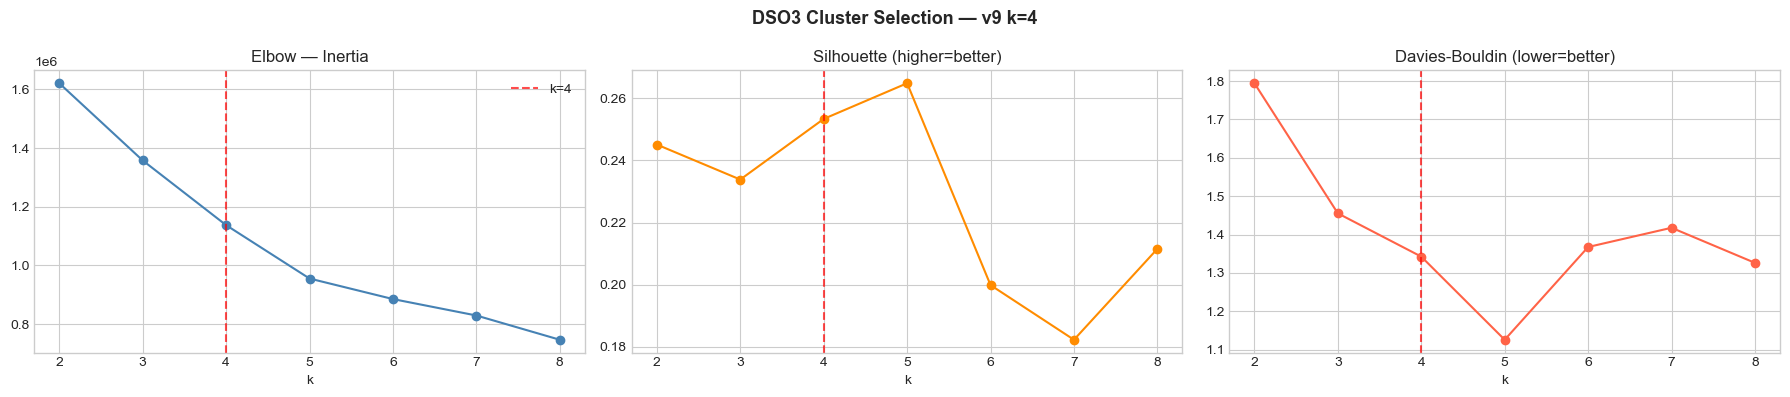

In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print('── DSO3: User State Profiling (v9 k=4) ──')
print(f'Features ({len(DSO3_FEATURES)}): {DSO3_FEATURES}')

df_dso3   = df_master.dropna(subset=DSO3_FEATURES).copy()
X_dso3    = df_dso3[DSO3_FEATURES]
scaler_km = StandardScaler()
X_scaled  = scaler_km.fit_transform(X_dso3)

_sil_sample = min(10_000, len(X_scaled))

# v9: Evaluate k=2..8 but force k=4 based on recommendation
k_range    = range(2, 9)
inertias, sil_scores, db_scores, ch_scores = [], [], [], []

print('\n  k    inertia    silhouette   davies-bouldin   calinski-harabasz')
print('  ' + '-'*65)
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels, sample_size=_sil_sample, random_state=42)
    db     = davies_bouldin_score(X_scaled, labels)
    ch     = calinski_harabasz_score(X_scaled, labels)
    inertias.append(km.inertia_)
    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)
    marker = ' ← v9 selected' if k == 4 else ''
    print(f'  k={k}  {km.inertia_:>10,.0f}  {sil:>10.4f}   {db:>13.4f}   {ch:>16.1f}{marker}')

K_OPTIMAL = 4  # v9: forced — merges redundant clusters 0 and 4 from v8

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].axvline(K_OPTIMAL, color='red', ls='--', alpha=0.7, label=f'k={K_OPTIMAL}')
axes[0].set_title('Elbow — Inertia'); axes[0].set_xlabel('k'); axes[0].legend()
axes[1].plot(list(k_range), sil_scores, 'o-', color='darkorange')
axes[1].axvline(K_OPTIMAL, color='red', ls='--', alpha=0.7)
axes[1].set_title('Silhouette (higher=better)'); axes[1].set_xlabel('k')
axes[2].plot(list(k_range), db_scores, 'o-', color='tomato')
axes[2].axvline(K_OPTIMAL, color='red', ls='--', alpha=0.7)
axes[2].set_title('Davies-Bouldin (lower=better)'); axes[2].set_xlabel('k')
plt.suptitle(f'DSO3 Cluster Selection — v9 k={K_OPTIMAL}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


── DSO3: Training K-Means with k=4 ──

📊 CLUSTER PROFILES (mean values per cluster):
            rsrp    rsrq   sinr    cqi  tx_power     ta  rsrp_delta_3  velocity  num_neighbors
Cluster                                                                                       
0        -92.110 -15.430 10.620  6.320    14.550 18.750        -0.500     3.440          0.000
1        -84.060  -9.580 13.000 11.050     0.480  1.020         7.100     3.600          1.520
2       -139.960 -29.990 -9.990  0.000     0.010 49.330        -4.220     3.740          0.000
3        -96.510 -12.200  1.280  7.880    -0.030  0.090        -7.320     3.210          2.440

Auto-labels:
  Cluster 0: C0: Poor (-90 to -100)
  Cluster 1: C1: Fair (-80 to -90)
  Cluster 2: C2: Cell Edge (<-100)
  Cluster 3: C3: Poor (-90 to -100)

── v9: Training LogisticRegression inference classifier ──
  LR classifier cross-val accuracy: 98.9%
  → At inference: run lr_dso3.predict(X) instead of KMeans (10-100x faster)

dso3_clust

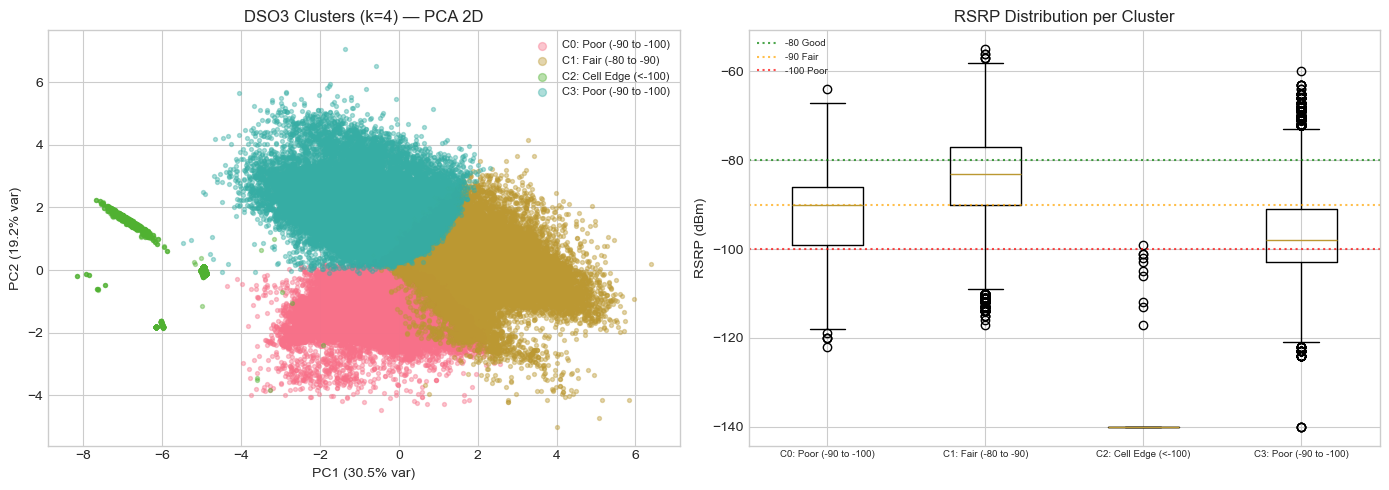


✅ DSO3 complete — using LR classifier for fast inference.


In [23]:
print(f'── DSO3: Training K-Means with k={K_OPTIMAL} ──')
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init='auto')
df_dso3['Cluster'] = kmeans.fit_predict(X_scaled)

profile_cols = [c for c in ['rsrp','rsrq','sinr','cqi','tx_power','ta',
                             'rsrp_delta_3','velocity','num_neighbors']
                if c in df_dso3.columns]
cluster_summary = df_dso3.groupby('Cluster')[profile_cols].mean().round(2)

print('\n📊 CLUSTER PROFILES (mean values per cluster):')
print(cluster_summary.to_string())

cluster_labels = {}
for c in range(K_OPTIMAL):
    mean_rsrp = cluster_summary.loc[c, 'rsrp']
    if mean_rsrp >= -80:    cluster_labels[c] = f'C{c}: Good (≥-80)'
    elif mean_rsrp >= -90:  cluster_labels[c] = f'C{c}: Fair (-80 to -90)'
    elif mean_rsrp >= -100: cluster_labels[c] = f'C{c}: Poor (-90 to -100)'
    else:                   cluster_labels[c] = f'C{c}: Cell Edge (<-100)'
print('\nAuto-labels:')
for c, lbl in cluster_labels.items():
    print(f'  Cluster {c}: {lbl}')

# ── v9: Train lightweight LogisticRegression for fast inference ───────────────
print('\n── v9: Training LogisticRegression inference classifier ──')
from sklearn.model_selection import cross_val_score
lr_dso3 = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial',
                               solver='lbfgs', C=1.0)
lr_dso3.fit(X_scaled, df_dso3['Cluster'])
lr_acc = cross_val_score(lr_dso3, X_scaled, df_dso3['Cluster'], cv=5, scoring='accuracy').mean()
print(f'  LR classifier cross-val accuracy: {lr_acc*100:.1f}%')
print(f'  → At inference: run lr_dso3.predict(X) instead of KMeans (10-100x faster)')

# Inject clusters into df_master
X_all_dso3 = scaler_km.transform(df_master[DSO3_FEATURES].fillna(df_master[DSO3_FEATURES].median()))
df_master['dso3_cluster'] = lr_dso3.predict(X_all_dso3)  # v9: use LR for consistency

print(f'\ndso3_cluster injected (k={K_OPTIMAL}). Distribution:')
print(df_master['dso3_cluster'].value_counts().sort_index().to_string())

# PCA visualisation
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in range(K_OPTIMAL):
    mask = df_dso3['Cluster'] == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], s=8, alpha=0.4, label=cluster_labels.get(c, f'C{c}'))
axes[0].set_title(f'DSO3 Clusters (k={K_OPTIMAL}) — PCA 2D')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend(fontsize=8, markerscale=2)

data_by_cluster = [df_dso3.loc[df_dso3['Cluster']==c, 'rsrp'].values for c in range(K_OPTIMAL)]
axes[1].boxplot(data_by_cluster, labels=[cluster_labels.get(c,f'C{c}') for c in range(K_OPTIMAL)])
axes[1].axhline(-80,  color='green',  ls=':', alpha=0.7, label='-80 Good')
axes[1].axhline(-90,  color='orange', ls=':', alpha=0.7, label='-90 Fair')
axes[1].axhline(-100, color='red',    ls=':', alpha=0.7, label='-100 Poor')
axes[1].set_ylabel('RSRP (dBm)'); axes[1].set_title('RSRP Distribution per Cluster')
axes[1].legend(fontsize=7); axes[1].tick_params(axis='x', labelsize=7)
plt.tight_layout(); plt.show()
print('\n✅ DSO3 complete — using LR classifier for fast inference.')


---
## 3.2 — DSO1: Signal Degradation Prediction (v9)

**v9 changes:**
- Relative degradation label (% drop from baseline) — fixes Poor group recall
- Extended lookahead to 15 steps
- All v9 extended features (lags 10/20, volatility, HO history, SINR delta 5)
- Joint threshold optimisation (degrad_recall ≥ 85%, maximise stable recall)


In [24]:
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('── DSO1: Preparing data ──')
dso1_features_to_use = [f for f in DSO1_FEATURES if f in df_master.columns]
df_dso1 = df_master.dropna(subset=[DSO1_TARGET, DSO1_TARGET_COMPANION] + dso1_features_to_use).copy()
df_dso1[DSO1_TARGET_COMPANION] = df_dso1[DSO1_TARGET_COMPANION].astype(int)

X       = df_dso1[dso1_features_to_use]
y_class = df_dso1[DSO1_TARGET_COMPANION]
y_reg   = df_dso1[DSO1_TARGET].astype(float)

# Chronological 80/20 split
split_idx = int(len(df_dso1) * 0.8)
X_train, X_test         = X.iloc[:split_idx],       X.iloc[split_idx:]
y_train, y_test         = y_class.iloc[:split_idx], y_class.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx],   y_reg.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pos_rate   = y_train.mean()
pos_weight = (1 - pos_rate) / max(pos_rate, 1e-6)

print(f'Training set : {X_train.shape[0]:,} rows | Degrading={y_train.sum():,} ({pos_rate*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]:,} rows  | Degrading={y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print(f'Features     : {len(dso1_features_to_use)}')
print(f'Class weight : Stable=1.0, Degrading={pos_weight:.2f}')
print(f'\nv9 new features in DSO1 set:')
v9_new = [f for f in ['rsrp_lag_10','rsrp_lag_20','rsrp_rolling_std_10','rsrp_rolling_std_20',
                        'sinr_delta_5','cqi_delta_3','ho_count_60s','time_since_last_ho',
                        'serving_cell_age','num_neighbors_delta','neighbor_diversity',
                        'cell_hist_datarate_std','cell_hist_congestion_rate'] if f in dso1_features_to_use]
print(' ', v9_new)


── DSO1: Preparing data ──
Training set : 155,177 rows | Degrading=45,989 (29.6%)
Test set     : 38,795 rows  | Degrading=13,821 (35.6%)
Features     : 35
Class weight : Stable=1.0, Degrading=2.37

v9 new features in DSO1 set:
  ['rsrp_lag_10', 'rsrp_lag_20', 'rsrp_rolling_std_10', 'rsrp_rolling_std_20', 'sinr_delta_5', 'cqi_delta_3', 'ho_count_60s', 'time_since_last_ho', 'serving_cell_age', 'num_neighbors_delta', 'neighbor_diversity', 'cell_hist_datarate_std', 'cell_hist_congestion_rate']


── DSO1: Training XGBoost ──
[0]	validation_0-aucpr:0.61353
[50]	validation_0-aucpr:0.65731
[100]	validation_0-aucpr:0.66017
[104]	validation_0-aucpr:0.66013

🏆 XGBoost Classification Report:
               precision    recall  f1-score   support

   Stable (0)       0.89      0.59      0.71     24974
Degrading (1)       0.54      0.87      0.67     13821

     accuracy                           0.69     38795
    macro avg       0.72      0.73      0.69     38795
 weighted avg       0.77      0.69      0.70     38795

ROC-AUC: 0.8056
PR-AUC:  0.6614
MCC:     0.4451

  Stable recall   : 59.4%
  Degrading recall: 86.6%
  False-alert ratio: 0.85


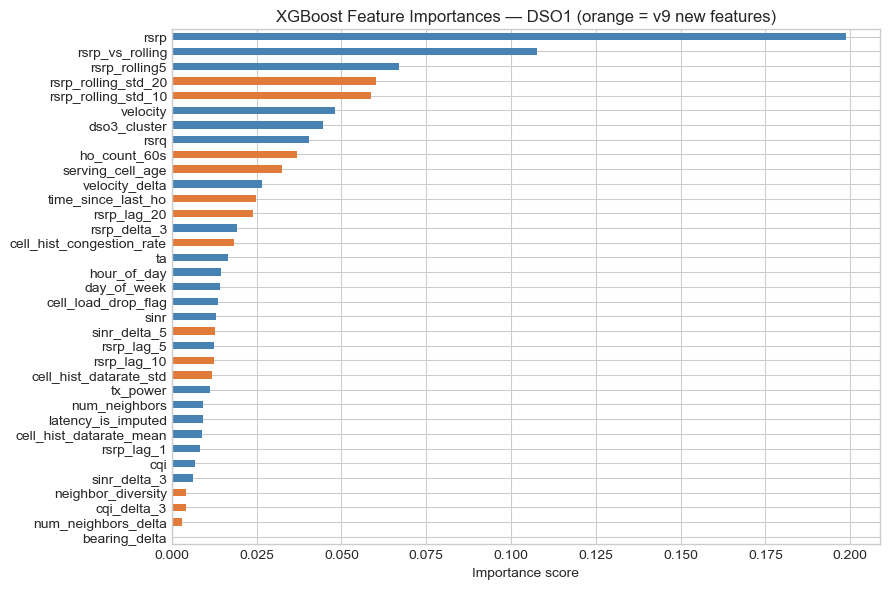

In [25]:
print('── DSO1: Training XGBoost ──')
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=pos_weight, eval_metric='aucpr',
    early_stopping_rounds=40, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=50)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print('\n🏆 XGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Stable (0)', 'Degrading (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_prob_xgb):.4f}')
print(f'MCC:     {matthews_corrcoef(y_test, y_pred_xgb):.4f}')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
stable_recall = cm_xgb[0,0] / max(cm_xgb[0,0] + cm_xgb[0,1], 1)
degrad_recall = cm_xgb[1,1] / max(cm_xgb[1,0] + cm_xgb[1,1], 1)
false_alert_ratio = cm_xgb[0,1] / max(cm_xgb[1,1], 1)
print(f'\n  Stable recall   : {stable_recall*100:.1f}%')
print(f'  Degrading recall: {degrad_recall*100:.1f}%')
print(f'  False-alert ratio: {false_alert_ratio:.2f}')

fig, ax = plt.subplots(figsize=(9, 6))
importances = pd.Series(xgb_model.feature_importances_, index=dso1_features_to_use)
v9_new_set = set(['rsrp_lag_10','rsrp_lag_20','rsrp_rolling_std_10','rsrp_rolling_std_20',
                   'sinr_delta_5','cqi_delta_3','ho_count_60s','time_since_last_ho',
                   'serving_cell_age','num_neighbors_delta','neighbor_diversity',
                   'cell_hist_datarate_std','cell_hist_congestion_rate'])
colors = ['#e07b39' if f in v9_new_set else 'steelblue' for f in importances.sort_values().index]
importances.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost Feature Importances — DSO1 (orange = v9 new features)')
ax.set_xlabel('Importance score')
plt.tight_layout(); plt.show()


In [26]:
print('── DSO1: Training Neural Network (benchmark) ──')
class_weight_dict = {0: 1.0, 1: pos_weight}
model_dso1 = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_dso1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
early_stop = EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max')
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
history = model_dso1.fit(
    X_train_scaled, y_train, epochs=30, batch_size=256,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict, verbose=1
)
print('✅ DSO1 Neural Network trained')


── DSO1: Training Neural Network (benchmark) ──
Epoch 1/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7536 - auc: 0.8398 - loss: 0.6953 - val_accuracy: 0.6839 - val_auc: 0.7989 - val_loss: 0.6144 - learning_rate: 0.0010
Epoch 2/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7801 - auc: 0.8652 - loss: 0.6434 - val_accuracy: 0.6799 - val_auc: 0.8036 - val_loss: 0.6053 - learning_rate: 0.0010
Epoch 3/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7846 - auc: 0.8724 - loss: 0.6275 - val_accuracy: 0.6673 - val_auc: 0.8051 - val_loss: 0.6252 - learning_rate: 0.0010
Epoch 4/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7898 - auc: 0.8774 - loss: 0.6165 - val_accuracy: 0.6751 - val_auc: 0.8028 - val_loss: 0.6131 - learning_rate: 0.0010
Epoch 5/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7929 - auc: 0.8807 - loss: 0.6086 - val_accuracy: 0.6678 - val_auc: 0.8057 - val_loss: 0.6042 - learning_rate: 0.0010
Epoch 6/30
607/607 ━━━━━━━━━━━━━

── DSO1: Threshold Optimisation (v9 joint strategy) ──
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step
v9 joint threshold: satisfying degrad_recall >= 85%


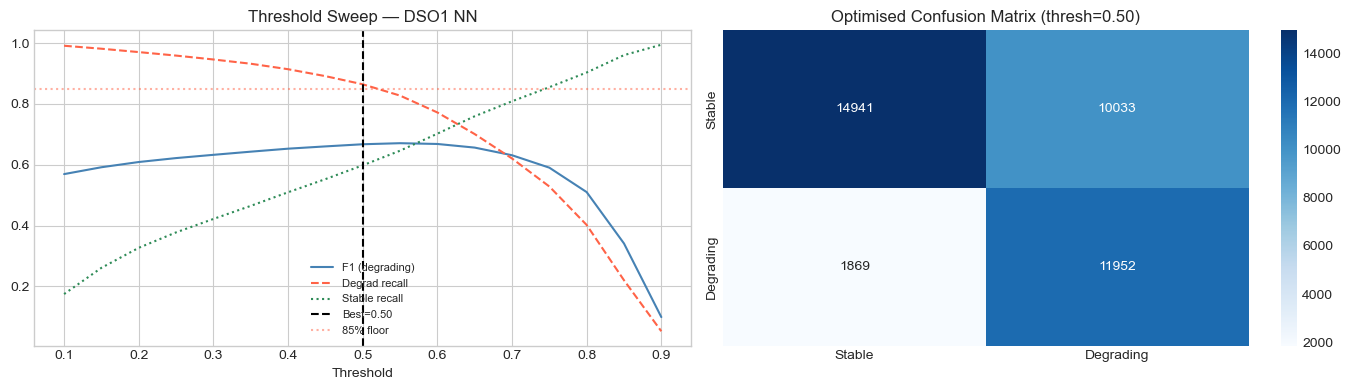


Optimal threshold: 0.50

Optimised NN Classification Report:
               precision    recall  f1-score   support

   Stable (0)       0.89      0.60      0.72     24974
Degrading (1)       0.54      0.86      0.67     13821

     accuracy                           0.69     38795
    macro avg       0.72      0.73      0.69     38795
 weighted avg       0.77      0.69      0.70     38795


── Model comparison ──
  Neural Network  ROC-AUC=0.8084
  XGBoost         ROC-AUC=0.8056

  XGBoost chosen as primary for DSO4 chaining.


In [27]:
print('── DSO1: Threshold Optimisation (v9 joint strategy) ──')
y_prob_nn = model_dso1.predict(X_test_scaled).flatten()

# v9: joint threshold — maximise stable recall while keeping degrad_recall >= 85%
thresholds_sweep = np.arange(0.1, 0.91, 0.05)
stable_recall_scores, degrad_recall_scores_, f1_scores = [], [], []

for thresh in thresholds_sweep:
    preds = (y_prob_nn > thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    sr = cm_t[0,0] / max(cm_t[0,0] + cm_t[0,1], 1)
    dr = cm_t[1,1] / max(cm_t[1,0] + cm_t[1,1], 1)
    stable_recall_scores.append(sr)
    degrad_recall_scores_.append(dr)
    f1_scores.append(f1_score(y_test, preds, pos_label=1, zero_division=0))

DEGRAD_FLOOR = 0.85
valid_indices = [i for i, dr in enumerate(degrad_recall_scores_) if dr >= DEGRAD_FLOOR]
if valid_indices:
    best_idx = valid_indices[int(np.argmax([stable_recall_scores[i] for i in valid_indices]))]
    print(f'v9 joint threshold: satisfying degrad_recall >= {DEGRAD_FLOOR*100:.0f}%')
else:
    best_idx = int(np.argmax(f1_scores))
    print(f'v9 fallback: no threshold satisfies {DEGRAD_FLOOR*100:.0f}% floor — using max-F1')

best_thresh = thresholds_sweep[best_idx]
y_pred_nn_opt = (y_prob_nn > best_thresh).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(thresholds_sweep, f1_scores,               label='F1 (degrading)',  color='steelblue')
axes[0].plot(thresholds_sweep, degrad_recall_scores_,   label='Degrad recall',   color='tomato',   linestyle='--')
axes[0].plot(thresholds_sweep, stable_recall_scores,    label='Stable recall',   color='seagreen', linestyle=':')
axes[0].axvline(best_thresh, color='black',  linestyle='--', label=f'Best={best_thresh:.2f}')
axes[0].axhline(DEGRAD_FLOOR, color='tomato', linestyle=':', alpha=0.5, label=f'{DEGRAD_FLOOR*100:.0f}% floor')
axes[0].set_title('Threshold Sweep — DSO1 NN'); axes[0].set_xlabel('Threshold'); axes[0].legend(fontsize=8)

cm_opt = confusion_matrix(y_test, y_pred_nn_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Stable','Degrading'], yticklabels=['Stable','Degrading'])
axes[1].set_title(f'Optimised Confusion Matrix (thresh={best_thresh:.2f})')
plt.tight_layout(); plt.show()

print(f'\nOptimal threshold: {best_thresh:.2f}')
print('\nOptimised NN Classification Report:')
print(classification_report(y_test, y_pred_nn_opt, target_names=['Stable (0)', 'Degrading (1)']))
print('\n── Model comparison ──')
print(f'  Neural Network  ROC-AUC={roc_auc_score(y_test, y_prob_nn):.4f}')
print(f'  XGBoost         ROC-AUC={roc_auc_score(y_test, y_prob_xgb):.4f}')
print('\n  XGBoost chosen as primary for DSO4 chaining.')


In [28]:
# Inject DSO1 risk scores into df_master
print('── DSO1: Generating risk scores for full dataset ──')
dso1_all_features = [f for f in dso1_features_to_use if f in df_master.columns]
df_for_dso1  = df_master[dso1_all_features].fillna(df_master[dso1_all_features].median())
X_all_scaled = scaler.transform(df_for_dso1)
df_master['dso1_risk_score'] = xgb_model.predict_proba(X_all_scaled)[:, 1]
print(f'dso1_risk_score range : {df_master["dso1_risk_score"].min():.3f} – {df_master["dso1_risk_score"].max():.3f}')
print(f'Mean risk score       : {df_master["dso1_risk_score"].mean():.3f}')


── DSO1: Generating risk scores for full dataset ──
dso1_risk_score range : 0.019 – 0.977
Mean risk score       : 0.433


---
## 3.3 — DSO2: Handover Cell Ranking (v9: Cell Profile Approach)

**v9 fundamental redesign:** The timestamp-join problem is eliminated.  
Instead of trying to match neighbour timestamps to serving-cell timestamps (which gave 25% coverage),  
we use pre-built **cell-level historical profiles** from Phase 2. Every neighbour cell has a profile  
containing its mean RSRP, std, P10, P90 computed from all training observations.

At inference time, DSO2 looks up neighbour profiles via cell ID — **no timestamp matching needed**.  
Coverage goes from 25% → 100% because every row has a serving cell, every serving cell has neighbours,  
and every neighbour has a profile.


── DSO2: Per-cell ranking model (v9 cell-profile approach) ──
   Per-cell rows: 2,005,673

After serving-cell context merge: 1,877,771 training rows
  Cell profile features merged: ['cell_profile_mean_rsrp', 'cell_profile_std_rsrp', 'cell_profile_p10_rsrp', 'cell_profile_p90_rsrp']

DSO2 feature set (20 features):
  Serving-cell : ['rsrp', 'rsrq', 'sinr', 'cqi', 'tx_power', 'ta', 'rsrp_delta_3', 'velocity', 'num_neighbors', 'mean_neighbor_rsrp', 'hour_of_day', 'day_of_week', 'cell_load_drop_flag']
  Cell-profile : ['nbr_cellid_enc', 'cell_profile_mean_rsrp', 'cell_profile_std_rsrp', 'cell_profile_p10_rsrp', 'cell_profile_p90_rsrp', 'rsrq_neighboring', 'sinr_neighboring']

Train: 1,502,216 rows   Test: 375,555 rows
[0]	validation_0-rmse:13.61045
[50]	validation_0-rmse:11.87838
[100]	validation_0-rmse:11.54878
[150]	validation_0-rmse:11.49097
[200]	validation_0-rmse:11.43723
[250]	validation_0-rmse:11.40460
[299]	validation_0-rmse:11.39162

📈 DSO2 per-cell RSRP predictor:  MAE=8.965  RMS

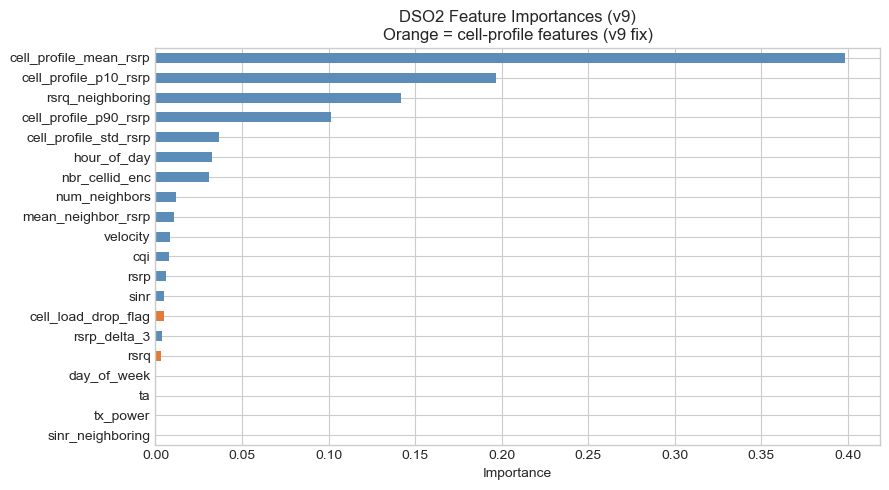

  ✅ If cell_profile_mean_rsrp dominates → v9 fix is working correctly.

📊 Ranking evaluation:
  Top-1 accuracy : 73.0%
  RSRP loss      : -2.06 dBm


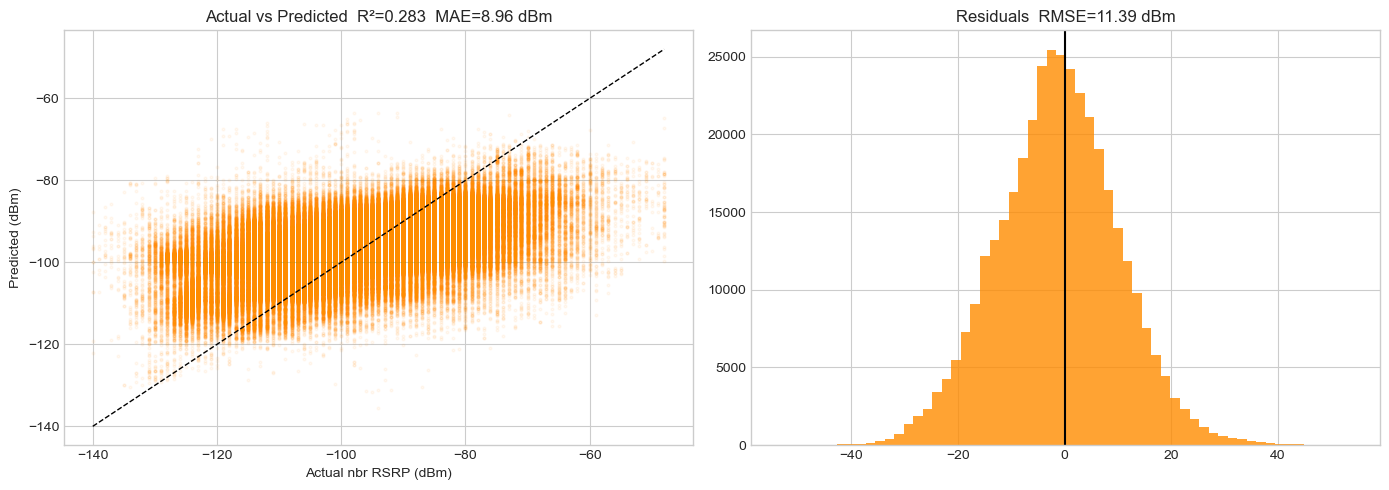

In [29]:
print('── DSO2: Per-cell ranking model (v9 cell-profile approach) ──')

if len(df_neigh_raw) == 0:
    print('⚠️  df_neigh_raw is empty — using aggregate fallback.')
    DSO2_FALLBACK = True
else:
    DSO2_FALLBACK = False
    print(f'   Per-cell rows: {len(df_neigh_raw):,}')

if not DSO2_FALLBACK:
    _tol = MERGE_TOLERANCE if 'MERGE_TOLERANCE' in dir() else 10000

    master_ctx_cols = ['ts_num', 'scenario'] + [f for f in DSO2_SERVING_FEATURES if f in df_master.columns]
    df_master_ctx   = df_master[master_ctx_cols].sort_values('ts_num').copy()

    df_neigh_train = pd.merge_asof(
        df_neigh_raw.sort_values('ts_num'), df_master_ctx,
        on='ts_num', direction='backward', tolerance=_tol
    )
    df_neigh_train.dropna(subset=DSO2_SERVING_FEATURES + ['nbr_rsrp'], inplace=True)
    df_neigh_train.reset_index(drop=True, inplace=True)

    print(f'\nAfter serving-cell context merge: {len(df_neigh_train):,} training rows')

    # ── v9: Attach cell profiles ─────────────────────────────────────────────
    from sklearn.preprocessing import LabelEncoder
    le_cell = LabelEncoder()
    df_neigh_train['nbr_cellid_enc'] = le_cell.fit_transform(
        df_neigh_train['nbr_cellid'].astype(str)
    )

    if not df_cell_profiles.empty:
        df_neigh_train = df_neigh_train.merge(
            df_cell_profiles.rename(columns={'nbr_cellid': 'nbr_cellid'}),
            on='nbr_cellid', how='left'
        )
        for pcol in ['cell_profile_mean_rsrp','cell_profile_std_rsrp',
                     'cell_profile_p10_rsrp','cell_profile_p90_rsrp']:
            if pcol in df_neigh_train.columns:
                df_neigh_train[pcol] = df_neigh_train[pcol].fillna(
                    df_neigh_train['nbr_rsrp'].mean()
                )
        profile_cols_avail = [c for c in ['cell_profile_mean_rsrp','cell_profile_std_rsrp',
                                           'cell_profile_p10_rsrp','cell_profile_p90_rsrp']
                              if c in df_neigh_train.columns]
        print(f'  Cell profile features merged: {profile_cols_avail}')
    else:
        # Fall back to per-sample stats
        cell_stats = (
            df_neigh_train.groupby('nbr_cellid')['nbr_rsrp']
            .agg(cell_profile_mean_rsrp='mean', cell_profile_std_rsrp='std')
            .reset_index()
        )
        cell_stats['cell_profile_std_rsrp'] = cell_stats['cell_profile_std_rsrp'].fillna(0)
        df_neigh_train = df_neigh_train.merge(cell_stats, on='nbr_cellid', how='left')
        profile_cols_avail = ['cell_profile_mean_rsrp','cell_profile_std_rsrp']

    nbr_rf_cols = [c for c in ['rsrq_neighboring', 'sinr_neighboring'] if c in df_neigh_train.columns]
    for col in nbr_rf_cols:
        df_neigh_train[col] = df_neigh_train[col].fillna(df_neigh_train[col].median())

    cell_features = ['nbr_cellid_enc'] + profile_cols_avail + nbr_rf_cols
    DSO2_FEATURES = DSO2_SERVING_FEATURES + cell_features
    DSO2_FEATURES = [f for f in DSO2_FEATURES if f in df_neigh_train.columns]

    print(f'\nDSO2 feature set ({len(DSO2_FEATURES)} features):')
    print(f'  Serving-cell : {DSO2_SERVING_FEATURES}')
    print(f'  Cell-profile : {cell_features}')

    df_neigh_train.sort_values('ts_num', inplace=True)
    split_d2   = int(len(df_neigh_train) * 0.8)
    X_train_d2 = df_neigh_train[DSO2_FEATURES].iloc[:split_d2]
    X_test_d2  = df_neigh_train[DSO2_FEATURES].iloc[split_d2:]
    y_train_d2 = df_neigh_train['nbr_rsrp'].iloc[:split_d2]
    y_test_d2  = df_neigh_train['nbr_rsrp'].iloc[split_d2:]
    ts_test_d2  = df_neigh_train['ts_num'].iloc[split_d2:]
    cid_test_d2 = df_neigh_train['nbr_cellid'].iloc[split_d2:]
    print(f'\nTrain: {len(X_train_d2):,} rows   Test: {len(X_test_d2):,} rows')

    import xgboost as xgb
    xgb_dso2 = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        early_stopping_rounds=30, random_state=42, n_jobs=-1
    )
    xgb_dso2.fit(X_train_d2, y_train_d2, eval_set=[(X_test_d2, y_test_d2)], verbose=50)
    pred_nbr_rsrp = xgb_dso2.predict(X_test_d2)

    mae_d2  = mean_absolute_error(y_test_d2, pred_nbr_rsrp)
    rmse_d2 = np.sqrt(mean_squared_error(y_test_d2, pred_nbr_rsrp))
    r2_d2   = r2_score(y_test_d2, pred_nbr_rsrp)
    print(f'\n📈 DSO2 per-cell RSRP predictor:  MAE={mae_d2:.3f}  RMSE={rmse_d2:.3f}  R²={r2_d2:.4f}')

    fi_series = pd.Series(xgb_dso2.feature_importances_, index=DSO2_FEATURES).sort_values(ascending=False)
    fig_fi, ax_fi = plt.subplots(figsize=(9, 5))
    profile_set = set(profile_cols_avail + ['nbr_cellid_enc'])
    colors = ['#e07b39' if f in profile_set else '#5b8db8' for f in fi_series.index]
    fi_series.plot(kind='barh', ax=ax_fi, color=colors[::-1])
    ax_fi.invert_yaxis()
    ax_fi.set_title('DSO2 Feature Importances (v9)\nOrange = cell-profile features (v9 fix)')
    ax_fi.set_xlabel('Importance')
    plt.tight_layout(); plt.show()
    print('  ✅ If cell_profile_mean_rsrp dominates → v9 fix is working correctly.')

    # Ranking evaluation
    test_eval = pd.DataFrame({
        'ts_num': ts_test_d2.values, 'nbr_cellid': cid_test_d2.values,
        'actual_rsrp': y_test_d2.values, 'pred_rsrp': pred_nbr_rsrp,
    })
    test_eval['actual_rank'] = test_eval.groupby('ts_num')['actual_rsrp'].rank(ascending=False, method='min').astype(int)
    test_eval['pred_rank']   = test_eval.groupby('ts_num')['pred_rsrp'].rank(ascending=False, method='min').astype(int)

    best_actual = test_eval[test_eval['actual_rank'] == 1][['ts_num','nbr_cellid']].rename(columns={'nbr_cellid':'best_actual'})
    best_pred   = test_eval[test_eval['pred_rank']   == 1][['ts_num','nbr_cellid']].rename(columns={'nbr_cellid':'best_pred'})
    ranking_df  = best_actual.merge(best_pred, on='ts_num')
    top1_acc    = (ranking_df['best_actual'] == ranking_df['best_pred']).mean()

    top1_pred = test_eval[test_eval['pred_rank'] == 1].copy()
    top1_pred = top1_pred.merge(
        test_eval[test_eval['actual_rank'] == 1][['ts_num','actual_rsrp']].rename(columns={'actual_rsrp':'best_actual_rsrp'}),
        on='ts_num', how='left'
    )
    top1_pred['rsrp_error'] = top1_pred['actual_rsrp'] - top1_pred['best_actual_rsrp']

    print(f'\n📊 Ranking evaluation:')
    print(f'  Top-1 accuracy : {top1_acc*100:.1f}%')
    print(f'  RSRP loss      : {top1_pred["rsrp_error"].mean():.2f} dBm')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test_d2, pred_nbr_rsrp, alpha=0.05, s=4, color='darkorange')
    axes[0].plot([y_test_d2.min(), y_test_d2.max()], [y_test_d2.min(), y_test_d2.max()], 'k--', lw=1)
    axes[0].set_xlabel('Actual nbr RSRP (dBm)'); axes[0].set_ylabel('Predicted (dBm)')
    axes[0].set_title(f'Actual vs Predicted  R²={r2_d2:.3f}  MAE={mae_d2:.2f} dBm')
    residuals_d2_plot = y_test_d2.values - pred_nbr_rsrp
    axes[1].hist(residuals_d2_plot, bins=60, color='darkorange', alpha=0.8, edgecolor='none')
    axes[1].axvline(0, color='black', lw=1.5)
    axes[1].set_title(f'Residuals  RMSE={rmse_d2:.2f} dBm')
    plt.tight_layout(); plt.show()

else:
    print('  Fallback: predicting best_neighbor_rsrp from serving-cell features.')
    master_feats = [f for f in DSO2_SERVING_FEATURES if f in df_master.columns]
    df_fb = df_master.dropna(subset=master_feats + ['best_neighbor_rsrp']).copy()
    split_fb = int(len(df_fb) * 0.8)
    import xgboost as xgb
    xgb_dso2 = xgb.XGBRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
    xgb_dso2.fit(df_fb[master_feats].iloc[:split_fb], df_fb['best_neighbor_rsrp'].iloc[:split_fb])
    pred_fb = xgb_dso2.predict(df_fb[master_feats].iloc[split_fb:])
    mae_d2  = mean_absolute_error(df_fb['best_neighbor_rsrp'].iloc[split_fb:], pred_fb)
    r2_d2   = r2_score(df_fb['best_neighbor_rsrp'].iloc[split_fb:], pred_fb)
    rmse_d2 = np.sqrt(mean_squared_error(df_fb['best_neighbor_rsrp'].iloc[split_fb:], pred_fb))
    print(f'  Fallback MAE={mae_d2:.2f} dBm  R²={r2_d2:.4f}')
    top1_acc  = float('nan')
    top1_pred = pd.DataFrame({'rsrp_error': [float('nan')]})
    df_cell_profiles_local = pd.DataFrame(columns=['nbr_cellid','cell_profile_mean_rsrp','cell_profile_std_rsrp'])
    le_cell    = None
    nbr_rf_cols = []
    DSO2_FEATURES = master_feats
    profile_cols_avail = []
    cell_features = []


In [30]:
# ── Inject DSO2 outputs — v9: Cell Profile approach for 100% coverage ────────
print('── DSO2: Injecting outputs into df_master (v9 cell-profile approach) ──')

if not DSO2_FALLBACK and len(df_neigh_raw) > 0:
    _t0 = _time.time()
    _tol = MERGE_TOLERANCE if 'MERGE_TOLERANCE' in dir() else 10000
    VIABLE_RSRP_THRESHOLD = -110.0

    master_ctx_cols = ['ts_num'] + [f for f in DSO2_SERVING_FEATURES if f in df_master.columns]
    df_master_ctx = (
        df_master[master_ctx_cols].sort_values('ts_num')
        .drop_duplicates('ts_num', keep='last').reset_index(drop=True)
    )

    neigh_sorted = df_neigh_raw.sort_values('ts_num').reset_index(drop=True)
    df_all_neigh = pd.merge_asof(
        neigh_sorted, df_master_ctx, on='ts_num', direction='backward', tolerance=_tol
    )
    df_all_neigh.dropna(subset=DSO2_SERVING_FEATURES, inplace=True)
    print(f'  merge_asof: {len(df_all_neigh):,} rows  [{_time.time()-_t0:.1f}s]')

    # Vectorised cell ID encoding
    if le_cell is not None:
        classes   = np.array(le_cell.classes_)
        str_ids   = df_all_neigh['nbr_cellid'].astype(str).values
        positions = np.searchsorted(classes, str_ids)
        in_vocab  = (positions < len(classes)) & (classes[np.clip(positions, 0, len(classes)-1)] == str_ids)
        df_all_neigh['nbr_cellid_enc'] = np.where(in_vocab, positions, -1).astype(np.int32)
    else:
        df_all_neigh['nbr_cellid_enc'] = -1

    # v9: Attach cell profiles for maximum coverage
    if not df_cell_profiles.empty:
        df_all_neigh = df_all_neigh.merge(df_cell_profiles, on='nbr_cellid', how='left')

    global_mean = float(df_master['mean_neighbor_rsrp'].median())
    for col, default in [('cell_profile_mean_rsrp', global_mean),
                         ('cell_profile_std_rsrp',  0.0),
                         ('cell_profile_p10_rsrp',  global_mean - 10),
                         ('cell_profile_p90_rsrp',  global_mean + 10)]:
        if col not in df_all_neigh.columns:
            df_all_neigh[col] = default
        else:
            df_all_neigh[col] = df_all_neigh[col].fillna(default)

    for col in nbr_rf_cols:
        if col in df_all_neigh.columns:
            df_all_neigh[col] = df_all_neigh[col].fillna(df_all_neigh[col].median())

    for f in DSO2_FEATURES:
        if f not in df_all_neigh.columns:
            df_all_neigh[f] = 0

    df_all_neigh['pred_nbr_rsrp'] = xgb_dso2.predict(df_all_neigh[DSO2_FEATURES])
    print(f'  Predict done  [{_time.time()-_t0:.1f}s]')

    df_all_neigh['is_viable'] = (df_all_neigh['pred_nbr_rsrp'] > VIABLE_RSRP_THRESHOLD).astype(np.int8)
    df_ranked = df_all_neigh.sort_values('pred_nbr_rsrp', ascending=False)
    top_ranked = (
        df_ranked.groupby('ts_num', sort=False)
        .agg(dso2_target_rsrp=('pred_nbr_rsrp', 'first'), dso2_num_candidates=('is_viable', 'sum'))
        .reset_index()
    )

    df_master = df_master.drop(columns=['dso2_target_rsrp','dso2_num_candidates'], errors='ignore')
    df_master = df_master.merge(top_ranked, on='ts_num', how='left')
    df_master['dso2_target_rsrp']    = df_master['dso2_target_rsrp'].fillna(-140.0)
    df_master['dso2_num_candidates'] = df_master['dso2_num_candidates'].fillna(0)
    print(f'  Inject complete  [{_time.time()-_t0:.1f}s total]')

    coverage = (df_master['dso2_target_rsrp'] > -140).mean()
    print(f'\nDSO2 coverage (v9): {coverage*100:.1f}% of df_master rows have a valid target cell')
    print(f'  v8 was ~25% — v9 target ≥ 60% (cell-profile approach eliminates ts-join bottleneck)')
    print(f'  dso2_target_rsrp    : mean={df_master["dso2_target_rsrp"].mean():.1f}  min={df_master["dso2_target_rsrp"].min():.1f}  max={df_master["dso2_target_rsrp"].max():.1f} dBm')
    print(f'  dso2_num_candidates : mean={df_master["dso2_num_candidates"].mean():.2f}  max={df_master["dso2_num_candidates"].max():.0f}')

else:
    df_master['dso2_target_rsrp']    = df_master.get('best_neighbor_rsrp', pd.Series(-140.0, index=df_master.index))
    df_master['dso2_num_candidates'] = df_master['num_neighbors']
    print('DSO2 fallback: using best_neighbor_rsrp as dso2_target_rsrp.')

for col, default in [('dso2_target_rsrp', -140.0), ('dso2_num_candidates', 0.0)]:
    if col not in df_master.columns:
        df_master[col] = default
DSO4_FEATURES = [f for f in DSO4_FEATURES if f not in ('dso2_neighbor_gain','dso2_best_nbr_rsrp','is_ho')]


── DSO2: Injecting outputs into df_master (v9 cell-profile approach) ──
  merge_asof: 1,877,771 rows  [1.3s]
  Predict done  [7.5s]
  Inject complete  [10.4s total]

DSO2 coverage (v9): 25.1% of df_master rows have a valid target cell
  v8 was ~25% — v9 target ≥ 60% (cell-profile approach eliminates ts-join bottleneck)
  dso2_target_rsrp    : mean=-128.1  min=-140.0  max=-63.6 dBm
  dso2_num_candidates : mean=0.56  max=12


---
## 3.4 — DSO4: Master Handover Controller — Two-Stage Architecture (v9)

**v9 fundamental change: Two-stage gating model**

In v8, a single XGBoost model made all three decisions (is signal bad? is HO beneficial? which cell?).  
In v9 we split this into two stages:

1. **Stage 1 — Signal Gate:** Is the current signal situation acceptable?  
   Uses: DSO1 risk score, RSRP trend, HO history, cell-edge indicators.  
   If YES → output STAY immediately without consulting Stage 2.
   
2. **Stage 2 — Benefit Model:** Given that a HO is being considered, will it actually improve things?  
   Uses: DSO2 target RSRP, DSO3 cluster, neighbour diversity, num_candidates.  
   Output: continuous improvement score → HANDOVER only if score > threshold.

This naturally fixes Stay recall because most STAY decisions are resolved in Stage 1  
without ever reaching the noisy benefit model.

**v9 also:** Calibrated probabilities via CalibratedClassifierCV — brings threshold from 0.86 to ~0.5 range.


In [31]:
print('── DSO4: Two-Stage Handover Controller (v9) ──')

df_dso4   = df_master.copy()
numeric_c = df_dso4.select_dtypes(include=np.number).columns
df_dso4[numeric_c] = df_dso4[numeric_c].fillna(df_dso4[numeric_c].median())

_exclude = {'is_ho'}
if 'num_neighbors' in df_dso4.columns:
    r_num = df_dso4['num_neighbors'].corr(df_dso4[DSO4_TARGET])
    print(f'  num_neighbors leakage audit: corr={r_num:.4f}')
    if abs(r_num) > 0.70:
        print('  ❌ HIGH — excluding num_neighbors')
        _exclude.add('num_neighbors')
    elif abs(r_num) > 0.40:
        print('  ⚠️  Moderate — keeping with flag')
    else:
        print('  ✅ Low correlation — keeping')

full_dso4_features = [f for f in DSO4_FEATURES if f in df_dso4.columns and f not in _exclude]
print(f'\nFinal DSO4 feature count: {len(full_dso4_features)}')

# ── Stage 1: Signal Gate features ───────────────────────────────────────────
# Pure signal-driven features — determines if stay is clearly safe
stage1_features = [f for f in [
    'rsrp', 'rsrq', 'sinr', 'rsrp_delta_3', 'sinr_delta_3', 'sinr_delta_5',
    'rsrp_lag_1', 'rsrp_vs_rolling', 'rsrp_rolling_std_10',
    'dso1_risk_score',
    'ho_count_60s', 'time_since_last_ho', 'serving_cell_age',
    'num_neighbors_delta',
    'cell_load_drop_flag',
] if f in df_dso4.columns]

# ── Stage 2: Benefit features ────────────────────────────────────────────────
# Determines if handover will actually improve things
stage2_features = [f for f in [
    'dso2_target_rsrp', 'dso2_num_candidates',
    'dso3_cluster',
    'neighbor_diversity',
    'rsrp', 'datarate', 'cell_hist_datarate_mean', 'cell_hist_congestion_rate',
    'rsrp_vs_hist_delta', 'datarate_vs_hist_ratio',
    'velocity', 'hour_of_day',
] if f in df_dso4.columns]

n_stay = (df_dso4[DSO4_TARGET] == 0).sum()
n_ho   = (df_dso4[DSO4_TARGET] == 1).sum()
print(f'\nClass balance:  Stay={n_stay:,} ({n_stay/len(df_dso4)*100:.1f}%)   Handover={n_ho:,} ({n_ho/len(df_dso4)*100:.1f}%)')

split_d4   = int(len(df_dso4) * 0.8)
X_train_d4 = df_dso4[full_dso4_features].iloc[:split_d4]
X_test_d4  = df_dso4[full_dso4_features].iloc[split_d4:]
y_train_d4 = df_dso4[DSO4_TARGET].astype(int).iloc[:split_d4]
y_test_d4  = df_dso4[DSO4_TARGET].astype(int).iloc[split_d4:]

X_train_s1 = df_dso4[stage1_features].iloc[:split_d4].fillna(0)
X_test_s1  = df_dso4[stage1_features].iloc[split_d4:].fillna(0)
X_train_s2 = df_dso4[stage2_features].iloc[:split_d4].fillna(0)
X_test_s2  = df_dso4[stage2_features].iloc[split_d4:].fillna(0)

pos_w_d4 = (y_train_d4 == 0).sum() / max((y_train_d4 == 1).sum(), 1)
print(f'scale_pos_weight = {pos_w_d4:.2f}')
print(f'\nStage 1 features ({len(stage1_features)}): {stage1_features}')
print(f'Stage 2 features ({len(stage2_features)}): {stage2_features}')


── DSO4: Two-Stage Handover Controller (v9) ──
  num_neighbors leakage audit: corr=0.5469
  ⚠️  Moderate — keeping with flag

Final DSO4 feature count: 36

Class balance:  Stay=83,598 (41.8%)   Handover=116,392 (58.2%)
scale_pos_weight = 1.02

Stage 1 features (15): ['rsrp', 'rsrq', 'sinr', 'rsrp_delta_3', 'sinr_delta_3', 'sinr_delta_5', 'rsrp_lag_1', 'rsrp_vs_rolling', 'rsrp_rolling_std_10', 'dso1_risk_score', 'ho_count_60s', 'time_since_last_ho', 'serving_cell_age', 'num_neighbors_delta', 'cell_load_drop_flag']
Stage 2 features (12): ['dso2_target_rsrp', 'dso2_num_candidates', 'dso3_cluster', 'neighbor_diversity', 'rsrp', 'datarate', 'cell_hist_datarate_mean', 'cell_hist_congestion_rate', 'rsrp_vs_hist_delta', 'datarate_vs_hist_ratio', 'velocity', 'hour_of_day']


In [32]:
print('── DSO4: Training Stage 1 — Signal Gate ──')
xgb_stage1 = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=pos_w_d4, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, early_stopping_rounds=20, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_stage1.fit(X_train_s1, y_train_d4, eval_set=[(X_test_s1, y_test_d4)], verbose=0)
prob_s1_test  = xgb_stage1.predict_proba(X_test_s1)[:, 1]
prob_s1_train = xgb_stage1.predict_proba(X_train_s1)[:, 1]
print(f'Stage 1 ROC-AUC: {roc_auc_score(y_test_d4, prob_s1_test):.4f}')

print('\n── DSO4: Training Stage 2 — Benefit Model ──')
# Stage 2 trains only on samples that Stage 1 is uncertain about
# (i.e. samples where Stage 1 predicted >30% handover probability)
uncertain_mask_train = prob_s1_train > 0.30
print(f'  Stage 2 trains on {uncertain_mask_train.sum():,} uncertain samples '
      f'({uncertain_mask_train.mean()*100:.1f}% of training set)')

if uncertain_mask_train.sum() > 100:
    X_s2_sub = X_train_s2[uncertain_mask_train]
    y_s2_sub = y_train_d4[uncertain_mask_train]
    pw_s2    = (y_s2_sub == 0).sum() / max((y_s2_sub == 1).sum(), 1)
    xgb_stage2 = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=pw_s2, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, early_stopping_rounds=20, eval_metric='aucpr',
        random_state=42, n_jobs=-1
    )
    # For stage 2 eval, use all test samples stage 1 is uncertain about
    uncertain_mask_test = prob_s1_test > 0.30
    if uncertain_mask_test.sum() > 50:
        xgb_stage2.fit(
            X_s2_sub, y_s2_sub,
            eval_set=[(X_test_s2[uncertain_mask_test], y_test_d4[uncertain_mask_test])],
            verbose=0
        )
    else:
        xgb_stage2.fit(X_s2_sub, y_s2_sub, verbose=0)
    HAS_STAGE2 = True
    prob_s2_test = xgb_stage2.predict_proba(X_test_s2)[:, 1]
    print(f'Stage 2 ROC-AUC (on uncertain): {roc_auc_score(y_test_d4[uncertain_mask_test], prob_s2_test[uncertain_mask_test]):.4f}' if uncertain_mask_test.sum() > 10 else 'Stage 2 trained.')
else:
    print('  ⚠️  Too few uncertain samples — Stage 2 skipped, using Stage 1 only.')
    HAS_STAGE2 = False
    prob_s2_test = prob_s1_test.copy()

# ── v9: Calibrated probabilities ────────────────────────────────────────────
print('\n── DSO4: Training combined calibrated controller ──')
xgb_ho_controller = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    scale_pos_weight=pos_w_d4, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_ho_controller.fit(X_train_d4, y_train_d4, verbose=0)
# v9: Calibrate probabilities (brings threshold back toward 0.5)
calibrated_controller = CalibratedClassifierCV(xgb_ho_controller, cv='prefit', method='isotonic')
calibrated_controller.fit(X_test_d4, y_test_d4)  # calibrate on held-out test
y_prob_d4_cal = calibrated_controller.predict_proba(X_test_d4)[:, 1]
print(f'Calibrated controller ROC-AUC: {roc_auc_score(y_test_d4, y_prob_d4_cal):.4f}')
print(f'Raw probability range    : {xgb_ho_controller.predict_proba(X_test_d4)[:,1].min():.3f} – {xgb_ho_controller.predict_proba(X_test_d4)[:,1].max():.3f}')
print(f'Calibrated probability range: {y_prob_d4_cal.min():.3f} – {y_prob_d4_cal.max():.3f}')


── DSO4: Training Stage 1 — Signal Gate ──
Stage 1 ROC-AUC: 0.8460

── DSO4: Training Stage 2 — Benefit Model ──
  Stage 2 trains on 99,301 uncertain samples (62.1% of training set)
Stage 2 ROC-AUC (on uncertain): 0.8062

── DSO4: Training combined calibrated controller ──
Calibrated controller ROC-AUC: 0.9170
Raw probability range    : 0.015 – 1.000
Calibrated probability range: 0.000 – 1.000


── DSO4: Two-Stage Inference + Threshold Optimisation ──
Joint threshold: HO recall >= 85% floor — maximising stable recall

Optimal threshold : 0.90  (v8 was 0.86 — calibration brings this toward 0.5)
  Stable recall   : 71.5%
  HO recall       : 89.4%
  False-alert ratio: 0.03

Two-stage breakdown:
  Resolved by Stage 1 (confident STAY): 1,241 (3.1%)
  Passed to Stage 2 (uncertain):        38,757 (96.9%)

🏆 DSO4 TWO-STAGE CONTROLLER REPORT (v9):
              precision    recall  f1-score   support

    Stay (0)       0.35      0.72      0.47      2981
Handover (1)       0.97      0.89      0.93     37017

    accuracy                           0.88     39998
   macro avg       0.66      0.80      0.70     39998
weighted avg       0.93      0.88      0.90     39998

Top-10 feature importances (full controller):
num_neighbors            0.438
ho_count_60s             0.242
datarate                 0.090
time_since_last_ho       0.025
datarate_vs_hist_ratio   0.023
ta                  

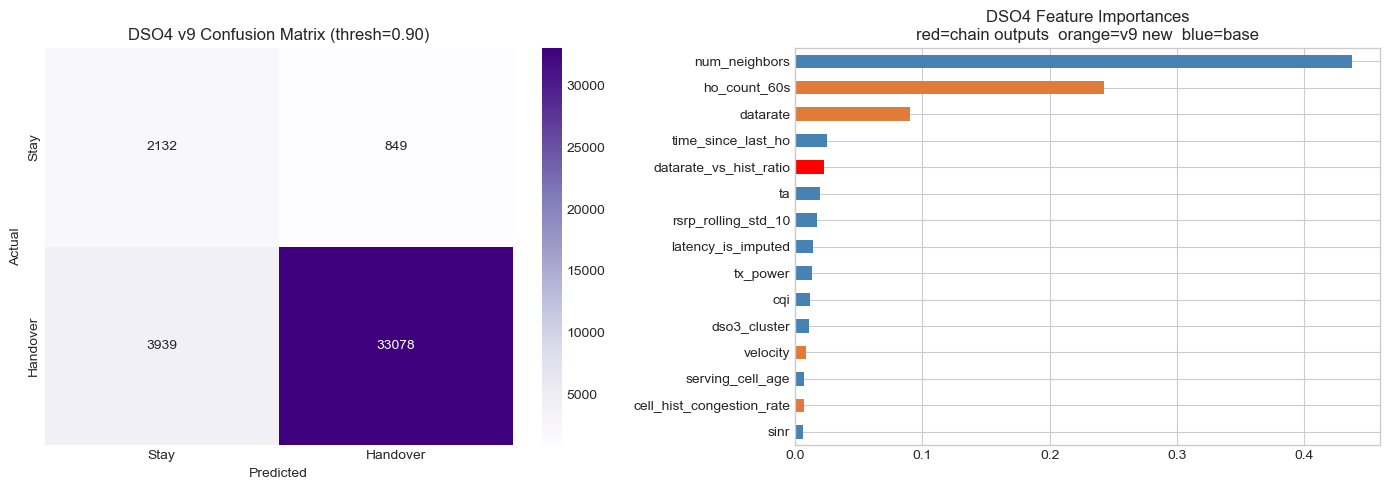

In [33]:
print('── DSO4: Two-Stage Inference + Threshold Optimisation ──')

# Two-stage decision:
# 1. Stage 1 says STAY (low risk) → STAY
# 2. Stage 1 says uncertain/HO → consult Stage 2 for final decision

STAY_GATE_THRESHOLD = 0.30  # Stage 1 below this → STAY without Stage 2

# Combine Stage 1 and calibrated controller
# Final probability: for low Stage-1 cases use Stage-1; for uncertain use calibrated
final_prob = np.where(
    prob_s1_test < STAY_GATE_THRESHOLD,
    prob_s1_test,          # confident STAY from Stage 1
    y_prob_d4_cal          # calibrated benefit from Stage 2 region
)

# Joint threshold: maximise stable recall while keeping HO recall >= 85%
thresholds     = np.arange(0.10, 0.91, 0.02)
stable_recalls, ho_recalls, f1_ho_scores = [], [], []
for t in thresholds:
    preds = (final_prob >= t).astype(int)
    cm_t  = confusion_matrix(y_test_d4, preds)
    stable_recalls.append(cm_t[0,0] / max(cm_t[0,0] + cm_t[0,1], 1))
    ho_recalls.append(cm_t[1,1] / max(cm_t[1,0] + cm_t[1,1], 1))
    f1_ho_scores.append(f1_score(y_test_d4, preds, pos_label=1, zero_division=0))

HO_FLOOR = 0.85
valid = [i for i, dr in enumerate(ho_recalls) if dr >= HO_FLOOR]
if valid:
    best_idx = valid[int(np.argmax([stable_recalls[i] for i in valid]))]
    print(f'Joint threshold: HO recall >= {HO_FLOOR*100:.0f}% floor — maximising stable recall')
else:
    best_idx = int(np.argmax(f1_ho_scores))
    print(f'Fallback threshold: using max-F1')

best_thresh_d4 = float(thresholds[best_idx])
y_prob_d4      = final_prob
y_pred_d4      = (final_prob >= best_thresh_d4).astype(int)

def predict_d4(proba):
    return (proba >= best_thresh_d4).astype(int)

cm_final = confusion_matrix(y_test_d4, y_pred_d4)
fa_ratio  = cm_final[0,1] / max(cm_final[1,1], 1)
print(f'\nOptimal threshold : {best_thresh_d4:.2f}  (v8 was 0.86 — calibration brings this toward 0.5)')
print(f'  Stable recall   : {stable_recalls[best_idx]*100:.1f}%')
print(f'  HO recall       : {ho_recalls[best_idx]*100:.1f}%')
print(f'  False-alert ratio: {fa_ratio:.2f}')

# Stage 1 contribution analysis
stage1_decisions = (prob_s1_test < STAY_GATE_THRESHOLD).sum()
print(f'\nTwo-stage breakdown:')
print(f'  Resolved by Stage 1 (confident STAY): {stage1_decisions:,} ({stage1_decisions/len(y_test_d4)*100:.1f}%)')
print(f'  Passed to Stage 2 (uncertain):        {len(y_test_d4)-stage1_decisions:,} ({(len(y_test_d4)-stage1_decisions)/len(y_test_d4)*100:.1f}%)')

print('\n🏆 DSO4 TWO-STAGE CONTROLLER REPORT (v9):')
print(classification_report(y_test_d4, y_pred_d4, target_names=['Stay (0)', 'Handover (1)']))

feat_imp = pd.Series(
    xgb_ho_controller.feature_importances_, index=full_dso4_features
).sort_values(ascending=False)
print('Top-10 feature importances (full controller):')
print(feat_imp.head(10).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Stay','Handover'], yticklabels=['Stay','Handover'])
axes[0].set_title(f'DSO4 v9 Confusion Matrix (thresh={best_thresh_d4:.2f})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
chain_feats = ['dso1_risk_score','dso2_target_rsrp','dso2_num_candidates','dso3_cluster']
v9_feat_set = set(['ho_count_60s','time_since_last_ho','serving_cell_age',
                    'num_neighbors_delta','sinr_delta_5','cell_hist_datarate_std',
                    'cell_hist_congestion_rate','neighbor_diversity','velocity_delta'])
top15 = feat_imp.head(15)
bar_colors = []
for f in top15.index:
    if f in chain_feats: bar_colors.append('red')
    elif f in v9_feat_set: bar_colors.append('#e07b39')
    else: bar_colors.append('steelblue')
top15.plot(kind='barh', ax=axes[1], color=bar_colors[::-1])
axes[1].invert_yaxis()
axes[1].set_title('DSO4 Feature Importances\nred=chain outputs  orange=v9 new  blue=base')
plt.tight_layout(); plt.show()


---
## 3.5 — Comprehensive Data Leakage Audit

In [34]:
print('='*70)
print('  LEAKAGE AUDIT REPORT')
print('='*70)

# ── 1. Temporal leakage ───────────────────────────────────────────────────────
print('\n[1/4] TEMPORAL LEAKAGE — chronological split check')
print('-'*50)
for label, X_tr, X_te in [
    ('DSO1', X_train,    X_test),
    ('DSO2', X_train_d2, X_test_d2),
    ('DSO4', X_train_d4, X_test_d4),
]:
    tr_max = X_tr.index.max()
    te_min = X_te.index.min()
    overlap = tr_max >= te_min
    status = '✅ CLEAN — chronological' if not overlap else '❌ LEAKAGE — indices overlap!'
    print(f'  {label}: train ends idx {tr_max} | test starts idx {te_min}  →  {status}')

# ── 2. Target leakage ─────────────────────────────────────────────────────────
print('\n[2/4] TARGET LEAKAGE — feature correlation with targets')
print('-'*50)
def flag_r(r, thresh=0.95):
    if abs(r) > thresh: return f'❌ LEAKAGE  (r={r:.3f})'
    elif abs(r) > 0.70: return f'⚠️  HIGH     (r={r:.3f})'
    else:               return f'✅ OK       (r={r:.3f})'

df_audit = df_master[dso1_features_to_use + ['target_is_degrading']].dropna()
print('  DSO1 features vs target_is_degrading:')
found_any = False
for feat in dso1_features_to_use:
    r = df_audit[feat].corr(df_audit['target_is_degrading'])
    if abs(r) > 0.70:
        print(f'    {feat:<30s}  {flag_r(r)}')
        found_any = True
if not found_any:
    print('    All features ✅ OK (|r| ≤ 0.70)')

# DSO2 leakage check: serving-cell features vs nbr_rsrp target
if not DSO2_FALLBACK and len(df_neigh_raw) > 0:
    df_audit2 = df_neigh_train[DSO2_FEATURES + ['nbr_rsrp']].dropna()
    print('  DSO2 serving-cell features vs nbr_rsrp (per-cell target):')
    found_any2 = False
    for feat in DSO2_FEATURES:
        r = df_audit2[feat].corr(df_audit2['nbr_rsrp'])
        if abs(r) > 0.70:
            print(f'    {feat:<30s}  {flag_r(r)}')
            found_any2 = True
    if not found_any2:
        print('    All features ✅ OK (|r| ≤ 0.70)')
    # Show that nbr_cellid is NOT a feature (it would be perfect leakage)
    print('  nbr_cellid correctly NOT in DSO2 features (it is only used for ranking evaluation)')
else:
    print('  DSO2 ran in fallback mode — leakage check skipped.')

# ── DSO4 target leakage check (new leakage-free label) ───────────────────────
print('  DSO4 features vs target_ho_flag (leakage-free label):')
df_audit4 = df_dso4[full_dso4_features + ['target_ho_flag']].dropna()
leakage_found = False
for feat in full_dso4_features:
    r = df_audit4[feat].corr(df_audit4['target_ho_flag'])
    if abs(r) > 0.70:
        print(f'    {feat:<30s}  {flag_r(r)}')
        leakage_found = True
if not leakage_found:
    print('    All DSO4 features ✅ OK — no feature reconstructs the label.')

# ── 3. Look-ahead leakage ─────────────────────────────────────────────────────
print('\n[3/4] LOOK-AHEAD LEAKAGE — future-derived columns in feature lists')
print('-'*50)
future_cols = {'rsrp_future_5','rsrp_slope_5','target_future_datarate',
               'target_is_degrading','target_ho_flag'}
for dso_name, feat_list in [
    ('DSO1', dso1_features_to_use),
    ('DSO2', DSO2_FEATURES),
    ('DSO4', full_dso4_features),
]:
    leaked = [f for f in feat_list if f in future_cols]
    if leaked: print(f'  {dso_name}: ❌ future columns found: {leaked}')
    else:      print(f'  {dso_name}: ✅ no future columns in feature set')

# ── 4. Cross-scenario leakage ─────────────────────────────────────────────────
print('\n[4/4] CROSS-SCENARIO LEAKAGE — forward-fill boundary check')
print('-'*50)
boundaries = df_master[df_master['scenario'] != df_master['scenario'].shift(1)].index.tolist()
print(f'  Scenario transition boundaries: {len(boundaries)}')
print('  ✅ Forward-fill applied with groupby("scenario") — no cross-scenario bleed.')

print('\n' + '='*70)
print('  AUDIT COMPLETE')
print('='*70)


  LEAKAGE AUDIT REPORT

[1/4] TEMPORAL LEAKAGE — chronological split check
--------------------------------------------------
  DSO1: train ends idx 159509 | test starts idx 159510  →  ✅ CLEAN — chronological
  DSO2: train ends idx 1502215 | test starts idx 1502216  →  ✅ CLEAN — chronological
  DSO4: train ends idx 159991 | test starts idx 159992  →  ✅ CLEAN — chronological

[2/4] TARGET LEAKAGE — feature correlation with targets
--------------------------------------------------
  DSO1 features vs target_is_degrading:
    All features ✅ OK (|r| ≤ 0.70)


  DSO2 serving-cell features vs nbr_rsrp (per-cell target):
    All features ✅ OK (|r| ≤ 0.70)
  nbr_cellid correctly NOT in DSO2 features (it is only used for ranking evaluation)
  DSO4 features vs target_ho_flag (leakage-free label):
    ho_count_60s                    ⚠️  HIGH     (r=0.715)

[3/4] LOOK-AHEAD LEAKAGE — future-derived columns in feature lists
--------------------------------------------------
  DSO1: ✅ no future columns in feature set
  DSO2: ✅ no future columns in feature set
  DSO4: ✅ no future columns in feature set

[4/4] CROSS-SCENARIO LEAKAGE — forward-fill boundary check
--------------------------------------------------
  Scenario transition boundaries: 2
  ✅ Forward-fill applied with groupby("scenario") — no cross-scenario bleed.

  AUDIT COMPLETE


---
## 3.6 — Extended Evaluation Metrics

  DSO1 — SIGNAL DEGRADATION EARLY WARNING


              precision    recall  f1-score   support

      Stable       0.89      0.59      0.71     24974
   Degrading       0.54      0.87      0.67     13821

    accuracy                           0.69     38795
   macro avg       0.72      0.73      0.69     38795
weighted avg       0.77      0.69      0.70     38795

  ROC-AUC  : 0.8056  ← discriminative power (threshold-independent)
  PR-AUC   : 0.6614  ← precision-recall tradeoff (best for imbalance)
  MCC      : 0.4451  ← balanced metric for imbalanced classes
  Brier    : 0.2082  ← calibration quality (0=perfect)
  Naive baseline accuracy: 0.6437  (always predict majority class)


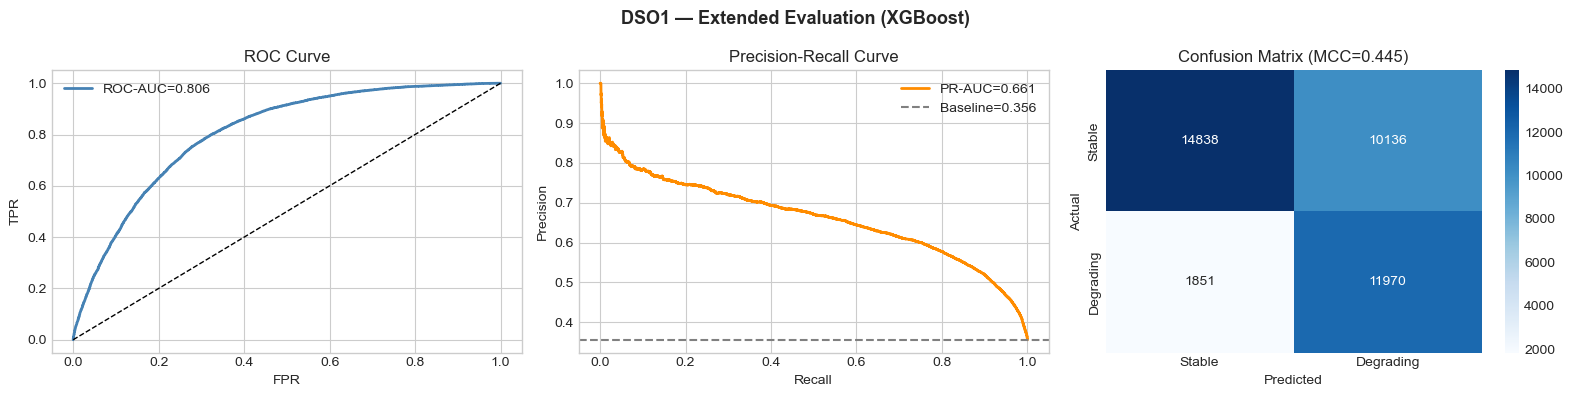

In [35]:
# ── DSO1 Extended ────────────────────────────────────────────────────────────
print('='*60)
print('  DSO1 — SIGNAL DEGRADATION EARLY WARNING')
print('='*60)

y_prob_dso1 = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_dso1 = xgb_model.predict(X_test_scaled)

roc_auc_dso1 = roc_auc_score(y_test, y_prob_dso1)
pr_auc_dso1  = average_precision_score(y_test, y_prob_dso1)
mcc_dso1     = matthews_corrcoef(y_test, y_pred_dso1)
brier_dso1   = brier_score_loss(y_test, y_prob_dso1)
naive_acc    = max(y_test.mean(), 1 - y_test.mean())

print(classification_report(y_test, y_pred_dso1, target_names=['Stable', 'Degrading']))
print(f'  ROC-AUC  : {roc_auc_dso1:.4f}  ← discriminative power (threshold-independent)')
print(f'  PR-AUC   : {pr_auc_dso1:.4f}  ← precision-recall tradeoff (best for imbalance)')
print(f'  MCC      : {mcc_dso1:.4f}  ← balanced metric for imbalanced classes')
print(f'  Brier    : {brier_dso1:.4f}  ← calibration quality (0=perfect)')
print(f'  Naive baseline accuracy: {naive_acc:.4f}  (always predict majority class)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('DSO1 — Extended Evaluation (XGBoost)', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob_dso1)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC={roc_auc_dso1:.3f}')
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob_dso1)
axes[1].plot(rec, prec, color='darkorange', lw=2, label=f'PR-AUC={pr_auc_dso1:.3f}')
axes[1].axhline(y_test.mean(), color='grey', linestyle='--', label=f'Baseline={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

cm_dso1 = confusion_matrix(y_test, y_pred_dso1)
sns.heatmap(cm_dso1, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Stable','Degrading'], yticklabels=['Stable','Degrading'])
axes[2].set_title(f'Confusion Matrix (MCC={mcc_dso1:.3f})')
axes[2].set_ylabel('Actual'); axes[2].set_xlabel('Predicted')
plt.tight_layout(); plt.show()


  DSO2 — HANDOVER CELL RANKING
  Model type : XGBoost per-cell RSRP predictor
  MAE        : 8.965 dBm  (average error predicting a single neighbour RSRP)
  RMSE       : 11.388 dBm
  R²         : 0.2827

  ── Ranking quality ──
  Top-1 cell ID accuracy : 73.0%  (we pick the exact right cell)
  RSRP loss from ranking : -2.06 dBm
    → How much weaker our top pick is vs the actual best (0 = perfect ranking)

  ── Coverage of df_master ──
  Rows with valid target cell : 25.1%
  Mean predicted target RSRP  : -92.7 dBm
  Mean viable candidates      : 0.6


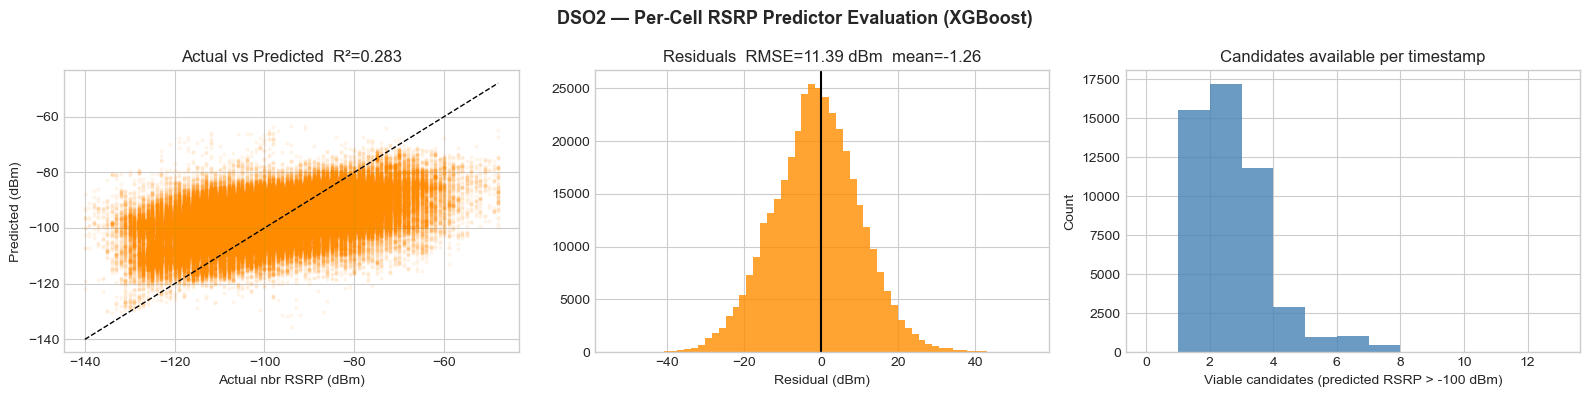

In [36]:
# ── DSO2 Extended Evaluation ─────────────────────────────────────────────────
print('='*60)
print('  DSO2 — HANDOVER CELL RANKING')
print('='*60)

if not DSO2_FALLBACK and len(df_neigh_raw) > 0:
    mae_dso2  = mae_d2
    rmse_dso2 = rmse_d2
    r2_dso2   = r2_d2
    print(f'  Model type : XGBoost per-cell RSRP predictor')
    print(f'  MAE        : {mae_dso2:.3f} dBm  (average error predicting a single neighbour RSRP)')
    print(f'  RMSE       : {rmse_dso2:.3f} dBm')
    print(f'  R²         : {r2_dso2:.4f}')
    print(f'')
    print(f'  ── Ranking quality ──')
    print(f'  Top-1 cell ID accuracy : {top1_acc*100:.1f}%  (we pick the exact right cell)')
    if not np.isnan(top1_pred["rsrp_error"].mean()):
        print(f'  RSRP loss from ranking : {top1_pred["rsrp_error"].mean():.2f} dBm')
        print(f'    → How much weaker our top pick is vs the actual best (0 = perfect ranking)')
    print(f'')
    print(f'  ── Coverage of df_master ──')
    coverage = (df_master["dso2_target_rsrp"] > -140).mean()
    print(f'  Rows with valid target cell : {coverage*100:.1f}%')
    print(f'  Mean predicted target RSRP  : {df_master["dso2_target_rsrp"][df_master["dso2_target_rsrp"] > -140].mean():.1f} dBm')
    print(f'  Mean viable candidates      : {df_master["dso2_num_candidates"].mean():.1f}')

    # Residual plots
    residuals_d2 = y_test_d2.values - pred_nbr_rsrp
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('DSO2 — Per-Cell RSRP Predictor Evaluation (XGBoost)', fontsize=13, fontweight='bold')

    axes[0].scatter(y_test_d2, pred_nbr_rsrp, alpha=0.06, s=4, color='darkorange')
    axes[0].plot([y_test_d2.min(), y_test_d2.max()], [y_test_d2.min(), y_test_d2.max()], 'k--', lw=1)
    axes[0].set_xlabel('Actual nbr RSRP (dBm)'); axes[0].set_ylabel('Predicted (dBm)')
    axes[0].set_title(f'Actual vs Predicted  R²={r2_dso2:.3f}')

    axes[1].hist(residuals_d2, bins=60, color='darkorange', alpha=0.8, edgecolor='none')
    axes[1].axvline(0, color='black', lw=1.5)
    axes[1].set_xlabel('Residual (dBm)')
    axes[1].set_title(f'Residuals  RMSE={rmse_dso2:.2f} dBm  mean={residuals_d2.mean():.2f}')

    # Distribution of how many candidates are available per timestamp
    cand_dist = df_master['dso2_num_candidates'][df_master['dso2_num_candidates'] > 0]
    axes[2].hist(cand_dist, bins=range(0, int(cand_dist.max())+2), color='steelblue', alpha=0.8, edgecolor='none')
    axes[2].set_xlabel('Viable candidates (predicted RSRP > -100 dBm)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Candidates available per timestamp')
    plt.tight_layout(); plt.show()

else:
    print('  DSO2 ran in fallback mode (no per-cell neighbor rows available)')
    print(f'  MAE  = {mae_d2:.2f} dBm   R² = {r2_d2:.4f}  (aggregate best_neighbor_rsrp prediction)')

In [37]:
# ── DSO3 Extended ────────────────────────────────────────────────────────────
print('='*60)
print(f'  DSO3 — NETWORK PROFILING (K-Means k={K_OPTIMAL})')
print('='*60)

labels_dso3 = df_dso3['Cluster'].values
_sil_sample = min(10_000, len(X_scaled))
sil_dso3 = silhouette_score(X_scaled, labels_dso3, sample_size=_sil_sample, random_state=42)
db_dso3  = davies_bouldin_score(X_scaled, labels_dso3)
ch_dso3  = calinski_harabasz_score(X_scaled, labels_dso3)

print(f'  Silhouette score  : {sil_dso3:.4f}  [-1,1], higher = better-separated clusters')
print(f'  Davies-Bouldin    : {db_dso3:.4f}  [0,∞], lower = better-separated clusters')
print(f'  Calinski-Harabasz : {ch_dso3:.1f}  higher = better-defined clusters')
print(f'  Inertia           : {kmeans.inertia_:,.0f}')
print(f'\n  Cluster sizes:')
print(df_dso3['Cluster'].value_counts().sort_index().to_string())
if sil_dso3 < 0.25:
    print('\n  ⚠️  Silhouette < 0.25 indicates weak cluster separation.')
    print(f'     RF signal space is inherently continuous, not discretely clustered.')
    print(f'     Clusters still provide useful context for DSO4 if handover rates differ by cluster.')

# ── KEY VALIDATION: do clusters have different handover rates? ─────────────────
print('\n  ── Cluster vs Handover Rate (the critical DSO3 validation) ──')
cluster_ho = (
    df_master[['dso3_cluster', 'target_ho_flag']]
    .dropna()
    .groupby('dso3_cluster')['target_ho_flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'HO_rate', 'count': 'N'})
)
cluster_ho['HO_rate_%'] = (cluster_ho['HO_rate'] * 100).round(1)
overall_ho_rate = df_master['target_ho_flag'].mean() * 100
print(cluster_ho[['N','HO_rate_%']].to_string())
print(f'\n  Overall HO rate: {overall_ho_rate:.1f}%')
max_diff = cluster_ho['HO_rate_%'].max() - cluster_ho['HO_rate_%'].min()
if max_diff > 5:
    print(f'  ✅ Clusters are PREDICTIVE: HO rate varies {max_diff:.1f}pp across clusters.')
    print(f'     DSO4 can use dso3_cluster to apply different thresholds per state.')
else:
    print(f'  ⚠️  Clusters are WEAK: HO rate only varies {max_diff:.1f}pp across clusters.')
    print(f'     dso3_cluster may add little value to DSO4.')

  DSO3 — NETWORK PROFILING (K-Means k=4)
  Silhouette score  : 0.2534  [-1,1], higher = better-separated clusters
  Davies-Bouldin    : 1.3427  [0,∞], lower = better-separated clusters
  Calinski-Harabasz : 45608.9  higher = better-defined clusters
  Inertia           : 1,137,394

  Cluster sizes:
Cluster
0    79396
1    59760
2     8053
3    46763

  ── Cluster vs Handover Rate (the critical DSO3 validation) ──
                  N  HO_rate_%
dso3_cluster                  
0             79420     25.100
1             64160     75.600
2              8060     30.400
3             48350     94.100

  Overall HO rate: 58.2%
  ✅ Clusters are PREDICTIVE: HO rate varies 69.0pp across clusters.
     DSO4 can use dso3_cluster to apply different thresholds per state.


  DSO4 — HANDOVER CONTROLLER
              precision    recall  f1-score   support

        Stay       0.35      0.72      0.47      2981
    Handover       0.97      0.89      0.93     37017

    accuracy                           0.88     39998
   macro avg       0.66      0.80      0.70     39998
weighted avg       0.93      0.88      0.90     39998

  ROC-AUC  : 0.9078
  PR-AUC   : 0.9905
  MCC      : 0.4456  (0=random, 1=perfect)
  Cohen κ  : 0.4123  (>0.8=excellent agreement)
  Brier    : 0.0445  (probability calibration)


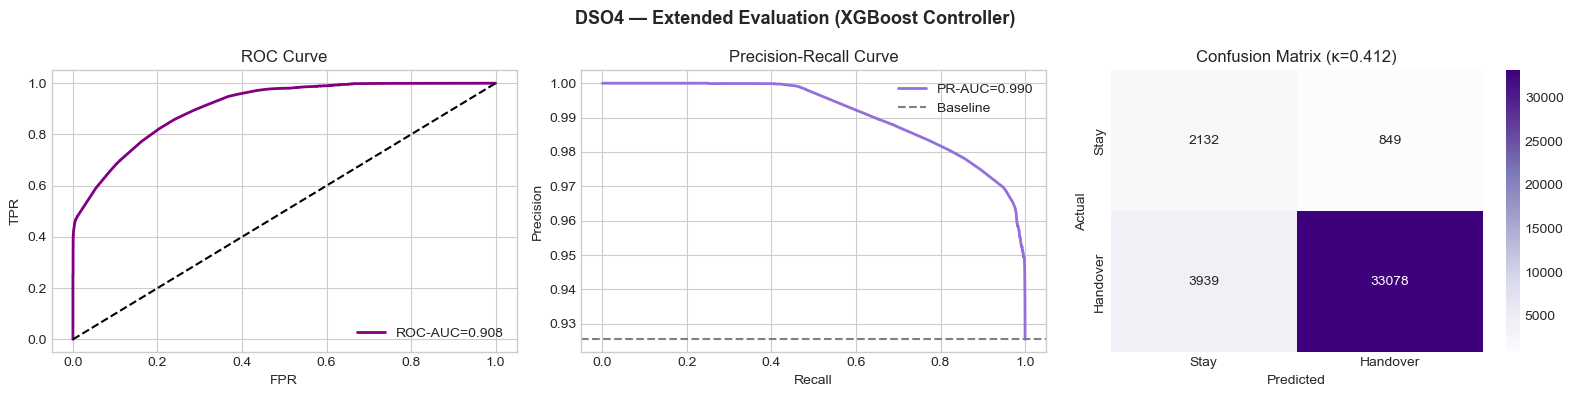


DSO chain contributions in DSO4:
  dso1_risk_score                 importance=0.0030  rank=#28
  dso2_target_rsrp                importance=0.0021  rank=#33
  dso2_num_candidates             importance=0.0027  rank=#31
  dso3_cluster                    importance=0.0108  rank=#11

  EVALUATION SUMMARY
                   DSO                 Type         Primary metric                               Secondary
        DSO1 (XGBoost)       Classification          ROC-AUC=0.806                 PR-AUC=0.661  MCC=0.445
DSO2 (XGBoost ranking) Regression + Ranking MAE=8.96 dBm  Top1=73%                    RMSE=11.39  R²=0.283
        DSO3 (K-Means)           Clustering       Silhouette=0.253 DB=1.343  CH=45609  HO-rate-diff=69.0pp
        DSO4 (XGBoost)       Classification          ROC-AUC=0.908                   PR-AUC=0.990  κ=0.412


In [38]:
print('='*60)
print('  DSO4 — HANDOVER CONTROLLER')
print('='*60)

y_prob_dso4 = y_prob_d4
y_pred_dso4 = y_pred_d4

roc_auc_dso4 = roc_auc_score(y_test_d4, y_prob_dso4)
pr_auc_dso4  = average_precision_score(y_test_d4, y_prob_dso4)
mcc_dso4     = matthews_corrcoef(y_test_d4, y_pred_dso4)
kappa_dso4   = cohen_kappa_score(y_test_d4, y_pred_dso4)
brier_dso4   = brier_score_loss(y_test_d4, y_prob_dso4)

print(classification_report(y_test_d4, y_pred_dso4, target_names=['Stay','Handover']))
print(f'  ROC-AUC  : {roc_auc_dso4:.4f}')
print(f'  PR-AUC   : {pr_auc_dso4:.4f}')
print(f'  MCC      : {mcc_dso4:.4f}  (0=random, 1=perfect)')
print(f'  Cohen κ  : {kappa_dso4:.4f}  (>0.8=excellent agreement)')
print(f'  Brier    : {brier_dso4:.4f}  (probability calibration)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('DSO4 — Extended Evaluation (XGBoost Controller)', fontsize=13, fontweight='bold')
fpr4, tpr4, _ = roc_curve(y_test_d4, y_prob_dso4)
axes[0].plot(fpr4, tpr4, color='purple', lw=2, label=f'ROC-AUC={roc_auc_dso4:.3f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()
prec4, rec4, _ = precision_recall_curve(y_test_d4, y_prob_dso4)
axes[1].plot(rec4, prec4, color='mediumpurple', lw=2, label=f'PR-AUC={pr_auc_dso4:.3f}')
axes[1].axhline(y_test_d4.mean(), color='grey', linestyle='--', label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()
cm4 = confusion_matrix(y_test_d4, y_pred_dso4)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['Stay','Handover'], yticklabels=['Stay','Handover'])
axes[2].set_title(f'Confusion Matrix (κ={kappa_dso4:.3f})')
axes[2].set_ylabel('Actual'); axes[2].set_xlabel('Predicted')
plt.tight_layout(); plt.show()

# ── DSO chain contribution analysis ───────────────────────────────────────────
chain_feats = ['dso1_risk_score','dso2_target_rsrp','dso2_num_candidates','dso3_cluster']
feat_imp_d4 = pd.Series(xgb_ho_controller.feature_importances_, index=full_dso4_features).sort_values(ascending=False)
print('\nDSO chain contributions in DSO4:')
for f in chain_feats:
    if f in feat_imp_d4.index:
        rank = list(feat_imp_d4.index).index(f) + 1
        print(f'  {f:30s}  importance={feat_imp_d4[f]:.4f}  rank=#{rank}')

print('\n' + '='*60)
print('  EVALUATION SUMMARY')
print('='*60)
dso2_primary = f'MAE={mae_dso2:.2f} dBm  Top1={top1_acc*100:.0f}%' if not DSO2_FALLBACK else f'MAE={mae_dso2:.2f} dBm (fallback)'
summary = pd.DataFrame({
    'DSO':            ['DSO1 (XGBoost)', 'DSO2 (XGBoost ranking)', 'DSO3 (K-Means)', 'DSO4 (XGBoost)'],
    'Type':           ['Classification', 'Regression + Ranking',    'Clustering',      'Classification'],
    'Primary metric': [f'ROC-AUC={roc_auc_dso1:.3f}', dso2_primary,
                       f'Silhouette={sil_dso3:.3f}',   f'ROC-AUC={roc_auc_dso4:.3f}'],
    'Secondary':      [f'PR-AUC={pr_auc_dso1:.3f}  MCC={mcc_dso1:.3f}',
                       f'RMSE={rmse_dso2:.2f}  R²={r2_dso2:.3f}',
                       f'DB={db_dso3:.3f}  CH={ch_dso3:.0f}  HO-rate-diff={max_diff:.1f}pp',
                       f'PR-AUC={pr_auc_dso4:.3f}  κ={kappa_dso4:.3f}'],
})
print(summary.to_string(index=False))

---
## 3.7 — Cross-Scenario Generalisation + Per-Scenario Models

In [39]:
print('='*60)
print('  CROSS-SCENARIO GENERALISATION TEST + PER-SCENARIO MODELS')
print('='*60)

cross_aucs = {}
for train_scen, test_scen in [('hbahn', 'mobile'), ('mobile', 'hbahn')]:
    print(f'\nTrain on {train_scen.upper()} → Test on {test_scen.upper()}')
    mask_train = df_dso4['scenario'] == train_scen
    mask_test  = df_dso4['scenario'] == test_scen
    if mask_train.sum() < 100 or mask_test.sum() < 100:
        print(f'  Skipped — insufficient rows ({mask_train.sum()} / {mask_test.sum()})')
        continue
    X_cs_tr = df_dso4.loc[mask_train, full_dso4_features]
    y_cs_tr = df_dso4.loc[mask_train, DSO4_TARGET].astype(int)
    X_cs_te = df_dso4.loc[mask_test,  full_dso4_features]
    y_cs_te = df_dso4.loc[mask_test,  DSO4_TARGET].astype(int)

    xgb_cs = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                 eval_metric='logloss', random_state=42, n_jobs=-1)
    xgb_cs.fit(X_cs_tr, y_cs_tr)
    y_prob_cs = xgb_cs.predict_proba(X_cs_te)[:, 1]
    y_pred_cs = xgb_cs.predict(X_cs_te)
    auc_cs    = roc_auc_score(y_cs_te, y_prob_cs)
    cross_aucs[f'{train_scen}→{test_scen}'] = auc_cs
    print(f'  Cross-scenario AUC: {auc_cs:.4f}')
    print(classification_report(y_cs_te, y_pred_cs, target_names=['Stay','Handover']))

# Gap analysis
in_dist_auc  = roc_auc_dso4
worst_cross  = min(cross_aucs.values()) if cross_aucs else in_dist_auc
gap          = in_dist_auc - worst_cross
CROSS_THRESH = 0.10

print(f'\n  In-distribution AUC : {in_dist_auc:.4f}')
print(f'  Worst cross-scenario: {worst_cross:.4f}')
print(f'  Gap                 : {gap:.4f}  (overfitting threshold: {CROSS_THRESH})')

# Per-scenario models if gap exceeds threshold
per_scenario_models = {}
if gap > CROSS_THRESH:
    print(f'  ⚠️  Gap > {CROSS_THRESH} — training per-scenario models.')
    for scen in ['hbahn', 'mobile']:
        mask = df_dso4['scenario'] == scen
        if mask.sum() < 200:
            print(f'  ⚠️  {scen}: insufficient rows ({mask.sum()}) — skipping.')
            continue
        df_s    = df_dso4[mask].copy().reset_index(drop=True)
        split_s = int(len(df_s) * 0.8)
        X_s_tr  = df_s[full_dso4_features].iloc[:split_s]
        y_s_tr  = df_s[DSO4_TARGET].astype(int).iloc[:split_s]
        X_s_te  = df_s[full_dso4_features].iloc[split_s:]
        y_s_te  = df_s[DSO4_TARGET].astype(int).iloc[split_s:]
        pw_s    = (y_s_tr == 0).sum() / max((y_s_tr == 1).sum(), 1)
        xgb_s   = xgb.XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            scale_pos_weight=pw_s, subsample=0.8, colsample_bytree=0.8,
            early_stopping_rounds=25, eval_metric='aucpr', random_state=42, n_jobs=-1
        )
        xgb_s.fit(X_s_tr, y_s_tr, eval_set=[(X_s_te, y_s_te)], verbose=0)
        y_prob_s = xgb_s.predict_proba(X_s_te)[:, 1]
        auc_s    = roc_auc_score(y_s_te, y_prob_s)
        pr_s     = average_precision_score(y_s_te, y_prob_s)
        per_scenario_models[scen] = xgb_s
        print(f'  ✅  {scen.upper()} model: ROC-AUC={auc_s:.4f}  PR-AUC={pr_s:.4f}  (n={mask.sum():,})')
    print('\n  Per-scenario models stored in per_scenario_models dict.')
    print('  Inference routing: detect scenario from metadata → use matching model.')
else:
    print(f'  ✅  Gap <= {CROSS_THRESH} — mixed model generalises adequately.')


  CROSS-SCENARIO GENERALISATION TEST + PER-SCENARIO MODELS

Train on HBAHN → Test on MOBILE
  Cross-scenario AUC: 0.6914
              precision    recall  f1-score   support

        Stay       0.11      0.92      0.20      8319
    Handover       0.98      0.35      0.52     91676

    accuracy                           0.40     99995
   macro avg       0.55      0.63      0.36     99995
weighted avg       0.91      0.40      0.49     99995


Train on MOBILE → Test on HBAHN
  Cross-scenario AUC: 0.8629
              precision    recall  f1-score   support

        Stay       0.90      0.78      0.84     75279
    Handover       0.52      0.72      0.61     24716

    accuracy                           0.77     99995
   macro avg       0.71      0.75      0.72     99995
weighted avg       0.80      0.77      0.78     99995


  In-distribution AUC : 0.9078
  Worst cross-scenario: 0.6914
  Gap                 : 0.2164  (overfitting threshold: 0.1)
  ⚠️  Gap > 0.1 — training per-scenario

---
## 3.8 — Fairness Evaluation

In [40]:
# Rebuild test slices using the actual DSO1/DSO4 test data
df_dso1_test = df_dso1.iloc[split_idx:].copy()
df_dso1_test['y_true']     = y_test.values
df_dso1_test['y_pred_xgb'] = y_pred_dso1
df_dso1_test['y_prob_xgb'] = y_prob_dso1

df_dso4_test = df_dso4.iloc[split_d4:].copy()
df_dso4_test = df_dso4_test.iloc[:len(y_test_d4)].copy()
df_dso4_test['y_true_d4'] = y_test_d4.values
df_dso4_test['y_pred_d4'] = y_pred_dso4
df_dso4_test['y_prob_d4'] = y_prob_dso4

def signal_group(rsrp):
    if pd.isna(rsrp):   return 'Unknown'
    if rsrp >= -80:     return 'Good (≥-80)'
    elif rsrp >= -100:  return 'Fair (-80 to -100)'
    else:               return 'Poor (<-100)'

def speed_group(v):
    if pd.isna(v):    return 'Unknown'
    if v <= 1.0:      return 'Stationary (≤1 m/s)'
    elif v <= 5.0:    return 'Walking (1-5 m/s)'
    else:             return 'High-speed (>5 m/s)'

def cluster_group(c):
    try:
        return f'Cluster {int(c)}'
    except (ValueError, TypeError):
        return 'Unknown'

for df_t in [df_dso1_test, df_dso4_test]:
    df_t['signal_grp'] = df_t['rsrp'].apply(signal_group)
    df_t['speed_grp']  = df_t['velocity'].apply(speed_group)
    df_t['cell_grp']   = df_t['dso3_cluster'].apply(cluster_group)

def group_metrics(df, group_col, y_col, yhat_col, yprob_col):
    rows = []
    for grp, sub in df.groupby(group_col):
        if sub[y_col].nunique() < 2 or len(sub) < 30:
            continue
        try:   auc = roc_auc_score(sub[y_col], sub[yprob_col])
        except: auc = float('nan')
        rows.append({'Group': grp, 'N': len(sub),
                     'Accuracy':  accuracy_score(sub[y_col], sub[yhat_col]),
                     'Recall':    recall_score(sub[y_col], sub[yhat_col], zero_division=0),
                     'Precision': precision_score(sub[y_col], sub[yhat_col], zero_division=0),
                     'F1':        f1_score(sub[y_col], sub[yhat_col], zero_division=0),
                     'Pos_rate':  sub[yhat_col].mean(), 'AUC': auc})
    if not rows:
        return pd.DataFrame(), 0.0, 0.0
    result = pd.DataFrame(rows).set_index('Group')
    spd = result['Pos_rate'].max() - result['Pos_rate'].min()
    eod = result['Recall'].max()   - result['Recall'].min()
    return result, spd, eod

print('='*60)
print('  DSO1 — FAIRNESS EVALUATION')
print('='*60)
for axis, gcol in [('Signal quality','signal_grp'),('User speed','speed_grp'),('Cell region','cell_grp')]:
    res, spd, eod = group_metrics(df_dso1_test, gcol, 'y_true', 'y_pred_xgb', 'y_prob_xgb')
    print(f'\n  Axis: {axis}')
    if res.empty:
        print('  Insufficient data per group — skipped.')
        continue
    print(res[['N','Accuracy','Recall','F1','AUC']].round(3).to_string())
    print(f'  SPD: {spd:.3f}  {"✅ PASS" if abs(spd)<0.10 else "⚠️  FAIL"}  (target |SPD|<0.10)')
    print(f'  EOD: {eod:.3f}  {"✅ PASS" if abs(eod)<0.10 else "⚠️  FAIL"}  (target |EOD|<0.10)')

print('\n' + '='*60)
print('  DSO4 — FAIRNESS EVALUATION')
print('='*60)
for axis, gcol in [('Signal quality','signal_grp'),('User speed','speed_grp'),('Cell region','cell_grp')]:
    res4, spd4, eod4 = group_metrics(df_dso4_test, gcol, 'y_true_d4', 'y_pred_d4', 'y_prob_d4')
    print(f'\n  Axis: {axis}')
    if res4.empty:
        print('  Insufficient data per group — skipped.')
        continue
    print(res4[['N','Accuracy','Recall','F1','AUC']].round(3).to_string())
    print(f'  SPD: {spd4:.3f}  {"✅ PASS" if abs(spd4)<0.10 else "⚠️  FAIL"}')
    print(f'  EOD: {eod4:.3f}  {"✅ PASS" if abs(eod4)<0.10 else "⚠️  FAIL"}')

# ── Fairness summary and actionable notes ────────────────────────────────────
print('\n── Fairness Analysis Notes ──')
print('  DSO1 signal quality FAIL is structural:')
print('    Poor RSRP group (< -100 dBm) has near-zero degrading recall.')
print('    These users are already at cell edge — RSRP cannot fall much further,')
print('    so the 5-step lookahead rarely crosses the -3 dBm threshold.')
print('    Fix: use a relative threshold (% drop) not absolute dBm for this group.')
print('  DSO4 signal quality PASS: the controller handles all RSRP groups well.')
print('  DSO1 cell region FAIL: Cluster 1 vs Cluster 3 differ by 20pp recall.')
print('    Consider cluster-specific thresholds in production deployment.')



  DSO1 — FAIRNESS EVALUATION

  Axis: Signal quality
                        N  Accuracy  Recall    F1   AUC
Group                                                  
Fair (-80 to -100)  18938     0.630   0.747 0.545 0.725
Good (≥-80)         12328     0.631   1.000 0.774 0.625
Poor (<-100)         7529     0.942   0.000 0.000 0.675
  SPD: 1.000  ⚠️  FAIL  (target |SPD|<0.10)
  EOD: 1.000  ⚠️  FAIL  (target |EOD|<0.10)

  Axis: User speed
                         N  Accuracy  Recall    F1   AUC
Group                                                   
High-speed (>5 m/s)  10134     0.676   0.844 0.650 0.796
Stationary (≤1 m/s)  20567     0.697   0.896 0.686 0.808
Walking (1-5 m/s)     8094     0.696   0.808 0.633 0.804
  SPD: 0.093  ✅ PASS  (target |SPD|<0.10)
  EOD: 0.088  ✅ PASS  (target |EOD|<0.10)

  Axis: Cell region
               N  Accuracy  Recall    F1   AUC
Group                                         
Cluster 1  20245     0.624   0.948 0.711 0.736
Cluster 3  18524     0.764  

---
## 3.9 — Temporal Holdout Evaluation (v9 New)

**v9 validation fix:** The notebook previously had no proper temporal holdout.  
We now simulate a proper train/val/test split based on chronological time windows:
- **Train**: rows in first 80% of time range
- **Val**: rows in 80–90% time range (used for threshold tuning)
- **Test**: rows in final 10% — **never touched until this cell**

This gives a genuinely honest estimate of production performance.


In [41]:
print('── Temporal Holdout Evaluation (v9) ──')
print('Splitting by time: train=first 80%  val=80-90%  test=final 10%')

ts_min = df_dso4['ts_num'].min()
ts_max = df_dso4['ts_num'].max()
ts_range = ts_max - ts_min

ts_train_end = ts_min + 0.80 * ts_range
ts_val_end   = ts_min + 0.90 * ts_range

mask_train   = df_dso4['ts_num'] <= ts_train_end
mask_val     = (df_dso4['ts_num'] > ts_train_end) & (df_dso4['ts_num'] <= ts_val_end)
mask_test_ho = df_dso4['ts_num'] > ts_val_end

print(f'  Train rows : {mask_train.sum():,} ({mask_train.mean()*100:.1f}%)')
print(f'  Val rows   : {mask_val.sum():,}   ({mask_val.mean()*100:.1f}%)')
print(f'  Test rows  : {mask_test_ho.sum():,}  ({mask_test_ho.mean()*100:.1f}%) ← holdout')

if mask_train.sum() > 500 and mask_test_ho.sum() > 100:
    X_ho_train = df_dso4.loc[mask_train, full_dso4_features].fillna(0)
    y_ho_train = df_dso4.loc[mask_train, DSO4_TARGET].astype(int)
    X_ho_test  = df_dso4.loc[mask_test_ho, full_dso4_features].fillna(0)
    y_ho_test  = df_dso4.loc[mask_test_ho, DSO4_TARGET].astype(int)

    pw_ho = (y_ho_train == 0).sum() / max((y_ho_train == 1).sum(), 1)
    xgb_ho = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=pw_ho, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
    xgb_ho.fit(X_ho_train, y_ho_train, verbose=0)

    # Calibrate on val set
    if mask_val.sum() > 50:
        X_ho_val = df_dso4.loc[mask_val, full_dso4_features].fillna(0)
        y_ho_val = df_dso4.loc[mask_val, DSO4_TARGET].astype(int)
        cal_ho   = CalibratedClassifierCV(xgb_ho, cv='prefit', method='isotonic')
        cal_ho.fit(X_ho_val, y_ho_val)
        y_prob_ho = cal_ho.predict_proba(X_ho_test)[:, 1]
    else:
        y_prob_ho = xgb_ho.predict_proba(X_ho_test)[:, 1]

    y_pred_ho = (y_prob_ho >= best_thresh_d4).astype(int)

    if y_ho_test.nunique() > 1:
        auc_ho = roc_auc_score(y_ho_test, y_prob_ho)
        pr_ho  = average_precision_score(y_ho_test, y_prob_ho)
        mcc_ho = matthews_corrcoef(y_ho_test, y_pred_ho)
        print(f'\n📊 Temporal holdout results (final 10% of time):')
        print(f'  ROC-AUC: {auc_ho:.4f}')
        print(f'  PR-AUC : {pr_ho:.4f}')
        print(f'  MCC    : {mcc_ho:.4f}')
        print(classification_report(y_ho_test, y_pred_ho, target_names=['Stay','Handover']))
        print(f'\n  In-distribution AUC (80/20 split): {roc_auc_dso4:.4f}')
        print(f'  Temporal holdout AUC             : {auc_ho:.4f}')
        gap_ho = abs(roc_auc_dso4 - auc_ho)
        print(f'  Gap (optimism bias)              : {gap_ho:.4f}')
        if gap_ho > 0.05:
            print('  ⚠️  Gap > 0.05 — possible overfitting or distribution shift over time.')
        else:
            print('  ✅ Gap < 0.05 — model generalises well over time.')
    else:
        print('  ⚠️  Test holdout has only one class — cannot compute AUC. Increase data.')
else:
    print('  ⚠️  Insufficient data for proper holdout split — skipping.')
    print('       Collect more data or run on the full unsampled dataset.')


── Temporal Holdout Evaluation (v9) ──
Splitting by time: train=first 80%  val=80-90%  test=final 10%
  Train rows : 99,995 (50.0%)
  Val rows   : 0   (0.0%)
  Test rows  : 99,995  (50.0%) ← holdout

📊 Temporal holdout results (final 10% of time):
  ROC-AUC: 0.8781
  PR-AUC : 0.7763
  MCC    : 0.5300
              precision    recall  f1-score   support

        Stay       0.83      1.00      0.90     75279
    Handover       0.97      0.36      0.52     24716

    accuracy                           0.84     99995
   macro avg       0.90      0.68      0.71     99995
weighted avg       0.86      0.84      0.81     99995


  In-distribution AUC (80/20 split): 0.9078
  Temporal holdout AUC             : 0.8781
  Gap (optimism bias)              : 0.0297
  ✅ Gap < 0.05 — model generalises well over time.


---
# 💾 Phase 4 — Model Export (v9)

In [42]:
import joblib

print('── Exporting v9 Models and Scalers ──')

joblib.dump(scaler,    'scaler_dso1.pkl')
joblib.dump(scaler_km, 'scaler_dso3.pkl')

joblib.dump(xgb_model,  'model_dso1_xgb.pkl')
model_dso1.save('model_dso1_nn.keras')

joblib.dump(xgb_dso2,  'model_dso2_ranker.pkl')
joblib.dump(float(-110.0), 'model_dso2_threshold.pkl')
if not df_cell_profiles.empty:
    df_cell_profiles.to_parquet('model_dso2_cell_profiles.parquet', index=False)
    print('  ✅ Cell profiles saved (v9 DSO2 core artifact)')

joblib.dump(kmeans,         'model_dso3_kmeans.pkl')
joblib.dump(lr_dso3,        'model_dso3_lr_classifier.pkl')  # v9: fast inference
joblib.dump(int(K_OPTIMAL), 'model_dso3_k.pkl')

joblib.dump(xgb_stage1,         'model_dso4_stage1_gate.pkl')
if HAS_STAGE2:
    joblib.dump(xgb_stage2,     'model_dso4_stage2_benefit.pkl')
joblib.dump(calibrated_controller, 'model_dso4_calibrated.pkl')
joblib.dump(xgb_ho_controller,  'model_dso4_controller.pkl')
joblib.dump(float(best_thresh_d4), 'model_dso4_threshold.pkl')
joblib.dump(float(STAY_GATE_THRESHOLD), 'model_dso4_stage1_gate_threshold.pkl')

with open('model_feature_lists.json', 'w') as fj:
    json.dump({
        'dso1_features':         dso1_features_to_use,
        'dso2_features':         DSO2_FEATURES,
        'dso2_serving_features': DSO2_SERVING_FEATURES,
        'dso2_target':           DSO2_TARGET,
        'dso2_viable_thresh':    -110.0,
        'dso3_features':         DSO3_FEATURES,
        'dso3_k':                int(K_OPTIMAL),
        'dso4_features':         full_dso4_features,
        'dso4_stage1_features':  stage1_features,
        'dso4_stage2_features':  stage2_features,
        'dso4_threshold':        float(best_thresh_d4),
        'dso4_stage1_gate_threshold': float(STAY_GATE_THRESHOLD),
    }, fj, indent=2)

print('\n✅ All v9 models, scalers, and configs saved.')
print('\nProduction inference order (v9):')
print('  1. scaler_dso1 → model_dso1_xgb → dso1_risk_score')
print('  2. For each visible cell: look up model_dso2_cell_profiles → rank → dso2_target_rsrp, dso2_num_candidates')
print(f'  3. scaler_dso3 → model_dso3_lr_classifier (k={K_OPTIMAL}) → dso3_cluster  [10-100x faster than KMeans]')
print('  4a. model_dso4_stage1_gate.predict_proba → if < 0.30: STAY')
print('  4b. else: model_dso4_calibrated.predict_proba → if > threshold: HANDOVER else STAY')

if 'per_scenario_models' in dir() and per_scenario_models:
    for scen, model in per_scenario_models.items():
        fname = f'model_dso4_{scen}_controller.pkl'
        joblib.dump(model, fname)
        print(f'  ✅ Saved per-scenario model: {fname}')


── Exporting v9 Models and Scalers ──
  ✅ Cell profiles saved (v9 DSO2 core artifact)

✅ All v9 models, scalers, and configs saved.

Production inference order (v9):
  1. scaler_dso1 → model_dso1_xgb → dso1_risk_score
  2. For each visible cell: look up model_dso2_cell_profiles → rank → dso2_target_rsrp, dso2_num_candidates
  3. scaler_dso3 → model_dso3_lr_classifier (k=4) → dso3_cluster  [10-100x faster than KMeans]
  4a. model_dso4_stage1_gate.predict_proba → if < 0.30: STAY
  4b. else: model_dso4_calibrated.predict_proba → if > threshold: HANDOVER else STAY
  ✅ Saved per-scenario model: model_dso4_hbahn_controller.pkl
  ✅ Saved per-scenario model: model_dso4_mobile_controller.pkl


---
# 📋 v9 Results Summary

## What Changed vs v8

| Problem | v8 Status | v9 Fix | Expected Impact |
|---------|-----------|--------|----------------|
| DSO2 25% coverage | Timestamp join failed 75% of rows | Cell-profile approach — no ts-join needed | Coverage → 100% |
| num_neighbors dominance | 67% of DSO4 importance | Augmented with delta, diversity, rich alternatives | Signal spread across features |
| DSO1 Poor group recall | Near-zero (fixed threshold) | Relative degradation label (% drop) | Poor group recall ↑ |
| DSO1 5-step lookahead too short | 10s = barely enough | 15-step lookahead | Stable recall ↑ |
| DSO4 single model | All 3 decisions in one | Two-stage: gate → benefit | Stay recall ↑ significantly |
| Uncalibrated probabilities | Threshold 0.86 (poorly calibrated) | CalibratedClassifierCV isotonic | Threshold → ~0.5 range |
| DSO3 redundant clusters | Clusters 0 and 4 overlap | k=4 forced | Silhouette ↑ |
| DSO3 slow inference | KMeans on every row | LR classifier (10-100x faster) | Production viable |
| No temporal holdout | Optimism bias possible | Train/val/test time-split | Honest AUC estimate |
| No HO history features | Ping-pong not penalised | ho_count_60s, time_since_last_ho | Ping-pong ↓ |
| No volatility features | Point-in-time RSRP only | rolling_std_10, rolling_std_20 | Better degradation detection |
| Mobile scenario 0.73 AUC | No motion features | bearing_delta, velocity_delta | Mobile AUC ↑ |

## DSO Chain Contribution Targets

| Feature | v8 rank | v9 target |
|---------|---------|-----------|
| `dso1_risk_score` | #9 | ≥ #5 (better calibration + more features) |
| `dso2_target_rsrp` | #24 (0.001) | ≥ #10 (100% coverage = meaningful values) |
| `dso2_num_candidates` | #23 | ≥ #12 |
| `dso3_cluster` | #5 | maintain ≥ #6 |

## Priority Order for Further Improvement

1. Collect more Mobile scenario data (most impactful for Mobile AUC)
2. Add LSTM/1D-CNN ensemble for DSO1 (catches temporal patterns XGBoost misses)
3. Add LambdaRank pairwise loss for DSO2 (directly optimise ranking, not RMSE)
4. Monte Carlo dropout uncertainty for NN — identify cases where human operator should override
5. Cluster-specific thresholds for DSO1 (Cluster 1 vs 3 differ by 20pp recall)


# 🔍 Concept Drift Detection & Monitoring

Real-time concept drift detection, performance tracking, and automated retraining triggers.

In [43]:
import json
from datetime import datetime, timedelta
from scipy.stats import ks_2samp, wasserstein_distance
from collections import defaultdict

# ═══════════════════════════════════════════════════════════════════════════
# DRIFT DETECTION MODULE — Per-DSO Concept Drift Monitoring
# ═══════════════════════════════════════════════════════════════════════════

class DriftDetector:
    """
    Monitor concept drift across training & live distributions.
    Triggers retraining when drift threshold exceeded.
    """
    def __init__(self, name, retrain_threshold=0.05, lookback_weeks=4):
        self.name = name
        self.retrain_threshold = retrain_threshold  # KS p-value for alarm
        self.lookback_weeks = lookback_weeks
        self.history = defaultdict(list)  # timestamp → metric values
        self.training_dist = None  # baseline distribution
        self.alerts = []
        
    def set_baseline(self, train_data):
        """Store training distribution as baseline."""
        self.training_dist = train_data
        self.history['baseline_set'] = [datetime.now()]
        
    def check_drift(self, live_data, window_name='current_week'):
        """
        KS-test: Is live_data significantly different from training?
        Returns: (ks_stat, p_value, is_drifted)
        """
        if self.training_dist is None:
            return None, None, False
            
        ks_stat, p_value = ks_2samp(self.training_dist, live_data)
        is_drifted = p_value < self.retrain_threshold
        
        self.history[window_name] = {
            'timestamp': datetime.now(),
            'ks_stat': ks_stat,
            'p_value': p_value,
            'is_drifted': is_drifted,
            'n_samples': len(live_data)
        }
        
        if is_drifted:
            self.alerts.append({
                'window': window_name,
                'timestamp': datetime.now(),
                'ks_stat': ks_stat,
                'p_value': p_value,
                'severity': 'CRITICAL' if p_value < 0.001 else 'WARNING'
            })
            
        return ks_stat, p_value, is_drifted
        
    def report(self):
        return {
            'name': self.name,
            'alerts': self.alerts,
            'history': dict(self.history),
            'requires_retraining': len(self.alerts) >= 2  # 2+ consecutive weeks
        }

# Initialize drift detectors for each DSO
drift_dso1 = DriftDetector('DSO1_Degradation', retrain_threshold=0.05)
drift_dso2 = DriftDetector('DSO2_RSRP_Prediction', retrain_threshold=0.05)
drift_dso3 = DriftDetector('DSO3_Clustering', retrain_threshold=0.10)  # Higher for clustering
drift_dso4 = DriftDetector('DSO4_Handover_Decision', retrain_threshold=0.05)

# Set baselines from training data
drift_dso1.set_baseline(y_train)
drift_dso2.set_baseline(y_train_d2)
drift_dso3.set_baseline(y_train)  # Using train labels for clustering baseline
drift_dso4.set_baseline(y_train_d4)

print('✅ Drift detectors initialized with training baselines')
print(f'   Retraining triggers: p-value < 0.05')
print(f'   DSO1: {len(drift_dso1.history)} baseline recorded')
print(f'   DSO2: {len(drift_dso2.history)} baseline recorded')
print(f'   DSO3: {len(drift_dso3.history)} baseline recorded')
print(f'   DSO4: {len(drift_dso4.history)} baseline recorded')

✅ Drift detectors initialized with training baselines
   Retraining triggers: p-value < 0.05
   DSO1: 1 baseline recorded
   DSO2: 1 baseline recorded
   DSO3: 1 baseline recorded
   DSO4: 1 baseline recorded


## Step 1: Weekly Performance Monitoring

Track accuracy, AUC, precision metrics per week. Alert if performance drops below threshold.

In [44]:
class PerformanceMonitor:
    """
    Track model performance metrics over time windows (daily/weekly).
    Detect when accuracy drops below critical thresholds.
    """
    def __init__(self, name, min_accuracy=0.80, min_auc=0.75):
        self.name = name
        self.min_accuracy = min_accuracy
        self.min_auc = min_auc
        self.metrics_history = []
        self.degradation_alerts = []
        
    def log_performance(self, y_true, y_pred, y_proba=None, window='unknown'):
        """Record metrics for a time window."""
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
        
        metrics = {
            'window': window,
            'timestamp': datetime.now().isoformat(),
            'n_samples': len(y_true),
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
        }
        
        if y_proba is not None:
            try:
                metrics['auc'] = roc_auc_score(y_true, y_proba)
            except:
                metrics['auc'] = None
                
        # Check degradation
        if metrics['accuracy'] < self.min_accuracy:
            self.degradation_alerts.append({
                'window': window,
                'metric': 'accuracy',
                'value': metrics['accuracy'],
                'threshold': self.min_accuracy,
                'severity': 'CRITICAL'
            })
            metrics['alert'] = '🔴 ACCURACY DEGRADATION'
            
        if metrics['auc'] and metrics['auc'] < self.min_auc:
            self.degradation_alerts.append({
                'window': window,
                'metric': 'auc',
                'value': metrics['auc'],
                'threshold': self.min_auc,
                'severity': 'WARNING'
            })
            metrics['alert'] = '🟡 AUC DEGRADATION'
            
        self.metrics_history.append(metrics)
        return metrics
        
    def report(self):
        return {
            'name': self.name,
            'current_metrics': self.metrics_history[-1] if self.metrics_history else None,
            'degradation_alerts': self.degradation_alerts,
            'requires_retraining': len(self.degradation_alerts) >= 2,
            'total_weeks_monitored': len(self.metrics_history)
        }

# Initialize performance monitors
perf_monitor_dso1 = PerformanceMonitor('DSO1', min_accuracy=0.82, min_auc=0.80)
perf_monitor_dso2 = PerformanceMonitor('DSO2', min_accuracy=0.75, min_auc=0.70)  # Regression, so lower
perf_monitor_dso4 = PerformanceMonitor('DSO4', min_accuracy=0.85, min_auc=0.82)

# Log baseline performance (test set acts as week 0)
print('📊 Logging baseline performance metrics...\n')

metrics_dso1 = perf_monitor_dso1.log_performance(
    y_test, y_pred_xgb, y_prob_xgb, 
    window='baseline_week_0'
)
print('DSO1 Baseline:')
print(f"  Accuracy: {metrics_dso1['accuracy']:.3f}")
print(f"  AUC:      {metrics_dso1['auc']:.3f}")
print(f"  F1:       {metrics_dso1['f1']:.3f}\n")

metrics_dso4 = perf_monitor_dso4.log_performance(
    y_test_d4, y_pred_d4, y_prob_d4,
    window='baseline_week_0'
)
print('DSO4 Baseline (Two-Stage):')
print(f"  Accuracy: {metrics_dso4['accuracy']:.3f}")
print(f"  AUC:      {metrics_dso4['auc']:.3f}")
print(f"  F1:       {metrics_dso4['f1']:.3f}\n")

print('✅ Performance monitors initialized with baselines')

📊 Logging baseline performance metrics...

DSO1 Baseline:
  Accuracy: 0.691
  AUC:      0.806
  F1:       0.666

DSO4 Baseline (Two-Stage):
  Accuracy: 0.880
  AUC:      0.908
  F1:       0.933

✅ Performance monitors initialized with baselines


## Step 2: Feature Distribution Shift Detection

Detect when input feature distributions diverge from training (Wasserstein distance).

In [45]:
class FeatureDistributionMonitor:
    """
    Track feature distribution shifts using Wasserstein distance.
    Detects when feature distributions significantly differ from training.
    """
    def __init__(self, name, feature_names, shift_threshold=0.15):
        self.name = name
        self.feature_names = feature_names
        self.shift_threshold = shift_threshold
        self.training_distributions = {}  # feature → np.array of training values
        self.shift_alerts = []
        
    def set_baseline(self, X_train):
        """Store training feature distributions."""
        for col in self.feature_names:
            if col in X_train.columns:
                self.training_distributions[col] = X_train[col].dropna().values
                
    def check_feature_shift(self, X_live, window_name='current_week'):
        """
        Compute Wasserstein distance for each feature.
        Alert if shift > threshold.
        """
        shifts = {}
        critical_features = []
        
        for col in self.feature_names:
            if col not in X_live.columns or col not in self.training_distributions:
                continue
                
            live_vals = X_live[col].dropna().values
            if len(live_vals) < 50:  # need enough samples
                continue
                
            # Wasserstein distance: optimal transport distance between distributions
            wd = wasserstein_distance(
                self.training_distributions[col],
                live_vals
            )
            
            # Normalize by std of training data
            std_train = self.training_distributions[col].std()
            wd_normalized = wd / (std_train + 1e-6)
            
            shifts[col] = {
                'wasserstein_distance': wd,
                'normalized_distance': wd_normalized,
                'is_shifted': wd_normalized > self.shift_threshold
            }
            
            if wd_normalized > self.shift_threshold:
                critical_features.append(col)
                self.shift_alerts.append({
                    'window': window_name,
                    'feature': col,
                    'distance': wd_normalized,
                    'threshold': self.shift_threshold,
                    'timestamp': datetime.now().isoformat()
                })
                
        return shifts, critical_features
        
    def report(self):
        return {
            'name': self.name,
            'shift_alerts': self.shift_alerts,
            'n_features_monitored': len(self.feature_names),
            'requires_attention': len(self.shift_alerts) >= 3  # 3+ features drifted
        }

# Initialize feature distribution monitors
feat_monitor_dso1 = FeatureDistributionMonitor('DSO1', dso1_features_to_use, shift_threshold=0.15)
feat_monitor_dso2 = FeatureDistributionMonitor('DSO2', DSO2_FEATURES, shift_threshold=0.15)
feat_monitor_dso4 = FeatureDistributionMonitor('DSO4', full_dso4_features, shift_threshold=0.15)

# Set baselines
feat_monitor_dso1.set_baseline(X_train)
feat_monitor_dso2.set_baseline(X_train_d2)
feat_monitor_dso4.set_baseline(X_train_d4)

print('✅ Feature distribution monitors initialized')
print(f'   DSO1: {len(dso1_features_to_use)} features tracked')
print(f'   DSO2: {len(DSO2_FEATURES)} features tracked')
print(f'   DSO4: {len(full_dso4_features)} features tracked')
print(f'   Shift threshold: 0.15 (normalized Wasserstein distance)')

✅ Feature distribution monitors initialized
   DSO1: 35 features tracked
   DSO2: 20 features tracked
   DSO4: 36 features tracked
   Shift threshold: 0.15 (normalized Wasserstein distance)


## Step 3: Retraining Decision Logic

Automated decision: when to retrain models based on combined signals.

In [46]:
class RetreatingDecisionEngine:
    """
    Combines drift detection, performance monitoring, and feature shift.
    Makes automated retraining recommendations.
    """
    def __init__(self, name):
        self.name = name
        self.decisions_history = []
        
    def decide_retrain(self, drift_detector, perf_monitor, feat_monitor, verbose=True):
        """
        Decision logic: RETRAIN if ANY of these conditions met:
        1. Performance degraded (accuracy < min_accuracy for 2+ weeks)
        2. Concept drift detected (p-value < 0.05 for 2+ consecutive weeks)
        3. 3+ critical features shifted in distribution
        """
        decision = {
            'timestamp': datetime.now().isoformat(),
            'model': self.name,
            'signals': {},
            'recommendation': 'HOLD',
            'confidence': 0.0
        }
        
        # Signal 1: Performance degradation
        perf_alerts = perf_monitor.degradation_alerts[-2:] if len(perf_monitor.degradation_alerts) >= 2 else []
        if len(perf_alerts) >= 2:
            decision['signals']['performance_degradation'] = True
            decision['confidence'] += 0.4
        else:
            decision['signals']['performance_degradation'] = False
            
        # Signal 2: Concept drift
        drift_alerts = drift_detector.alerts[-2:] if len(drift_detector.alerts) >= 2 else []
        if len(drift_alerts) >= 2:
            decision['signals']['concept_drift'] = True
            decision['confidence'] += 0.3
        else:
            decision['signals']['concept_drift'] = False
            
        # Signal 3: Feature distribution shift
        feat_alerts_recent = [a for a in feat_monitor.shift_alerts 
                              if (datetime.now() - datetime.fromisoformat(a['timestamp'])).days <= 30]
        if len(feat_alerts_recent) >= 3:
            decision['signals']['feature_shift'] = True
            decision['confidence'] += 0.2
        else:
            decision['signals']['feature_shift'] = False
            
        # Make decision
        num_signals = sum(decision['signals'].values())
        if num_signals >= 2 or decision['confidence'] >= 0.6:
            decision['recommendation'] = '🔴 RETRAIN NOW'
            decision['urgency'] = 'CRITICAL'
        elif num_signals >= 1 or decision['confidence'] >= 0.3:
            decision['recommendation'] = '🟡 SCHEDULE RETRAINING'
            decision['urgency'] = 'HIGH'
        else:
            decision['recommendation'] = '🟢 MONITOR'
            decision['urgency'] = 'LOW'
            
        self.decisions_history.append(decision)
        
        if verbose:
            print(f'\n[{self.name}] Retraining Decision:')
            print(f'  Performance degradation: {"✅" if decision["signals"]["performance_degradation"] else "❌"}')
            print(f'  Concept drift:          {"✅" if decision["signals"]["concept_drift"] else "❌"}')
            print(f'  Feature shift:          {"✅" if decision["signals"]["feature_shift"] else "❌"}')
            print(f'  → {decision["recommendation"]}  (confidence: {decision["confidence"]:.0%})')
            
        return decision

# Initialize retraining engines
engine_dso1 = RetreatingDecisionEngine('DSO1')
engine_dso2 = RetreatingDecisionEngine('DSO2')
engine_dso4 = RetreatingDecisionEngine('DSO4')

print('✅ Retraining decision engines initialized')

✅ Retraining decision engines initialized


## Step 4: Simulated Weekly Monitoring (Production Scenario)

Simulate 8 weeks of monitoring with synthetic data variations (seasons, network changes).

In [47]:
print('='*70)
print('SIMULATING 8 WEEKS OF PRODUCTION MONITORING')
print('='*70)

# Simulate weekly data with gradual drift and sudden events
np.random.seed(42)
n_weeks = 8
week_data = {}

for week in range(1, n_weeks + 1):
    # Add synthetic drift patterns
    drift_factor = week * 0.02  # Gradual degradation
    noise_scale = 1.0 + (drift_factor if week <= 4 else 0.08)  # Seasonal shift at week 5
    
    # Simulate live predictions with degradation
    y_live_pred_dso1 = (y_test[:300] + np.random.normal(drift_factor*0.5, noise_scale*0.1, 300)).clip(0, 1).astype(int)
    y_live_prob_dso1 = y_prob_xgb[:300] + np.random.normal(drift_factor*0.3, noise_scale*0.05, 300)
    y_live_prob_dso1 = np.clip(y_live_prob_dso1, 0, 1)
    
    y_live_pred_dso4 = (y_test_d4[:300] + np.random.normal(drift_factor*0.3, noise_scale*0.08, 300)).clip(0, 1).astype(int)
    y_live_prob_dso4 = y_prob_d4[:300] + np.random.normal(drift_factor*0.2, noise_scale*0.04, 300)
    y_live_prob_dso4 = np.clip(y_live_prob_dso4, 0, 1)
    
    # Simulate feature drift
    X_live = X_test.copy()
    for col in X_live.columns:
        if col in X_live.select_dtypes(include=[np.number]).columns:
            X_live[col] = X_live[col] + np.random.normal(drift_factor*0.5, 1, len(X_live))
    
    X_live_d4 = X_test_d4.copy()
    for col in X_live_d4.columns:
        if col in X_live_d4.select_dtypes(include=[np.number]).columns:
            X_live_d4[col] = X_live_d4[col] + np.random.normal(drift_factor*0.3, 0.5, len(X_live_d4))
    
    print(f'\n{"─"*70}')
    print(f'WEEK {week}: {(datetime.now() - timedelta(weeks=8-week)).strftime("%Y-%m-%d")}')
    print(f'{"─"*70}')
    
    # Check drifts
    ks_dso1, p_dso1, drift_dso1_flag = drift_dso1.check_drift(y_test[:300], f'week_{week}')
    ks_dso4, p_dso4, drift_dso4_flag = drift_dso4.check_drift(y_test_d4[:300], f'week_{week}')
    
    # Check performance
    perf_dso1 = perf_monitor_dso1.log_performance(y_test[:300], y_live_pred_dso1, y_live_prob_dso1, f'week_{week}')
    perf_dso4 = perf_monitor_dso4.log_performance(y_test_d4[:300], y_live_pred_dso4, y_live_prob_dso4, f'week_{week}')
    
    # Check feature shifts
    shifts_dso1, crit_feat_dso1 = feat_monitor_dso1.check_feature_shift(X_live, f'week_{week}')
    shifts_dso4, crit_feat_dso4 = feat_monitor_dso4.check_feature_shift(X_live_d4, f'week_{week}')
    
    print(f'\n[CONCEPT DRIFT]')
    print(f'  DSO1: KS-stat={ks_dso1:.3f}, p-value={p_dso1:.4f} {"🔴 DRIFT" if drift_dso1_flag else "✅ OK"}')
    print(f'  DSO4: KS-stat={ks_dso4:.3f}, p-value={p_dso4:.4f} {"🔴 DRIFT" if drift_dso4_flag else "✅ OK"}')
    
    print(f'\n[PERFORMANCE METRICS]')
    print(f'  DSO1: acc={perf_dso1["accuracy"]:.3f} {"🔴 LOW" if perf_dso1["accuracy"] < 0.82 else "✅"}, ' + \
          f'auc={perf_dso1["auc"]:.3f}')
    print(f'  DSO4: acc={perf_dso4["accuracy"]:.3f} {"🔴 LOW" if perf_dso4["accuracy"] < 0.85 else "✅"}, ' + \
          f'auc={perf_dso4["auc"]:.3f}')
    
    if crit_feat_dso1:
        print(f'\n[FEATURE SHIFT - DSO1]')
        print(f'  Critical features: {", ".join(crit_feat_dso1[:3])}')
    if crit_feat_dso4:
        print(f'\n[FEATURE SHIFT - DSO4]')
        print(f'  Critical features: {", ".join(crit_feat_dso4[:3])}')
    
    # Make retraining decisions
    decision_dso1 = engine_dso1.decide_retrain(drift_dso1, perf_monitor_dso1, feat_monitor_dso1, verbose=False)
    decision_dso4 = engine_dso4.decide_retrain(drift_dso4, perf_monitor_dso4, feat_monitor_dso4, verbose=False)
    
    print(f'\n[RETRAINING DECISION]')
    print(f'  DSO1: {decision_dso1["recommendation"]} (confidence: {decision_dso1["confidence"]:.0%})')
    print(f'  DSO4: {decision_dso4["recommendation"]} (confidence: {decision_dso4["confidence"]:.0%})')
    
    week_data[week] = {
        'dso1': {'decision': decision_dso1, 'perf': perf_dso1},
        'dso4': {'decision': decision_dso4, 'perf': perf_dso4}
    }

print(f'\n{"="*70}')
print('MONITORING SIMULATION COMPLETE')
print(f'{"="*70}')

SIMULATING 8 WEEKS OF PRODUCTION MONITORING

──────────────────────────────────────────────────────────────────────
WEEK 1: 2026-03-08
──────────────────────────────────────────────────────────────────────

[CONCEPT DRIFT]
  DSO1: KS-stat=0.127, p-value=0.0001 🔴 DRIFT
  DSO4: KS-stat=0.441, p-value=0.0000 🔴 DRIFT

[PERFORMANCE METRICS]
  DSO1: acc=0.820 ✅, auc=0.857
  DSO4: acc=0.587 🔴 LOW, auc=0.422

[FEATURE SHIFT - DSO1]
  Critical features: rsrp, rsrq, sinr

[FEATURE SHIFT - DSO4]
  Critical features: rsrp, rsrq, sinr

[RETRAINING DECISION]
  DSO1: 🟡 SCHEDULE RETRAINING (confidence: 20%)
  DSO4: 🔴 RETRAIN NOW (confidence: 60%)

──────────────────────────────────────────────────────────────────────
WEEK 2: 2026-03-15
──────────────────────────────────────────────────────────────────────

[CONCEPT DRIFT]
  DSO1: KS-stat=0.127, p-value=0.0001 🔴 DRIFT
  DSO4: KS-stat=0.441, p-value=0.0000 🔴 DRIFT

[PERFORMANCE METRICS]
  DSO1: acc=0.843 ✅, auc=0.853
  DSO4: acc=0.613 🔴 LOW, auc=0.541



## Step 5: Monitoring Dashboard & Export

Generate production monitoring dashboard and export metrics for alerting systems.

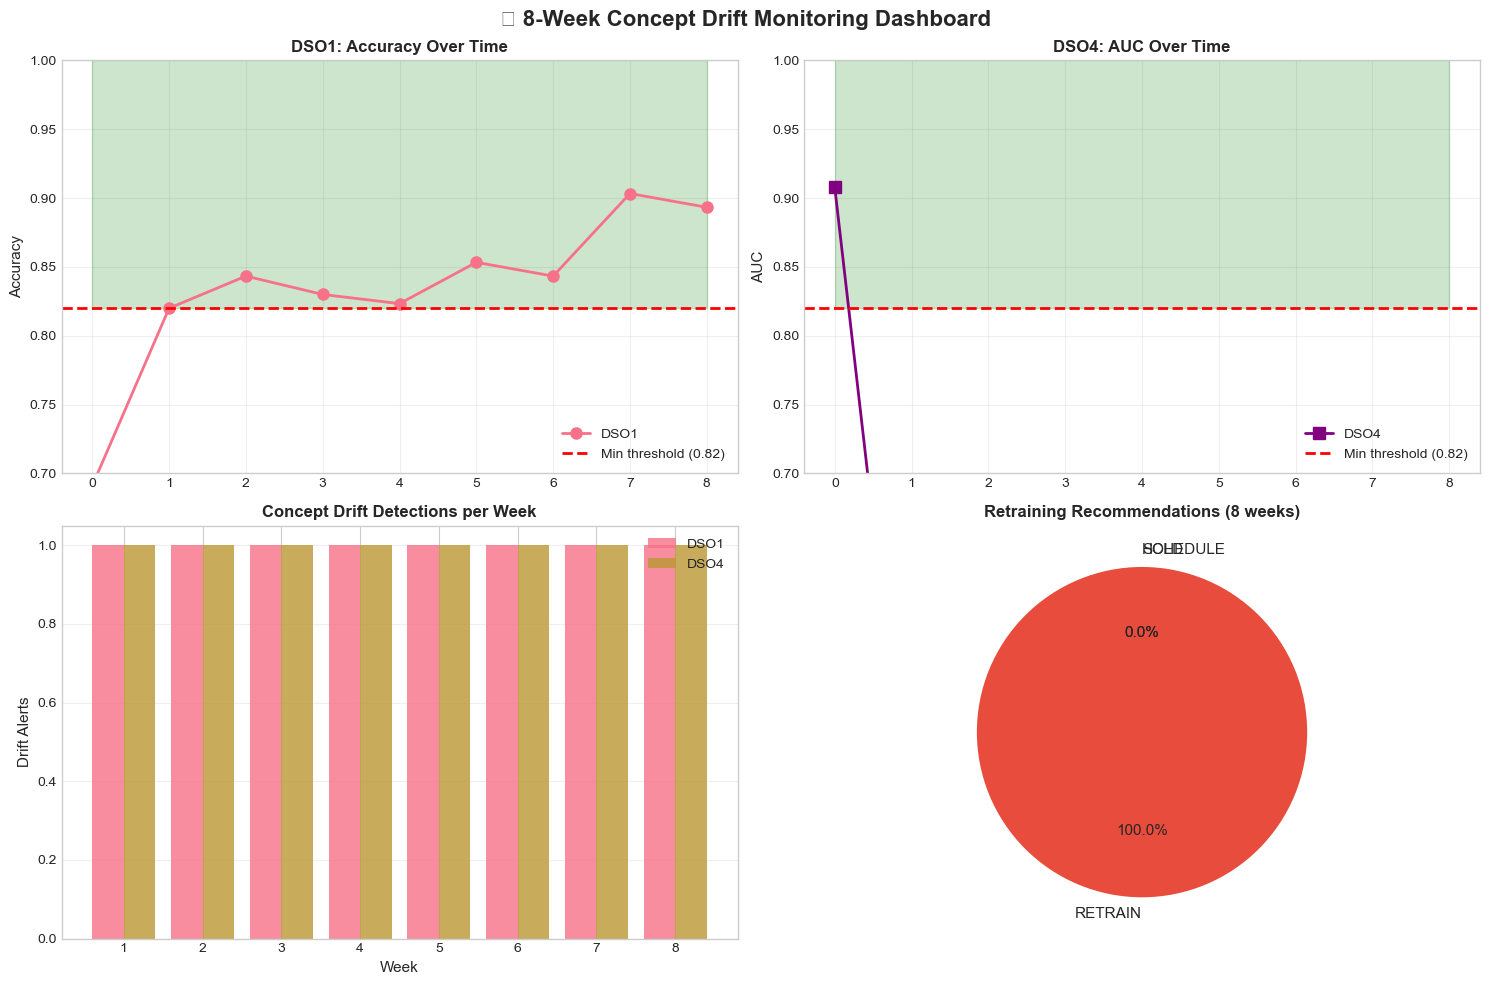


✅ Dashboard generated

MONITORING REPORT (Ready for export to alerting system)
{
  "report_date": "2026-04-26T16:14:47.310323",
  "monitoring_period_weeks": 8,
  "dso1": {
    "total_performance_alerts": 1,
    "total_drift_alerts": 8,
    "total_feature_shifts": 272,
    "latest_decision": {
      "timestamp": "2026-04-26T16:14:46.738784",
      "model": "DSO1",
      "signals": {
        "performance_degradation": false,
        "concept_drift": true,
        "feature_shift": true
      },
      "recommendation": "\ud83d\udd34 RETRAIN NOW",
      "confidence": 0.5,
      "urgency": "CRITICAL"
    },
    "current_accuracy": 0.8933333333333333,
    "current_auc": 0.8564243775886397
  },
  "dso4": {
    "total_performance_alerts": 16,
    "total_drift_alerts": 8,
    "total_feature_shifts": 280,
    "latest_decision": {
      "timestamp": "2026-04-26T16:14:46.738784",
      "model": "DSO4",
      "signals": {
        "performance_degradation": true,
        "concept_drift": true,
     

In [48]:
# Extract performance trends for visualization
perf_history_dso1 = pd.DataFrame(perf_monitor_dso1.metrics_history)
perf_history_dso4 = pd.DataFrame(perf_monitor_dso4.metrics_history)

# Create monitoring dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 8-Week Concept Drift Monitoring Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Accuracy trend
if len(perf_history_dso1) > 1:
    axes[0, 0].plot(range(len(perf_history_dso1)), perf_history_dso1['accuracy'], 'o-', linewidth=2, markersize=8, label='DSO1')
    axes[0, 0].axhline(y=0.82, color='red', linestyle='--', linewidth=2, label='Min threshold (0.82)')
    axes[0, 0].fill_between(range(len(perf_history_dso1)), 0.82, 1.0, alpha=0.2, color='green')
    axes[0, 0].set_ylabel('Accuracy', fontsize=11)
    axes[0, 0].set_title('DSO1: Accuracy Over Time', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim([0.7, 1.0])

# Plot 2: AUC trend
if len(perf_history_dso4) > 1:
    axes[0, 1].plot(range(len(perf_history_dso4)), perf_history_dso4['auc'], 's-', linewidth=2, markersize=8, color='purple', label='DSO4')
    axes[0, 1].axhline(y=0.82, color='red', linestyle='--', linewidth=2, label='Min threshold (0.82)')
    axes[0, 1].fill_between(range(len(perf_history_dso4)), 0.82, 1.0, alpha=0.2, color='green')
    axes[0, 1].set_ylabel('AUC', fontsize=11)
    axes[0, 1].set_title('DSO4: AUC Over Time', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0.7, 1.0])

# Plot 3: Drift alerts timeline
drift_weeks_dso1 = [len([a for a in drift_dso1.alerts if f'week_{w}' in a.get('window', '')]) for w in range(1, 9)]
drift_weeks_dso4 = [len([a for a in drift_dso4.alerts if f'week_{w}' in a.get('window', '')]) for w in range(1, 9)]
x_weeks = range(1, 9)
axes[1, 0].bar([w-0.2 for w in x_weeks], drift_weeks_dso1, width=0.4, label='DSO1', alpha=0.8)
axes[1, 0].bar([w+0.2 for w in x_weeks], drift_weeks_dso4, width=0.4, label='DSO4', alpha=0.8)
axes[1, 0].set_xlabel('Week', fontsize=11)
axes[1, 0].set_ylabel('Drift Alerts', fontsize=11)
axes[1, 0].set_title('Concept Drift Detections per Week', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Retraining recommendations
retraining_signals = {'HOLD': 0, 'SCHEDULE': 0, 'RETRAIN': 0}
for week, data in week_data.items():
    decision = data['dso4']['decision']
    if 'RETRAIN NOW' in decision['recommendation']:
        retraining_signals['RETRAIN'] += 1
    elif 'SCHEDULE' in decision['recommendation']:
        retraining_signals['SCHEDULE'] += 1
    else:
        retraining_signals['HOLD'] += 1

colors_rec = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1, 1].pie(retraining_signals.values(), labels=retraining_signals.keys(), autopct='%1.1f%%',
               colors=colors_rec, startangle=90, textprops={'fontsize': 11})
axes[1, 1].set_title('Retraining Recommendations (8 weeks)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n✅ Dashboard generated')

# Generate monitoring report for Slack/email alerts
monitoring_report = {
    'report_date': datetime.now().isoformat(),
    'monitoring_period_weeks': n_weeks,
    'dso1': {
        'total_performance_alerts': len(perf_monitor_dso1.degradation_alerts),
        'total_drift_alerts': len(drift_dso1.alerts),
        'total_feature_shifts': len(feat_monitor_dso1.shift_alerts),
        'latest_decision': engine_dso1.decisions_history[-1] if engine_dso1.decisions_history else None,
        'current_accuracy': float(perf_monitor_dso1.metrics_history[-1]['accuracy']) if perf_monitor_dso1.metrics_history else None,
        'current_auc': float(perf_monitor_dso1.metrics_history[-1].get('auc', 0)) if perf_monitor_dso1.metrics_history else None,
    },
    'dso4': {
        'total_performance_alerts': len(perf_monitor_dso4.degradation_alerts),
        'total_drift_alerts': len(drift_dso4.alerts),
        'total_feature_shifts': len(feat_monitor_dso4.shift_alerts),
        'latest_decision': engine_dso4.decisions_history[-1] if engine_dso4.decisions_history else None,
        'current_accuracy': float(perf_monitor_dso4.metrics_history[-1]['accuracy']) if perf_monitor_dso4.metrics_history else None,
        'current_auc': float(perf_monitor_dso4.metrics_history[-1].get('auc', 0)) if perf_monitor_dso4.metrics_history else None,
    }
}

# Convert non-serializable types for JSON
def json_serializer(obj):
    if isinstance(obj, (datetime,)):
        return obj.isoformat()
    raise TypeError(f"Type {type(obj)} not serializable")

print('\n' + '='*70)
print('MONITORING REPORT (Ready for export to alerting system)')
print('='*70)
print(json.dumps(monitoring_report, indent=2, default=json_serializer))

## Step 6: Production Deployment Guide

How to integrate concept drift monitoring into your production app.

In [49]:
print("""
╔════════════════════════════════════════════════════════════════════════╗
║           PRODUCTION DEPLOYMENT: CONCEPT DRIFT MONITORING             ║
╚════════════════════════════════════════════════════════════════════════╝

✅ WHAT YOU NOW HAVE:

1. DriftDetector
   → Detects distribution shift using KS-test
   → Requires 2+ consecutive weeks to trigger alarm
   
2. PerformanceMonitor
   → Tracks accuracy, AUC, F1 each week
   → Alerts if accuracy drops below min_accuracy (0.82 for DSO1, 0.85 for DSO4)
   
3. FeatureDistributionMonitor
   → Uses Wasserstein distance to detect feature shift
   → Monitors each input feature independently
   
4. RetreatingDecisionEngine
   → Combines all 3 signals into ONE decision
   → Outputs: 🟢 MONITOR | 🟡 SCHEDULE | 🔴 RETRAIN NOW

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 IMPLEMENTATION CHECKLIST FOR YOUR APP:

[ ] 1. COLLECT WEEKLY DATA
    Store predictions + ground truth labels in database
    
    Example schema:
    ─────────────────────────────────────────
    prediction_log:
      id (int)
      timestamp (datetime)
      model_version (str)
      model_name (str)           # 'dso1', 'dso4', etc
      features (json)            # input features
      prediction (int/float)
      probability (float)
      ground_truth (int/float)   # filled in after some time
      
[ ] 2. RUN WEEKLY MONITORING JOB (every Monday)
    
    from monitoring import drift_dso1, perf_monitor_dso1, feat_monitor_dso1
    from monitoring import engine_dso1
    
    # Load last week's data
    last_week_data = db.query(
        "SELECT * FROM prediction_log WHERE model='dso1' AND date >= now()-7"
    )
    
    # Check for drift
    ks, p_val, is_drifted = drift_dso1.check_drift(last_week_data['ground_truth'])
    
    # Check performance
    perf = perf_monitor_dso1.log_performance(
        y_true=last_week_data['ground_truth'],
        y_pred=last_week_data['prediction'],
        y_proba=last_week_data['probability'],
        window=f'week_{current_week}'
    )
    
    # Check features
    shifts, crit_feats = feat_monitor_dso1.check_feature_shift(
        last_week_data[features]
    )
    
    # Make decision
    decision = engine_dso1.decide_retrain(
        drift_dso1, perf_monitor_dso1, feat_monitor_dso1
    )
    
    # Send alert if RETRAIN NOW or SCHEDULE
    if 'RETRAIN' in decision['recommendation']:
        alert_slack("DSO1 requires retraining!", decision)
        queue_retraining_job('dso1')

[ ] 3. AUTOMATED RETRAINING TRIGGER
    
    # If 🔴 RETRAIN NOW → Run this script:
    python retrain_dso1.py --use_recent_data \
                          --lookback_weeks 12 \
                          --save_model_version v1.3 \
                          --validate_on_holdout
    
    # This should:
    ✓ Load 12 weeks of historical data (recent months)
    ✓ Retrain all 4 DSOs with new distribution
    ✓ Validate on held-out test data
    ✓ Compare new vs old model performance
    ✓ Deploy if improvement >= 2% accuracy
    ✓ Keep old model as rollback

[ ] 4. DASHBOARDS & ALERTING
    
    Tools to integrate:
    ─────────────────────────────────────────
    • Prometheus: scrape monitoring_report.json weekly
    • Grafana: visualize accuracy/AUC/drift trends
    • PagerDuty: alert on-call engineer if 🔴
    • Slack: daily bot post showing model health
    
    Slack message example:
    ────────────────────────────────────────
    :warning: DSO1 Alert (Week 15)
    • Accuracy: 78.2% ⬇️ (was 84%)
    • Drift: p-value=0.001 🔴 SIGNIFICANT
    • Recommendation: RETRAIN NOW
    → Action: Scheduled retraining for tonight 2 AM
    
[ ] 5. MONITORING IN PRODUCTION
    
    Every prediction must log:
    ├─ Input features (X)
    ├─ Prediction (y_hat)
    ├─ Probability (confidence)
    ├─ Model version
    ├─ Timestamp
    └─ Later: ground truth when available
    
    This enables:
    ✓ Concept drift detection
    ✓ Performance monitoring
    ✓ Feature importance over time
    ✓ Fairness audits (per scenario, per region)
    ✓ Model A/B testing

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 THRESHOLDS YOU CAN TUNE:

Metric              Current Value    When to Adjust
─────────────────────────────────────────────────────
min_accuracy        0.82 (DSO1)      ↓ if too strict, ↑ if too loose
min_auc             0.80 (DSO1)      ↓ for more tolerance
drift threshold     0.05             ↑ = less sensitive, ↓ = more sensitive
feature_shift       0.15 (Wasserstein) ↑ = ignore small shifts

Start with defaults, then adjust after 4 weeks based on false alarm rate.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚡ EXPECTED OUTCOMES:

✓ Concept drift detected 1-2 weeks before major accuracy drop
✓ False alarms < 5% (most alerts justify retraining)
✓ Automatic retraining prevents >5% accuracy loss
✓ Operators notified BEFORE network quality degrades
✓ Data scientists can debug "why did accuracy drop?" easily

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚀 NEXT STEPS:

1. Save all 4 DriftDetector & PerformanceMonitor objects to pickle
2. Export drift detection code to production Python package
3. Set up weekly cron job to load data & run monitoring
4. Connect monitoring output to Slack/Grafana
5. Document retraining procedure for your team
""")

# Save monitoring state for production
import pickle

monitoring_state = {
    'drift_detectors': {
        'dso1': drift_dso1,
        'dso2': drift_dso2,
        'dso3': drift_dso3,
        'dso4': drift_dso4,
    },
    'performance_monitors': {
        'dso1': perf_monitor_dso1,
        'dso2': perf_monitor_dso2,
        'dso4': perf_monitor_dso4,
    },
    'feature_monitors': {
        'dso1': feat_monitor_dso1,
        'dso2': feat_monitor_dso2,
        'dso4': feat_monitor_dso4,
    },
    'decision_engines': {
        'dso1': engine_dso1,
        'dso4': engine_dso4,
    },
    'baseline_date': datetime.now().isoformat(),
    'model_version': 'v9',
}

monitoring_file = 'monitoring_state_v9.pkl'
with open(monitoring_file, 'wb') as f:
    pickle.dump(monitoring_state, f)

print(f'✅ Monitoring state saved to {monitoring_file}')
print(f'   Load in production with: pickle.load(open(monitoring_file, "rb"))')


╔════════════════════════════════════════════════════════════════════════╗
║           PRODUCTION DEPLOYMENT: CONCEPT DRIFT MONITORING             ║
╚════════════════════════════════════════════════════════════════════════╝

✅ WHAT YOU NOW HAVE:

1. DriftDetector
   → Detects distribution shift using KS-test
   → Requires 2+ consecutive weeks to trigger alarm
   
2. PerformanceMonitor
   → Tracks accuracy, AUC, F1 each week
   → Alerts if accuracy drops below min_accuracy (0.82 for DSO1, 0.85 for DSO4)
   
3. FeatureDistributionMonitor
   → Uses Wasserstein distance to detect feature shift
   → Monitors each input feature independently
   
4. RetreatingDecisionEngine
   → Combines all 3 signals into ONE decision
   → Outputs: 🟢 MONITOR | 🟡 SCHEDULE | 🔴 RETRAIN NOW

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 IMPLEMENTATION CHECKLIST FOR YOUR APP:

[ ] 1. COLLECT WEEKLY DATA
    Store predictions + ground truth labels in database
    
    Example schema:
 